# Laboratorio 6 — Entrega final: actividades 1 a 10

**Universidad del Valle de Guatemala — CC3084 Data Science — Semestre II, 2026**

Versión canónica: conserva los hitos 1 y 2 y añade las actividades 5 a 10.

## tl;dr

- Notebook canónico de la entrega. Reproduce todo el análisis y exporta las tablas, figuras, grafos y métricas que alimentan el informe.
- La subred observada se fragmenta en 10 componentes; la mayor reúne el 81.5 % de los nodos.
- El 97.3 % de los autores tiene grado 1: casi nadie comenta en más de un video, de modo que la red agrupa audiencias, no conversaciones.
- Louvain ponderado detecta 17 comunidades (modularidad 0.7774) que coinciden casi exactamente con videos individuales.
- 7 autores son puntos de articulación: eliminarlos fragmenta el núcleo de la red pese a que aportan entre 2 y 4 comentarios cada uno.
- El 61.3 % de los comentarios es negativo, con diferencias significativas entre canales.

## 0. Preparación del entorno

In [1]:
from __future__ import annotations

import json
import re
import unicodedata
import warnings
from urllib.parse import unquote
from collections import Counter
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D
from scipy import stats

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 90)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.titleweight": "bold",
})

AZUL, NARANJA, VERDE, ROJO, MORADO, GRIS = (
    "#2b6cb0", "#dd6b20", "#2f855a", "#c53030", "#6b46c1", "#718096",
)
PALETA = [AZUL, NARANJA, VERDE, ROJO, MORADO, "#00838f", "#b7791f", "#4a5568"]


def encontrar_raiz(inicio: Path) -> Path:
    """Localiza la raíz del repositorio buscando los CSV originales."""
    for candidato in (inicio, *inicio.parents):
        if (candidato / "youtube_videos.csv").exists() and (candidato / "youtube_comments.csv").exists():
            return candidato
    raise FileNotFoundError("No se encontraron youtube_videos.csv y youtube_comments.csv.")


try:
    BASE = Path(__file__).resolve().parent
except NameError:  # ejecución interactiva / notebook
    BASE = Path.cwd()

ROOT = encontrar_raiz(BASE)
TABLAS = ROOT / "outputs" / "tables"
FIGURAS = ROOT / "outputs" / "figures"
GRAFOS = ROOT / "outputs" / "graphs"
PROCESADOS = ROOT / "data" / "processed"
for carpeta in (TABLAS, FIGURAS, GRAFOS, PROCESADOS):
    carpeta.mkdir(parents=True, exist_ok=True)

RESULTADOS: dict = {}


def registrar(clave: str, valor) -> None:
    """Guarda una métrica para reutilizarla en el informe escrito."""
    RESULTADOS[clave] = valor


def guardar_tabla(frame: pd.DataFrame, nombre: str) -> pd.DataFrame:
    frame.to_csv(TABLAS / f"{nombre}.csv", index=False, encoding="utf-8-sig")
    return frame


def guardar_figura(nombre: str) -> None:
    plt.savefig(FIGURAS / f"{nombre}.png")
    plt.show()          # muestra la figura en el notebook; en modo script no hace nada
    plt.close()


def acortar(valor, ancho: int = 46) -> str:
    valor = str(valor)
    return valor if len(valor) <= ancho else valor[: ancho - 1] + "…"


print(f"Raíz del proyecto: {ROOT}")

Raíz del proyecto: /Users/javiervalladares/Library/Mobile Documents/com~apple~CloudDocs/Octavo Semestre/Datos/Lab6/repo


## 1. Carga, comprensión e integración de los datos

### 1.1 Carga de `youtube_videos.csv` y `youtube_comments.csv`

Los archivos se leen con `encoding="utf-8-sig"` porque traen BOM. Todas las columnas que son
identificadores se fuerzan a texto: si pandas las infiriera como numéricas podría perder ceros a
la izquierda o convertir un ID a notación científica.

In [2]:
COLS_ID_VIDEOS = ["video_id", "channel_id", "channel_handle", "owner_handle"]
COLS_ID_COMENTARIOS = ["video_id", "comment_id", "channel_id", "author_channel_id", "author_handle"]

videos_raw = pd.read_csv(
    ROOT / "youtube_videos.csv",
    encoding="utf-8-sig",
    dtype={c: "string" for c in COLS_ID_VIDEOS},
    keep_default_na=True,
)
comentarios_raw = pd.read_csv(
    ROOT / "youtube_comments.csv",
    encoding="utf-8-sig",
    dtype={c: "string" for c in COLS_ID_COMENTARIOS},
    keep_default_na=True,
)

registrar("n_videos", int(len(videos_raw)))
registrar("n_comentarios", int(len(comentarios_raw)))
registrar("n_vars_videos", int(videos_raw.shape[1]))
registrar("n_vars_comentarios", int(comentarios_raw.shape[1]))

print(f"youtube_videos.csv    : {videos_raw.shape[0]} filas × {videos_raw.shape[1]} variables")
print(f"youtube_comments.csv  : {comentarios_raw.shape[0]} filas × {comentarios_raw.shape[1]} variables")
videos_raw.head(3)

youtube_videos.csv    : 293 filas × 20 variables
youtube_comments.csv  : 406 filas × 17 variables


,video_id,title,channel_name,channel_id,source_query,source_group,dataset_sources,channel_handle,published_time,view_count_text,description_snippet,video_url,query_hits,keywords,description,view_count,publish_date,upload_date,category,owner_handle
0,-5puKGEqcUc,INSIVUMEH pronostica incremento de lluvias para el fin de semana en Guatemala,T13 Noticias Guatemala,UCq0Cm-3SKthEySQc2JZBi1A,guatemala lluvias,topic,youtube_guatemala.csv | youtube_guatemala_lab.csv | youtube_guatemala_plus.csv,/@T13NoticiasGuatemala,hace 2 días,"2,390 vistas",El Departamento de Pronóstico de INSIVUMEH prevé un incremento en las lluvias durante ...,https://www.youtube.com/watch?v=-5puKGEqcUc,"[""guatemala lluvias""]","[""Canícula prolongada"", ""Chapin tv"", ""Fenómeno del Niño"", ""Guatemala"", ""Lluvias en Gua...",El Departamento de Pronóstico de INSIVUMEH prevé un incremento en las lluvias durante ...,2357,2026-08-28T22:00:20-07:00,2026-08-28T22:00:20-07:00,News & Politics,/@T13NoticiasGuatemala
1,-E7OPOLjMug,BERNARDO ARÉVALO CALIFICA CAMBIO EN EL MP COMO EL FIN DE UNA ETAPA DE DETERIORO INSTIT...,IDocumenta,UCgItjn_ZWFWcv1MlpKIkqgQ,@GobiernodelaRepublicadeGuatema,topic,youtube_target_channels.csv,/@iDocumenta,hace 3 meses,4 vistas,"El presidente de Guatemala, Bernardo Arévalo, calificó el cambio de fiscal general y j...",https://www.youtube.com/watch?v=-E7OPOLjMug,"[""@GobiernodelaRepublicadeGuatema""]",[],"El presidente de Guatemala, Bernardo Arévalo, calificó el cambio de fiscal general y j...",4,2026-05-13T16:00:03-07:00,2026-05-13T16:00:03-07:00,People & Blogs,/@iDocumenta
2,-KDglrIzRKo,¡HISTÓRICO! Mexico recupera petróleo robado por Guatemala... 🔔,México Poder,UC-DpoeBbCMOMOH1-j71KPqA,guatemala noticias,topic,youtube_guatemala.csv | youtube_guatemala_lab.csv | youtube_guatemala_plus.csv,/@M%C3%A9xicoPoder,hace 1 día,"29,736 vistas",México #PetróleoMexicano #SoberaníaEnergética #Pemex #NoticiasMéxico #FronteraSur #Hua...,https://www.youtube.com/watch?v=-KDglrIzRKo,"[""guatemala noticias""]","[""Mexico recupera petroleo"", ""petroleo robado Guatemala"", ""huachicol frontera sur"", ""P...",#México #PetróleoMexicano #SoberaníaEnergética #Pemex #NoticiasMéxico #FronteraSur #Hu...,29736,2026-08-29T17:00:38-07:00,2026-08-29T17:00:38-07:00,People & Blogs,/@M%C3%A9xicoPoder


In [3]:
comentarios_raw.head(3)

,video_id,comment_id,video_title,channel_name,channel_id,author_name,author_channel_id,text,source_query,source_group,dataset_sources,author_handle,published_text,like_count_text,reply_count,is_pinned,viewer_rating
0,j43HgwYFKfk,Ugw-J65a1iYL9hqhELh4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@MarcosCarillo-b1r,UCdFlugHJJa4l3YqWuNRmvXw,Ese corrupto amigo de la vieja fiscal los tengo que verbose en la carcel,@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete_comments.csv | youtube_guatemala_plus_c...,/@MarcosCarillo-b1r,hace 6 meses,,0,False,NaN
1,06mFNPU0aB8,Ugw-ZT9t9wU2V-tCaUZ4AaABAg,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,Noti7,UCVpSRoZgngfSL03Nlbjtq9A,@RaulPerez-cw2vi,UCvl1tzQeBeGy6efPTRJXSCw,"Están jóvenes porque no buscan un trabajo, tuvieron suerte que no hay policías que le...",guatemala noticias,topic,youtube_guatemala_comments.csv | youtube_guatemala_plus_comments.csv,/@RaulPerez-cw2vi,hace 2 semanas,,0,False,NaN
2,j43HgwYFKfk,Ugw0xaOb2CYXXoudtwJ4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@iamjimalesssa,UCRAquv8el-tQ30bN7MlmySQ,"Me dejaron con ganas de demandar la ilegalidad de las reuniones virtuales, esto no es ...",@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete_comments.csv | youtube_guatemala_plus_c...,/@iamjimalesssa,hace 1 año,4,0,False,NaN


### 1.2 Unidad de observación, llave primaria y variables relevantes

Se verifica empíricamente que las llaves candidatas son únicas y completas antes de afirmarlo.

In [4]:
def perfil_llave(frame: pd.DataFrame, columna: str) -> dict:
    serie = frame[columna]
    return {
        "archivo": None,
        "llave_candidata": columna,
        "filas": int(len(frame)),
        "valores_unicos": int(serie.nunique(dropna=True)),
        "faltantes": int(serie.isna().sum()),
        "es_llave_primaria": bool(serie.notna().all() and serie.nunique(dropna=True) == len(frame)),
    }


llaves = []
for nombre, frame, columnas in [
    ("youtube_videos.csv", videos_raw, ["video_id", "channel_id", "video_url"]),
    ("youtube_comments.csv", comentarios_raw, ["comment_id", "video_id", "author_channel_id"]),
]:
    for columna in columnas:
        fila = perfil_llave(frame, columna)
        fila["archivo"] = nombre
        llaves.append(fila)

llaves_df = guardar_tabla(pd.DataFrame(llaves), "01_llaves_candidatas")
registrar("llaves_candidatas", llaves_df.to_dict("records"))
llaves_df

,archivo,llave_candidata,filas,valores_unicos,faltantes,es_llave_primaria
0,youtube_videos.csv,video_id,293,293,0,True
1,youtube_videos.csv,channel_id,293,97,0,False
2,youtube_videos.csv,video_url,293,293,0,True
3,youtube_comments.csv,comment_id,406,406,0,True
4,youtube_comments.csv,video_id,406,19,0,False
5,youtube_comments.csv,author_channel_id,406,332,0,False


**Unidad de observación.**

| Archivo | Unidad de observación | Llave primaria | Llave foránea |
|---|---|---|---|
| `youtube_videos.csv` | Un video de YouTube recolectado en el muestreo | `video_id` (293 valores únicos, sin faltantes) | `channel_id` apunta al canal propietario |
| `youtube_comments.csv` | Un comentario **principal** (no respuesta) publicado en un video | `comment_id` (406 valores únicos, sin faltantes) | `video_id` → videos; `author_channel_id` → autor |

**Variables relevantes por bloque de análisis:**

| Bloque | Variables de `videos` | Variables de `comments` |
|---|---|---|
| Identificación / red | `video_id`, `channel_id` | `comment_id`, `video_id`, `author_channel_id` |
| Etiquetas visibles | `title`, `channel_name`, `channel_handle` | `author_name`, `author_handle`, `video_title` |
| Cuantitativas | `view_count` | `like_count_text` → numérico, `reply_count` |
| Contenido / temas | `title`, `description`, `keywords` | `text` |
| Contexto de muestreo | `source_query`, `source_group`, `query_hits`, `dataset_sources`, `category` | `source_query`, `source_group`, `dataset_sources` |
| Temporal | `publish_date`, `upload_date`, `published_time` | `published_text` (relativo) |

### 1.3 Relación entre canal, video, autor, comentario, categoría y consulta

El esquema relacional observable es el siguiente:

```
 source_query / source_group  ──(procedimiento de muestreo)──►  video
           canal (channel_id) ──1:N──► video (video_id) ──1:N──► comentario (comment_id)
                                           │                          │
                                    category (1:1)          autor (author_channel_id)
```

- Un **canal** publica uno o más videos: `channel_id` → `video_id` es 1:N.
- Un **video** pertenece a exactamente una **categoría** de YouTube y recibe 0..N comentarios.
- Un **comentario** tiene exactamente un **autor** (`author_channel_id`); un autor puede escribir
  varios comentarios, en uno o varios videos, de uno o varios canales.
- La **consulta de búsqueda** (`source_query`, `source_group`) no es un atributo del contenido sino
  del *procedimiento de recolección*: describe cómo se encontró el video, no de qué trata.
- `channel_id` en el archivo de comentarios es el canal **dueño del video**, no el del autor: son
  espacios de identificadores distintos y no deben cruzarse.

La relación autor↔autor **no es observable**: sólo se infiere co-participación en un mismo video.

In [5]:
relaciones = pd.DataFrame([
    ["canal", "video", "1:N", "channel_id → video_id", f"{videos_raw['channel_id'].nunique()} canales publican {len(videos_raw)} videos"],
    ["video", "comentario", "1:N", "video_id → comment_id", f"{comentarios_raw['video_id'].nunique()} videos concentran {len(comentarios_raw)} comentarios"],
    ["autor", "comentario", "1:N", "author_channel_id → comment_id", f"{comentarios_raw['author_channel_id'].nunique()} autores escriben {len(comentarios_raw)} comentarios"],
    ["video", "categoría", "N:1", "video_id → category", f"{videos_raw['category'].nunique()} categorías distintas"],
    ["consulta", "video", "N:M", "source_query / query_hits", f"{videos_raw['source_query'].nunique()} consultas; un video puede aparecer en varias"],
    ["autor", "autor", "no observable", "—", "reply_count no identifica a quién respondió cada usuario"],
], columns=["origen", "destino", "cardinalidad", "llave", "evidencia"])
guardar_tabla(relaciones, "02_relaciones_entre_entidades")
relaciones

,origen,destino,cardinalidad,llave,evidencia
0,canal,video,1:N,channel_id → video_id,97 canales publican 293 videos
1,video,comentario,1:N,video_id → comment_id,19 videos concentran 406 comentarios
2,autor,comentario,1:N,author_channel_id → comment_id,332 autores escriben 406 comentarios
3,video,categoría,N:1,video_id → category,11 categorías distintas
4,consulta,video,N:M,source_query / query_hits,21 consultas; un video puede aparecer en varias
5,autor,autor,no observable,—,reply_count no identifica a quién respondió cada usuario


### 1.4 Integración por `video_id` y cobertura de la unión

In [6]:
comentarios_con_video = comentarios_raw["video_id"].isin(set(videos_raw["video_id"]))
integrado_raw = comentarios_raw.merge(
    videos_raw[["video_id", "title", "channel_id", "channel_name", "category",
                "source_group", "source_query", "view_count"]],
    on="video_id", how="left", suffixes=("", "_video"), validate="many_to_one",
)

videos_con_comentarios = int(comentarios_raw["video_id"].nunique())
videos_sin_comentarios = int(len(videos_raw) - videos_con_comentarios)

integracion = pd.DataFrame([
    ["Comentarios en el archivo", len(comentarios_raw)],
    ["Comentarios que sí se asociaron a un video", int(comentarios_con_video.sum())],
    ["Comentarios huérfanos (video_id sin catálogo)", int((~comentarios_con_video).sum())],
    ["Filas resultantes de la unión", len(integrado_raw)],
    ["Videos del catálogo", len(videos_raw)],
    ["Videos con al menos un comentario", videos_con_comentarios],
    ["Videos sin comentarios recolectados", videos_sin_comentarios],
    ["Cobertura de videos (%)", round(100 * videos_con_comentarios / len(videos_raw), 2)],
], columns=["indicador", "valor"])
guardar_tabla(integracion, "03_integracion_y_cobertura")

registrar("videos_con_comentarios", videos_con_comentarios)
registrar("videos_sin_comentarios", videos_sin_comentarios)
registrar("cobertura_videos_pct", round(100 * videos_con_comentarios / len(videos_raw), 2))
registrar("comentarios_asociados", int(comentarios_con_video.sum()))
registrar("comentarios_huerfanos", int((~comentarios_con_video).sum()))
registrar("canales_videos", int(videos_raw["channel_id"].nunique()))
registrar("canales_con_comentarios", int(comentarios_raw["channel_id"].nunique()))
registrar("autores_unicos", int(comentarios_raw["author_channel_id"].nunique()))
integracion

,indicador,valor
0,Comentarios en el archivo,406.00
1,Comentarios que sí se asociaron a un video,406.00
2,Comentarios huérfanos (video_id sin catálogo),0.00
3,Filas resultantes de la unión,406.00
4,Videos del catálogo,293.00
5,Videos con al menos un comentario,19.00
6,Videos sin comentarios recolectados,274.00
7,Cobertura de videos (%),6.48


## 2. Calidad, limpieza y preprocesamiento

### 2.1 Diagnóstico inicial de calidad

El diagnóstico cubre las seis dimensiones pedidas: dimensiones del archivo, tipo de cada variable,
valores faltantes, duplicados, variables constantes y valores atípicos, más un bloque específico de
consistencia entre identificadores, nombres y *handles*.

In [7]:
def contar_atipicos_iqr(serie: pd.Series):
    """Atípicos por la regla 1.5·IQR. Devuelve NA si la variable no es numérica."""
    if not pd.api.types.is_numeric_dtype(serie.dtype) or pd.api.types.is_bool_dtype(serie.dtype):
        return pd.NA
    valores = pd.to_numeric(serie, errors="coerce").dropna()
    if valores.empty:
        return 0
    q1, q3 = valores.quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0:
        return 0
    return int(((valores < q1 - 1.5 * iqr) | (valores > q3 + 1.5 * iqr)).sum())


def diagnostico_calidad(frame: pd.DataFrame, archivo: str) -> pd.DataFrame:
    filas = []
    for columna in frame.columns:
        serie = frame[columna]
        no_nulos = serie.dropna()
        vacios_texto = 0
        if serie.dtype == object or str(serie.dtype) in {"string", "str"}:
            vacios_texto = int(serie.astype("string").fillna("").str.strip().eq("").sum())
        filas.append({
            "archivo": archivo,
            "variable": columna,
            "tipo_pandas": str(serie.dtype),
            "faltantes": int(serie.isna().sum()),
            "faltantes_pct": round(100 * serie.isna().mean(), 2),
            "vacios_o_espacios": vacios_texto,
            "valores_unicos": int(serie.nunique(dropna=True)),
            "es_constante": bool(len(no_nulos) > 0 and serie.nunique(dropna=True) <= 1),
            "es_vacia": bool(serie.isna().all()),
            "atipicos_iqr": contar_atipicos_iqr(serie),
            "ejemplo": acortar(no_nulos.iloc[0], 40) if len(no_nulos) else "",
        })
    return pd.DataFrame(filas)


calidad = pd.concat([
    diagnostico_calidad(videos_raw, "youtube_videos.csv"),
    diagnostico_calidad(comentarios_raw, "youtube_comments.csv"),
], ignore_index=True)
guardar_tabla(calidad, "04_diagnostico_calidad")
registrar("diagnostico_calidad", calidad.to_dict("records"))
calidad

,archivo,variable,tipo_pandas,faltantes,faltantes_pct,vacios_o_espacios,valores_unicos,es_constante,es_vacia,atipicos_iqr,ejemplo
0,youtube_videos.csv,video_id,string,0,0.00,0,293,False,False,<NA>,-5puKGEqcUc
1,youtube_videos.csv,title,str,0,0.00,0,274,False,False,<NA>,INSIVUMEH pronostica incremento de lluv…
2,youtube_videos.csv,channel_name,str,0,0.00,0,97,False,False,<NA>,T13 Noticias Guatemala
3,youtube_videos.csv,channel_id,string,0,0.00,0,97,False,False,<NA>,UCq0Cm-3SKthEySQc2JZBi1A
4,youtube_videos.csv,source_query,str,0,0.00,0,21,False,False,<NA>,guatemala lluvias
5,youtube_videos.csv,source_group,str,0,0.00,0,3,False,False,<NA>,topic
6,youtube_videos.csv,dataset_sources,str,0,0.00,0,23,False,False,<NA>,youtube_guatemala.csv | youtube_guatema…
7,youtube_videos.csv,channel_handle,string,0,0.00,0,97,False,False,<NA>,/@T13NoticiasGuatemala
8,youtube_videos.csv,published_time,str,13,4.44,13,80,False,False,<NA>,hace 2 días
9,youtube_videos.csv,view_count_text,str,13,4.44,13,259,False,False,<NA>,"2,390 vistas"


In [8]:
# Duplicados: exactos (fila completa) y por llave primaria.
duplicados = pd.DataFrame([
    ["youtube_videos.csv", "Filas exactamente duplicadas", int(videos_raw.duplicated().sum())],
    ["youtube_videos.csv", "video_id duplicado", int(videos_raw["video_id"].duplicated().sum())],
    ["youtube_videos.csv", "title duplicado (distinto video)", int(videos_raw["title"].duplicated().sum())],
    ["youtube_comments.csv", "Filas exactamente duplicadas", int(comentarios_raw.duplicated().sum())],
    ["youtube_comments.csv", "comment_id duplicado", int(comentarios_raw["comment_id"].duplicated().sum())],
    ["youtube_comments.csv", "texto duplicado (comment_id distinto)", int(comentarios_raw["text"].duplicated().sum())],
    ["youtube_comments.csv", "(video_id, author_channel_id, text) duplicado",
     int(comentarios_raw.duplicated(subset=["video_id", "author_channel_id", "text"]).sum())],
], columns=["archivo", "chequeo", "conteo"])
guardar_tabla(duplicados, "05_duplicados")
registrar("duplicados", duplicados.to_dict("records"))

constantes = calidad.query("es_constante or es_vacia")[["archivo", "variable", "valores_unicos", "faltantes", "es_constante", "es_vacia"]]
registrar("variables_constantes", constantes.to_dict("records"))
print(duplicados.to_string(index=False))
print("\nVariables constantes o completamente vacías:")
print(constantes.to_string(index=False))

             archivo                                       chequeo  conteo
  youtube_videos.csv                  Filas exactamente duplicadas       0
  youtube_videos.csv                            video_id duplicado       0
  youtube_videos.csv              title duplicado (distinto video)      19
youtube_comments.csv                  Filas exactamente duplicadas       0
youtube_comments.csv                          comment_id duplicado       0
youtube_comments.csv         texto duplicado (comment_id distinto)       2
youtube_comments.csv (video_id, author_channel_id, text) duplicado       2

Variables constantes o completamente vacías:
             archivo      variable  valores_unicos  faltantes  es_constante  es_vacia
youtube_comments.csv     is_pinned               1          0          True     False
youtube_comments.csv viewer_rating               0        406         False      True


In [9]:
# Consistencia entre identificadores, nombres visibles y handles.
def ids_con_varias_etiquetas(frame, col_id, col_etiqueta) -> int:
    conteo = frame.dropna(subset=[col_id]).groupby(col_id)[col_etiqueta].nunique(dropna=True)
    return int((conteo > 1).sum())


def etiquetas_con_varios_ids(frame, col_id, col_etiqueta) -> int:
    conteo = frame.dropna(subset=[col_etiqueta]).groupby(col_etiqueta)[col_id].nunique(dropna=True)
    return int((conteo > 1).sum())


consistencia = pd.DataFrame([
    ["videos", "channel_id → un solo channel_name", ids_con_varias_etiquetas(videos_raw, "channel_id", "channel_name")],
    ["videos", "channel_name → un solo channel_id", etiquetas_con_varios_ids(videos_raw, "channel_id", "channel_name")],
    ["videos", "channel_id → un solo channel_handle", ids_con_varias_etiquetas(videos_raw, "channel_id", "channel_handle")],
    ["videos", "channel_handle ≠ owner_handle", int((videos_raw["channel_handle"] != videos_raw["owner_handle"]).sum())],
    ["videos", "publish_date ≠ upload_date", int((videos_raw["publish_date"] != videos_raw["upload_date"]).sum())],
    ["videos", "video_url inconsistente con video_id",
     int((~videos_raw.apply(lambda r: str(r["video_id"]) in str(r["video_url"]), axis=1)).sum())],
    ["comentarios", "author_channel_id → un solo author_name", ids_con_varias_etiquetas(comentarios_raw, "author_channel_id", "author_name")],
    ["comentarios", "author_name → un solo author_channel_id", etiquetas_con_varios_ids(comentarios_raw, "author_channel_id", "author_name")],
    ["comentarios", "author_channel_id → un solo author_handle", ids_con_varias_etiquetas(comentarios_raw, "author_channel_id", "author_handle")],
    ["cruce", "channel_id de comentarios presente en videos",
     int(comentarios_raw["channel_id"].isin(set(videos_raw["channel_id"])).sum())],
    ["cruce", "author_channel_id que también es channel_id de un video",
     int(comentarios_raw["author_channel_id"].isin(set(videos_raw["channel_id"])).sum())],
    ["cruce", "video_title de comentarios ≠ title del catálogo",
     int((integrado_raw["video_title"] != integrado_raw["title"]).sum())],
    ["cruce", "source_group del comentario ≠ source_group del video",
     int((integrado_raw["source_group"] != integrado_raw["source_group_video"]).sum())],
    ["cruce", "source_query del comentario ≠ source_query del video",
     int((integrado_raw["source_query"] != integrado_raw["source_query_video"]).sum())],
], columns=["ámbito", "regla", "incumplimientos_o_conteo"])
guardar_tabla(consistencia, "06_consistencia_identificadores")
registrar("consistencia", consistencia.to_dict("records"))
consistencia

,ámbito,regla,incumplimientos_o_conteo
0,videos,channel_id → un solo channel_name,0
1,videos,channel_name → un solo channel_id,0
2,videos,channel_id → un solo channel_handle,0
3,videos,channel_handle ≠ owner_handle,0
4,videos,publish_date ≠ upload_date,0
5,videos,video_url inconsistente con video_id,0
6,comentarios,author_channel_id → un solo author_name,0
7,comentarios,author_name → un solo author_channel_id,0
8,comentarios,author_channel_id → un solo author_handle,0
9,cruce,channel_id de comentarios presente en videos,406


### 2.2 Variables que no pueden utilizarse o que requieren precaución

El diagnóstico anterior permite clasificar cada variable problemática y justificar su tratamiento.

In [10]:
likes_en_blanco = int(comentarios_raw["like_count_text"].fillna("").astype(str).str.strip().eq("").sum())
registrar("likes_en_blanco", likes_en_blanco)

problematicas = pd.DataFrame([
    ["viewer_rating", "Inutilizable", "406/406 faltantes (100 %); varianza nula.",
     "Se excluye de todo análisis. Se conserva en el archivo crudo para auditoría."],
    ["is_pinned", "Sin aporte", "Constante en False para los 406 registros.",
     "No se usa como variable explicativa; se documenta la ausencia de comentarios fijados."],
    ["published_time / published_text", "Precaución alta", "Tiempo relativo ('hace 2 días') dependiente del momento de recolección.",
     "No se convierte a fecha absoluta. Sólo se usa de forma ordinal y descriptiva."],
    ["view_count_text", "Redundante", "Texto con separador de miles y la palabra 'vistas'; 13 faltantes.",
     "Se usa view_count (entero) para todo cálculo; el texto queda como respaldo."],
    ["like_count_text", "Precaución", f"Almacenado como texto; {likes_en_blanco} registros son espacio en blanco.",
     "Se convierte a entero; el blanco se interpreta como 0 likes mostrados y se marca en like_count_imputado."],
    ["reply_count", "Precaución crítica", "Cuenta respuestas pero no identifica a sus autores.",
     "Nunca genera aristas entre usuarios. Se usa sólo como atributo de intensidad del comentario."],
    ["channel_name / author_name / handles", "No son identificadores", "Pueden repetirse o cambiar en el tiempo.",
     "Se conservan sólo como etiquetas; los IDs son la llave en toda la red."],
    ["source_query / source_group", "Sesgo de muestreo y homonimia", "Describen cómo se encontró el contenido, no su tema real. "
     "Además la variable existe en ambos archivos con el mismo nombre pero distinto significado y no coincide en 188 de 406 comentarios.",
     "Se usan sólo para describir el procedimiento. Al unir los archivos se conserva el sufijo _video "
     "para no confundir la ruta de recolección del video con la de sus comentarios."],
    ["description_snippet", "Redundante e incompleta", "Fragmento truncado de description; 25 faltantes.",
     "Se prefiere description para el análisis de contenido."],
    ["upload_date", "Redundante", "Idéntica a publish_date en el 100 % de los registros.",
     "Se conserva una sola variable temporal (publish_date)."],
    ["dataset_sources", "Procedencia", "Lista de archivos originales separados por '|'.",
     "Se usa para auditar la integración, no como variable de análisis."],
], columns=["variable", "clasificación", "problema_observado", "tratamiento_justificado"])
guardar_tabla(problematicas, "07_variables_problematicas")
registrar("variables_problematicas", problematicas.to_dict("records"))
problematicas

,variable,clasificación,problema_observado,tratamiento_justificado
0,viewer_rating,Inutilizable,406/406 faltantes (100 %); varianza nula.,Se excluye de todo análisis. Se conserva en el archivo crudo para auditoría.
1,is_pinned,Sin aporte,Constante en False para los 406 registros.,No se usa como variable explicativa; se documenta la ausencia de comentarios fijados.
2,published_time / published_text,Precaución alta,Tiempo relativo ('hace 2 días') dependiente del momento de recolección.,No se convierte a fecha absoluta. Sólo se usa de forma ordinal y descriptiva.
3,view_count_text,Redundante,Texto con separador de miles y la palabra 'vistas'; 13 faltantes.,Se usa view_count (entero) para todo cálculo; el texto queda como respaldo.
4,like_count_text,Precaución,Almacenado como texto; 189 registros son espacio en blanco.,Se convierte a entero; el blanco se interpreta como 0 likes mostrados y se marca en li...
5,reply_count,Precaución crítica,Cuenta respuestas pero no identifica a sus autores.,Nunca genera aristas entre usuarios. Se usa sólo como atributo de intensidad del comen...
6,channel_name / author_name / handles,No son identificadores,Pueden repetirse o cambiar en el tiempo.,Se conservan sólo como etiquetas; los IDs son la llave en toda la red.
7,source_query / source_group,Sesgo de muestreo y homonimia,"Describen cómo se encontró el contenido, no su tema real. Además la variable existe en...",Se usan sólo para describir el procedimiento. Al unir los archivos se conserva el sufi...
8,description_snippet,Redundante e incompleta,Fragmento truncado de description; 25 faltantes.,Se prefiere description para el análisis de contenido.
9,upload_date,Redundante,Idéntica a publish_date en el 100 % de los registros.,Se conserva una sola variable temporal (publish_date).


### 2.3 Normalización de identificadores y nombres

La normalización es **deliberadamente conservadora sobre los IDs**: sólo se recortan espacios
externos. No se cambian mayúsculas ni se sustituye ningún ID por un nombre visible, porque los IDs
de YouTube distinguen mayúsculas y minúsculas. Los nombres y *handles* sí se normalizan (Unicode
NFKC y espacios) porque son etiquetas de presentación.

In [11]:
def normalizar_id(serie: pd.Series) -> pd.Series:
    """Sólo recorta espacios externos: nunca altera el contenido del identificador."""
    return serie.astype("string").str.strip()


def normalizar_etiqueta(serie: pd.Series) -> pd.Series:
    """Normaliza Unicode y colapsa espacios en nombres visibles; preserva mayúsculas y acentos."""
    normalizada = serie.astype("string").map(
        lambda v: unicodedata.normalize("NFKC", v) if isinstance(v, str) else v
    )
    return normalizada.str.replace(r"\s+", " ", regex=True).str.strip()


RE_PORCENTAJE = re.compile(r"%[0-9A-Fa-f]{2}")


def normalizar_handle(serie: pd.Series) -> pd.Series:
    """Handles en forma canónica @nombre.

    Además del prefijo '/', se decodifica el porcentaje-encoding de URL: 14 handles de autor y 13 de
    canal llegan como '/@AlejandroP%C3%A9rez-b6r' en lugar de '@AlejandroPérez-b6r'. Sin decodificar,
    la misma persona podría mostrarse con dos etiquetas distintas en las tablas y figuras.
    """
    decodificado = serie.astype("string").map(
        lambda v: unquote(v) if isinstance(v, str) and RE_PORCENTAJE.search(v) else v)
    limpio = normalizar_etiqueta(decodificado).str.lstrip("/")
    return limpio.where(limpio.isna() | limpio.str.startswith("@"), "@" + limpio.fillna(""))


videos = videos_raw.copy()
comentarios = comentarios_raw.copy()

for columna in ["video_id", "channel_id"]:
    videos[columna] = normalizar_id(videos[columna])
for columna in ["video_id", "comment_id", "channel_id", "author_channel_id"]:
    comentarios[columna] = normalizar_id(comentarios[columna])

for columna in ["title", "channel_name", "category", "source_query", "source_group"]:
    videos[columna] = normalizar_etiqueta(videos[columna])
for columna in ["video_title", "channel_name", "author_name", "source_query", "source_group"]:
    comentarios[columna] = normalizar_etiqueta(comentarios[columna])

videos["channel_handle"] = normalizar_handle(videos["channel_handle"])
videos["owner_handle"] = normalizar_handle(videos["owner_handle"])
comentarios["author_handle"] = normalizar_handle(comentarios["author_handle"])

# Verificación: la normalización no debe fusionar ni romper identificadores.
handles_codificados = int(
    comentarios_raw["author_handle"].astype(str).str.contains(RE_PORCENTAJE, regex=True).sum()
    + videos_raw["channel_handle"].astype(str).str.contains(RE_PORCENTAJE, regex=True).sum())
registrar("handles_codificados", handles_codificados)

verificacion_ids = pd.DataFrame([
    ["video_id únicos antes/después", videos_raw["video_id"].nunique(), videos["video_id"].nunique()],
    ["channel_id únicos antes/después", videos_raw["channel_id"].nunique(), videos["channel_id"].nunique()],
    ["comment_id únicos antes/después", comentarios_raw["comment_id"].nunique(), comentarios["comment_id"].nunique()],
    ["author_channel_id únicos antes/después", comentarios_raw["author_channel_id"].nunique(), comentarios["author_channel_id"].nunique()],
    ["Handles con porcentaje-encoding de URL", handles_codificados, 0],
], columns=["chequeo", "antes", "después"])
guardar_tabla(verificacion_ids, "08_verificacion_normalizacion_ids")
registrar("verificacion_ids", verificacion_ids.to_dict("records"))
verificacion_ids

,chequeo,antes,después
0,video_id únicos antes/después,293,293
1,channel_id únicos antes/después,97,97
2,comment_id únicos antes/después,406,406
3,author_channel_id únicos antes/después,332,332
4,Handles con porcentaje-encoding de URL,27,0


### 2.4 Conversión a numérico de las variables de conteo almacenadas como texto

Decisiones documentadas:

- **Separadores de miles**: se eliminan `,` (formato en inglés) y `.` cuando actúa como separador
  de millares; también se eliminan espacios finos y no separables.
- **Abreviaturas**: se soportan los sufijos `K`, `M`, `B`, `MIL`, `MILL` y `M.` que YouTube muestra
  en algunas interfaces (por ejemplo `1.2 K` → 1 200).
- **Palabras de contexto**: `vistas`, `views`, `visualizaciones`, `reproducciones` se descartan.
- **Valores no válidos**: cadenas vacías, espacios y texto sin dígitos → `NA`, no 0.
- **Regla de negocio**: en `like_count_text` el blanco **sí** significa cero, porque YouTube oculta
  el contador cuando vale 0. Esa imputación queda registrada en `like_count_imputado`.

In [12]:
SUFIJOS = {"K": 1_000, "MIL": 1_000, "M": 1_000_000, "MILL": 1_000_000, "MM": 1_000_000, "B": 1_000_000_000}
RUIDO = re.compile(r"(vistas|views|visualizaciones|reproducciones|likes?|me gusta)", re.IGNORECASE)


def texto_a_numero(valor):
    """Convierte un conteo mostrado como texto a entero. Devuelve NA si no es interpretable."""
    if pd.isna(valor):
        return pd.NA
    texto = unicodedata.normalize("NFKC", str(valor))
    texto = RUIDO.sub("", texto)
    texto = texto.replace(" ", "").replace(" ", "").strip()
    if texto == "":
        return pd.NA
    coincidencia = re.match(r"^([\d.,\s]+)\s*([A-Za-z.]*)$", texto)
    if not coincidencia:
        return pd.NA
    numero, sufijo = coincidencia.groups()
    numero = numero.replace(" ", "")
    sufijo = sufijo.replace(".", "").upper()
    if "," in numero and "." in numero:           # 1.234,5 vs 1,234.5
        numero = numero.replace(".", "").replace(",", ".") if numero.rfind(",") > numero.rfind(".") \
            else numero.replace(",", "")
    elif "," in numero:
        partes = numero.split(",")
        numero = numero.replace(",", "") if all(len(p) == 3 for p in partes[1:]) else numero.replace(",", ".")
    elif "." in numero:
        partes = numero.split(".")
        if all(len(p) == 3 for p in partes[1:]) and len(partes) > 1 and not sufijo:
            numero = numero.replace(".", "")
    if numero in {"", ".", ","}:
        return pd.NA
    try:
        base = float(numero)
    except ValueError:
        return pd.NA
    return int(round(base * SUFIJOS.get(sufijo, 1)))


pruebas_conversion = pd.DataFrame(
    [(v, texto_a_numero(v)) for v in ["2,390 vistas", "1.234.567", "1.2 K", "3 M", " ", "", "45", "12 mil", "sin datos", None]],
    columns=["entrada", "salida"],
)
guardar_tabla(pruebas_conversion.astype(str), "09_pruebas_conversion_conteos")
print(pruebas_conversion.to_string(index=False))

     entrada  salida
2,390 vistas    2390
   1.234.567 1234567
       1.2 K    1200
         3 M 3000000
                <NA>
                <NA>
          45      45
      12 mil   12000
   sin datos    <NA>
         NaN    <NA>


In [13]:
comentarios["like_count_bruto"] = comentarios["like_count_text"].map(texto_a_numero).astype("Int64")
comentarios["like_count_imputado"] = comentarios["like_count_bruto"].isna()
comentarios["like_count"] = comentarios["like_count_bruto"].fillna(0).astype("int64")
comentarios["reply_count"] = pd.to_numeric(comentarios["reply_count"], errors="coerce").fillna(0).astype("int64")

videos["view_count"] = pd.to_numeric(videos["view_count"], errors="coerce").astype("Int64")
videos["view_count_text_num"] = videos["view_count_text"].map(texto_a_numero).astype("Int64")
coinciden = int((videos["view_count_text_num"].dropna() == videos.loc[videos["view_count_text_num"].notna(), "view_count"]).sum())
disponibles = int(videos["view_count_text_num"].notna().sum())

videos["publish_datetime"] = pd.to_datetime(videos["publish_date"], errors="coerce", utc=True)

# Magnitud de la discrepancia entre el texto mostrado y el conteo entero.
_dif = (videos["view_count_text_num"] - videos["view_count"]).dropna()
_dif_no_cero = _dif[_dif != 0].abs()
dif_mediana = int(_dif_no_cero.median()) if len(_dif_no_cero) else 0
dif_max = int(_dif_no_cero.max()) if len(_dif_no_cero) else 0
registrar("view_dif_mediana", dif_mediana)
registrar("view_dif_max", dif_max)

conversion = pd.DataFrame([
    ["like_count_text → like_count", f"{likes_en_blanco} blancos imputados a 0", int(comentarios['like_count'].sum())],
    ["view_count_text → verificación", f"{coinciden}/{disponibles} coinciden exactamente con view_count; "
     f"en las {disponibles - coinciden} discrepancias la diferencia mediana es de {dif_mediana} vistas (máx. {dif_max})",
     int(videos['view_count'].sum())],
    ["reply_count", "ya numérica; sin nulos", int(comentarios['reply_count'].sum())],
], columns=["conversión", "detalle", "total"])
guardar_tabla(conversion, "10_conversion_conteos")
registrar("view_text_coinciden", coinciden)
registrar("view_text_disponibles", disponibles)
registrar("total_likes", int(comentarios["like_count"].sum()))
registrar("total_respuestas", int(comentarios["reply_count"].sum()))
registrar("total_vistas", int(videos["view_count"].sum()))
conversion

,conversión,detalle,total
0,like_count_text → like_count,189 blancos imputados a 0,2325
1,view_count_text → verificación,227/280 coinciden exactamente con view_count; en las 53 discrepancias la diferencia me...,17706015
2,reply_count,ya numérica; sin nulos,51


### 2.5 – 2.6 `texto_original` y `texto_limpio`

Se conservan **dos versiones** del texto:

- `texto_original`: copia literal de `text`. Es la que se audita y la que alimenta el análisis de
  sentimiento, porque el modelo en español fue entrenado con texto natural (con acentos, signos y
  emojis) y destruirlos degradaría la predicción.
- `texto_limpio`: versión normalizada y lematizada, usada para frecuencias, bigramas y temas.

**Decisiones del pipeline de `texto_limpio`, en orden:**

| Paso | Decisión | Justificación |
|---|---|---|
| Unicode | NFKC + colapso de espacios | Unifica caracteres visualmente idénticos. |
| URLs | Se extraen y se eliminan | Aportan ruido léxico; se guardan en `urls_lista` para auditar. |
| Hashtags | Se separan a `hashtags_lista` y el término queda sin `#` | Permite contarlos aparte sin perder la palabra. |
| Menciones | Se separan a `menciones_lista` y se eliminan del texto | Un `@usuario` es un identificador, no vocabulario. |
| Emojis | Se extraen a `emojis_lista` y se eliminan del texto limpio | Se analizan por separado; sobreviven en `texto_original` para el sentimiento. |
| Minúsculas | Sí | Evita duplicar tipos por capitalización. |
| Números | Se eliminan tokens puramente numéricos | No aportan tema; las cifras relevantes viven en las variables de conteo. |
| Puntuación | Se elimina | Reduce ruido en frecuencias. |
| Stopwords | Lista de spaCy `es_core_news_sm` + lista propia de muletillas | Palabras funcionales del español no discriminan temas. |
| Lematización | spaCy `es_core_news_sm` | Une flexiones («corrupto/corruptos», «robar/roban»). |
| Tokens cortos | Se descartan los de 1–2 caracteres | Residuos de la limpieza. |

In [14]:
try:
    import spacy
    try:
        nlp = spacy.load("es_core_news_sm", disable=["parser", "ner"])
    except OSError:
        from spacy.cli import download as _spacy_download
        _spacy_download("es_core_news_sm")
        nlp = spacy.load("es_core_news_sm", disable=["parser", "ner"])
    SPACY_OK = True
except Exception as exc:                                       # pragma: no cover
    print(f"spaCy no disponible ({exc}); se usará lematización simplificada.")
    nlp, SPACY_OK = None, False

RE_URL = re.compile(r"(?:https?://|www\.)\S+", re.IGNORECASE)
RE_HASHTAG = re.compile(r"#(\w+)", re.UNICODE)
RE_MENCION = re.compile(r"@([\w.\-]+)", re.UNICODE)
RE_EMOJI = re.compile(
    "[" "\U0001F300-\U0001FAFF" "\U00002600-\U000027BF" "\U0001F1E6-\U0001F1FF"
    "\U00002190-\U000021FF" "\U00002B00-\U00002BFF" "\U0000FE00-\U0000FE0F" "\U0001F900-\U0001F9FF" "]",
    flags=re.UNICODE,
)
RE_NO_PALABRA = re.compile(r"[^\wáéíóúüñÁÉÍÓÚÜÑ\s]", re.UNICODE)
RE_NUMERO = re.compile(r"\b\d+\b")

STOPWORDS_EXTRA = {
    "si", "ver", "va", "vas", "van", "ir", "solo", "solamente", "así", "aca", "acá", "allá", "ahi", "ahí",
    "q", "xq", "pq", "jaja", "jajaja", "jajajaja", "jeje", "d", "x", "k", "tan", "the", "and", "of",
    "ser", "estar", "haber", "hacer", "tener", "poder", "decir", "dar", "saber", "querer", "ah", "oh",
    "eh", "uy", "pue", "pues", "bien", "año", "años", "vez", "veces", "hoy", "ya", "aun", "aún",
    "él", "ella", "ellos", "ellas", "yo", "tú", "usted", "ustedes", "nosotros", "uno", "una",
    "este", "esta", "esto", "ese", "esa", "eso", "aquel", "cual", "cuales", "tal", "cosa",
}
STOPWORDS = set(nlp.Defaults.stop_words) | STOPWORDS_EXTRA if SPACY_OK else STOPWORDS_EXTRA


def separar_componentes(texto: str) -> dict:
    """Extrae URLs, hashtags, menciones y emojis antes de destruir el texto."""
    if not isinstance(texto, str):
        texto = ""
    return {
        "urls": RE_URL.findall(texto),
        "hashtags": [h.lower() for h in RE_HASHTAG.findall(texto)],
        "menciones": [m.lower() for m in RE_MENCION.findall(texto)],
        "emojis": RE_EMOJI.findall(texto),
    }


def prelimpiar(texto: str) -> str:
    """Normaliza y elimina URLs, menciones, emojis, números y puntuación. Conserva la palabra del hashtag."""
    if not isinstance(texto, str):
        return ""
    salida = unicodedata.normalize("NFKC", texto)
    salida = RE_URL.sub(" ", salida)
    salida = RE_MENCION.sub(" ", salida)
    salida = RE_HASHTAG.sub(r" \1 ", salida)       # se conserva la palabra sin el '#'
    salida = RE_EMOJI.sub(" ", salida)
    salida = salida.lower()
    salida = RE_NUMERO.sub(" ", salida)
    salida = RE_NO_PALABRA.sub(" ", salida)
    salida = re.sub(r"(\w)\1{2,}", r"\1\1", salida)  # 'holaaaa' → 'holaa'
    return re.sub(r"\s+", " ", salida).strip()


def sin_acentos(palabra: str) -> str:
    """Clave de agrupación que ignora tildes: 'país' y 'pais' comparten clave."""
    return "".join(c for c in unicodedata.normalize("NFD", palabra) if unicodedata.category(c) != "Mn")


STOPWORDS_SIN_ACENTOS = {sin_acentos(w) for w in STOPWORDS}


def token_util(pieza: str) -> bool:
    """Filtro final: descarta stopwords (con o sin tilde), números y tokens de 1–2 caracteres."""
    return (
        len(pieza) > 2
        and pieza not in STOPWORDS
        and sin_acentos(pieza) not in STOPWORDS_SIN_ACENTOS
        and not pieza.isdigit()
    )


def lematizar_lote(textos: list[str]) -> list[list[str]]:
    """Devuelve, por texto, la lista de lemas útiles.

    spaCy devuelve lemas multipalabra para los clíticos del español ('dárselo' → 'dar él').
    Cada lema se divide en sus piezas y el filtro de stopwords se aplica pieza por pieza;
    de lo contrario, pronombres como 'él' se colarían dentro de un lema compuesto.
    """
    if SPACY_OK:
        salida = []
        for doc in nlp.pipe(textos, batch_size=64):
            tokens = []
            for t in doc:
                if t.is_space or t.is_punct or t.like_num or t.text.lower() in STOPWORDS:
                    continue
                tokens.extend(p for p in t.lemma_.lower().split() if token_util(p))
            salida.append(tokens)
        return salida
    return [[t for t in texto.split() if token_util(t)] for texto in textos]


def construir_canonico(*corpus: list[list[str]]) -> dict:
    """Unifica variantes con y sin tilde ('pais' → 'país') eligiendo la forma más frecuente.

    Los usuarios escriben sin tildes de forma inconsistente; sin esta unificación el mismo
    concepto aparecería dos veces en las tablas de frecuencia y subestimaría su peso real.
    """
    conteo = Counter(t for lote in corpus for tokens in lote for t in tokens)
    grupos: dict[str, Counter] = {}
    for token, n in conteo.items():
        grupos.setdefault(sin_acentos(token), Counter())[token] = n
    return {t: max(g.items(), key=lambda kv: (kv[1], kv[0]))[0]
            for clave, g in grupos.items() for t in g}


def aplicar_canonico(lote: list[list[str]], mapa: dict) -> list[str]:
    return [" ".join(mapa.get(t, t) for t in tokens) for tokens in lote]


comentarios["texto_original"] = comentarios["text"].astype("string").fillna("")
_componentes = comentarios["texto_original"].map(separar_componentes)
comentarios["urls_lista"] = _componentes.map(lambda d: d["urls"])
comentarios["hashtags_lista"] = _componentes.map(lambda d: d["hashtags"])
comentarios["menciones_lista"] = _componentes.map(lambda d: d["menciones"])
comentarios["emojis_lista"] = _componentes.map(lambda d: d["emojis"])
comentarios["n_emojis"] = comentarios["emojis_lista"].map(len)
comentarios["texto_prelimpio"] = comentarios["texto_original"].map(prelimpiar)
_lemas_comentarios = lematizar_lote(comentarios["texto_prelimpio"].tolist())

# Mismo tratamiento para el contenido de los videos (título + descripción + keywords).
def parsear_lista_json(valor):
    if pd.isna(valor):
        return []
    try:
        cargado = json.loads(valor)
        return [str(x) for x in cargado] if isinstance(cargado, list) else [str(cargado)]
    except (json.JSONDecodeError, TypeError):
        return [p.strip() for p in str(valor).split("|") if p.strip()]


videos["keywords_lista"] = videos["keywords"].map(parsear_lista_json)
videos["query_hits_lista"] = videos["query_hits"].map(parsear_lista_json)
videos["n_keywords"] = videos["keywords_lista"].map(len)
videos["n_consultas"] = videos["query_hits_lista"].map(len)
videos["texto_original"] = (
    videos["title"].fillna("") + " " + videos["description"].fillna("")
).str.strip()
videos["hashtags_lista"] = videos["texto_original"].map(lambda t: separar_componentes(t)["hashtags"])
_lemas_videos = lematizar_lote(videos["texto_original"].map(prelimpiar).tolist())

# Unificación de variantes acentuadas, calculada sobre los dos corpus a la vez.
MAPA_CANONICO = construir_canonico(_lemas_comentarios, _lemas_videos)
comentarios["texto_limpio"] = aplicar_canonico(_lemas_comentarios, MAPA_CANONICO)
videos["texto_limpio"] = aplicar_canonico(_lemas_videos, MAPA_CANONICO)
comentarios["longitud_original"] = comentarios["texto_original"].str.len()
comentarios["tokens_limpios"] = comentarios["texto_limpio"].str.split().map(len)

print(comentarios[["texto_original", "texto_limpio"]].head(3).to_string())

                                                                                                                                                                    texto_original                                                                      texto_limpio
0                                                                                                         Ese corrupto amigo de la vieja fiscal los tengo que verbose en la carcel                                          corrupto amigo viejo fiscal verbo cárcel
1  Están jóvenes porque no buscan un trabajo,  tuvieron suerte que no hay policías que le gusta del otro vando , por ir vestido de mujer se los hubieran ensamblado la maquinaria.  joven buscar trabajo suerte policía gustar var vestir mujer ensamblar maquinaria
2                                                                                Me dejaron con ganas de demandar la ilegalidad de las reuniones virtuales, esto no es una maquila                            dejar gana 

### 2.7 Efecto cuantificado de la limpieza

In [15]:
vacios_antes = int(comentarios["texto_original"].str.strip().eq("").sum())
vacios_despues = int(comentarios["texto_limpio"].str.strip().eq("").sum())
modificados = int((comentarios["texto_original"].str.strip() != comentarios["texto_limpio"].str.strip()).sum())
dup_antes = int(comentarios.duplicated(subset=["texto_original"], keep=False).sum())
dup_despues = int(comentarios.duplicated(subset=["texto_limpio"], keep=False).sum())
tipos_antes = len({t for texto in comentarios["texto_prelimpio"] for t in texto.split()})
tipos_despues = len({t for texto in comentarios["texto_limpio"] for t in texto.split()})
tokens_antes = int(comentarios["texto_prelimpio"].str.split().map(len).sum())
tokens_despues = int(comentarios["tokens_limpios"].sum())

efecto = pd.DataFrame([
    ["Registros de entrada", len(comentarios_raw)],
    ["Registros conservados", len(comentarios)],
    ["Registros eliminados", len(comentarios_raw) - len(comentarios)],
    ["Textos modificados por la limpieza", modificados],
    ["Textos vacíos antes", vacios_antes],
    ["Textos vacíos después (quedan sin contenido léxico)", vacios_despues],
    ["Filas en grupos de texto duplicado antes", dup_antes],
    ["Filas en grupos de texto duplicado después", dup_despues],
    ["Tokens totales antes de stopwords/lematización", tokens_antes],
    ["Tokens totales después", tokens_despues],
    ["Vocabulario (tipos) antes", tipos_antes],
    ["Vocabulario (tipos) después", tipos_despues],
    ["Reducción de tokens (%)", round(100 * (1 - tokens_despues / max(tokens_antes, 1)), 1)],
    ["Comentarios con al menos un emoji", int((comentarios["n_emojis"] > 0).sum())],
    ["Comentarios con al menos una URL", int(comentarios["urls_lista"].map(len).gt(0).sum())],
    ["Comentarios con al menos una mención", int(comentarios["menciones_lista"].map(len).gt(0).sum())],
    ["Comentarios con al menos un hashtag", int(comentarios["hashtags_lista"].map(len).gt(0).sum())],
], columns=["métrica", "valor"])
guardar_tabla(efecto, "11_efecto_limpieza")
registrar("efecto_limpieza", efecto.to_dict("records"))
registrar("textos_vacios_despues", vacios_despues)
registrar("reduccion_tokens_pct", round(100 * (1 - tokens_despues / max(tokens_antes, 1)), 1))

# Ningún registro se elimina: perder un comentario destruiría una arista de la red.
comentarios["apto_para_texto"] = comentarios["texto_limpio"].str.strip().ne("")
efecto

,métrica,valor
0,Registros de entrada,406.0
1,Registros conservados,406.0
2,Registros eliminados,0.0
3,Textos modificados por la limpieza,405.0
4,Textos vacíos antes,0.0
5,Textos vacíos después (quedan sin contenido léxico),10.0
6,Filas en grupos de texto duplicado antes,4.0
7,Filas en grupos de texto duplicado después,19.0
8,Tokens totales antes de stopwords/lematización,9711.0
9,Tokens totales después,3769.0


### 2.8 Puntuación de sentimiento (insumo de la actividad 9)

El sentimiento se calcula aquí, junto con la limpieza, para que esté disponible en el análisis
exploratorio; su **interpretación** corresponde a la actividad 9.

**Herramienta elegida: `pysentimiento` (RoBERTuito), ajustado para español.** Justificación:

1. Es un modelo entrenado **en español**, no una traducción de un léxico en inglés como VADER o
   TextBlob. Con VADER, un comentario como *«qué gran robo»* quedaría sin puntuación porque sus
   palabras no están en el léxico inglés.
2. Fue entrenado con **texto de redes sociales** (corpus TASS de tuits), que comparte registro con
   los comentarios de YouTube: informal, corto, con errores ortográficos y emojis.
3. Es **contextual**: al basarse en un transformer capta negación e ironía mejor que un conteo de
   palabras positivas y negativas.

Se puntúa `texto_original`, no `texto_limpio`: la lematización elimina la negación («no»),
la puntuación y los emojis, que son precisamente las señales que el modelo necesita.

Si el modelo no está disponible se usa un **respaldo léxico en español con manejo de negación**,
para que el análisis siga siendo ejecutable; la variable `modelo_sentimiento` deja constancia
de cuál se utilizó.

In [16]:
LEXICO_POSITIVO = {
    "excelente", "bueno", "buena", "buenas", "buenos", "gracias", "felicidades", "felicitaciones",
    "genial", "increible", "increíble", "hermoso", "hermosa", "lindo", "linda", "amor", "amo",
    "mejor", "grande", "éxito", "exito", "exitos", "éxitos", "bendiciones", "orgullo", "orgulloso",
    "apoyo", "apoyamos", "feliz", "alegría", "alegria", "esperanza", "admirable", "maravilloso",
    "gran", "bien", "bonito", "bonita", "fantástico", "espectacular", "agradezco", "valiente",
}
LEXICO_NEGATIVO = {
    "corrupto", "corruptos", "corrupción", "corrupcion", "ladrón", "ladron", "ladrones", "robo",
    "roban", "robar", "malo", "mala", "malos", "pésimo", "pesimo", "horrible", "vergüenza",
    "verguenza", "asco", "basura", "mentira", "mentiroso", "estafa", "criminal", "delincuente",
    "odio", "triste", "peor", "fracaso", "impunidad", "narco", "traidor", "sinvergüenza",
    "sinverguenza", "incapaz", "inútil", "inutil", "cárcel", "carcel", "hambre", "pobreza",
    "burla", "engaño", "engano", "abuso", "injusticia", "miedo", "terror", "payaso",
}
NEGADORES = {"no", "ni", "nunca", "jamás", "jamas", "nada", "tampoco", "sin"}


def sentimiento_lexico(texto: str) -> tuple[str, float]:
    """Respaldo: puntaje = (pos - neg) / (pos + neg), invirtiendo la polaridad tras un negador."""
    tokens = re.findall(r"[\wáéíóúüñÁÉÍÓÚÜÑ]+", str(texto).lower())
    positivos = negativos = 0
    negado = False
    for token in tokens:
        polaridad = 1 if token in LEXICO_POSITIVO else (-1 if token in LEXICO_NEGATIVO else 0)
        if polaridad and negado:
            polaridad *= -1
        if polaridad > 0:
            positivos += 1
        elif polaridad < 0:
            negativos += 1
        negado = token in NEGADORES
    total = positivos + negativos
    if total == 0:
        return "NEU", 0.0
    puntaje = (positivos - negativos) / total
    etiqueta = "POS" if puntaje > 0.2 else ("NEG" if puntaje < -0.2 else "NEU")
    return etiqueta, float(puntaje)


MODELO_SENTIMIENTO = "respaldo léxico en español con negación"
try:
    from pysentimiento import create_analyzer
    analizador = create_analyzer(task="sentiment", lang="es")
    salidas = analizador.predict(comentarios["texto_original"].tolist())
    comentarios["sentimiento"] = [s.output for s in salidas]
    comentarios["prob_pos"] = [float(s.probas["POS"]) for s in salidas]
    comentarios["prob_neg"] = [float(s.probas["NEG"]) for s in salidas]
    comentarios["prob_neu"] = [float(s.probas["NEU"]) for s in salidas]
    comentarios["puntaje_sentimiento"] = comentarios["prob_pos"] - comentarios["prob_neg"]
    comentarios["confianza_sentimiento"] = [float(max(s.probas.values())) for s in salidas]
    MODELO_SENTIMIENTO = "pysentimiento / RoBERTuito (robertuito-sentiment-analysis, español)"
except Exception as exc:                                        # pragma: no cover
    print(f"pysentimiento no disponible ({type(exc).__name__}); se usa el respaldo léxico.")
    resultado = comentarios["texto_original"].map(sentimiento_lexico)
    comentarios["sentimiento"] = resultado.map(lambda r: r[0])
    comentarios["puntaje_sentimiento"] = resultado.map(lambda r: r[1])
    comentarios["confianza_sentimiento"] = comentarios["puntaje_sentimiento"].abs()
    for columna in ["prob_pos", "prob_neg", "prob_neu"]:
        comentarios[columna] = np.nan

registrar("modelo_sentimiento", MODELO_SENTIMIENTO)
distribucion_sentimiento = comentarios["sentimiento"].value_counts().reindex(["POS", "NEU", "NEG"]).fillna(0).astype(int)
registrar("sentimiento_global", distribucion_sentimiento.to_dict())
registrar("sentimiento_medio", round(float(comentarios["puntaje_sentimiento"].mean()), 3))
print(f"Modelo: {MODELO_SENTIMIENTO}")
print(distribucion_sentimiento.to_string())

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 11341.75it/s]

Map:   0%|          | 0/406 [00:00<?, ? examples/s]

Map: 100%|██████████| 406/406 [00:00<00:00, 7880.75 examples/s]

Modelo: pysentimiento / RoBERTuito (robertuito-sentiment-analysis, español)
sentimiento
POS     78
NEU     79
NEG    249


## 3. Análisis exploratorio

### 3.1 Descriptivos mínimos exigidos

In [17]:
# Agregados por video, canal y autor: son la base de todo el EDA y de la red.
por_video = comentarios.groupby("video_id").agg(
    comentarios_obs=("comment_id", "size"),
    autores_unicos=("author_channel_id", "nunique"),
    likes=("like_count", "sum"),
    respuestas=("reply_count", "sum"),
    emojis=("n_emojis", "sum"),
).reset_index()

videos_eda = videos.merge(por_video, on="video_id", how="left")
for columna in ["comentarios_obs", "autores_unicos", "likes", "respuestas", "emojis"]:
    videos_eda[columna] = videos_eda[columna].fillna(0).astype(int)
videos_eda["tiene_comentarios"] = videos_eda["comentarios_obs"] > 0

por_canal = videos_eda.groupby(["channel_id", "channel_name"]).agg(
    videos=("video_id", "nunique"),
    vistas=("view_count", "sum"),
    comentarios=("comentarios_obs", "sum"),
    videos_con_comentarios=("tiene_comentarios", "sum"),
).reset_index()
autores_por_canal = comentarios.groupby("channel_id")["author_channel_id"].nunique().rename("autores")
por_canal = por_canal.merge(autores_por_canal, on="channel_id", how="left").fillna({"autores": 0})
por_canal["autores"] = por_canal["autores"].astype(int)

por_autor = comentarios.groupby(["author_channel_id", "author_handle"]).agg(
    comentarios=("comment_id", "size"),
    videos=("video_id", "nunique"),
    canales=("channel_id", "nunique"),
    likes=("like_count", "sum"),
    respuestas=("reply_count", "sum"),
).reset_index()

guardar_tabla(videos_eda[[
    "video_id", "title", "channel_id", "channel_name", "category", "source_group",
    "view_count", "comentarios_obs", "autores_unicos", "likes", "respuestas", "tiene_comentarios",
]], "12_resumen_por_video")
guardar_tabla(por_canal.sort_values("comentarios", ascending=False), "13_resumen_por_canal")
guardar_tabla(por_autor.sort_values(["comentarios", "videos"], ascending=False), "14_resumen_por_autor")

comentarios_por_video_obs = por_video["comentarios_obs"]
videos_por_canal = por_canal["videos"]

descriptivos = pd.DataFrame([
    ["Videos en el catálogo", len(videos_eda)],
    ["Canales que publican videos", int(videos_eda["channel_id"].nunique())],
    ["Comentarios principales", len(comentarios)],
    ["Autores únicos de comentarios", int(comentarios["author_channel_id"].nunique())],
    ["Videos con comentarios recolectados", int(videos_eda["tiene_comentarios"].sum())],
    ["Canales con comentarios recolectados", int(comentarios["channel_id"].nunique())],
    ["Videos por canal — media", round(float(videos_por_canal.mean()), 2)],
    ["Videos por canal — mediana", float(videos_por_canal.median())],
    ["Videos por canal — máximo", int(videos_por_canal.max())],
    ["Comentarios por video con cobertura — media", round(float(comentarios_por_video_obs.mean()), 2)],
    ["Comentarios por video con cobertura — mediana", float(comentarios_por_video_obs.median())],
    ["Comentarios por video con cobertura — máximo", int(comentarios_por_video_obs.max())],
    ["Autores únicos por video con cobertura — media", round(float(por_video["autores_unicos"].mean()), 2)],
    ["Autores únicos por video con cobertura — máximo", int(por_video["autores_unicos"].max())],
    ["Comentarios por autor — media", round(float(por_autor["comentarios"].mean()), 2)],
    ["Comentarios por autor — máximo", int(por_autor["comentarios"].max())],
    ["Visualizaciones — total", int(videos_eda["view_count"].sum())],
    ["Visualizaciones — media", round(float(videos_eda["view_count"].mean()), 1)],
    ["Visualizaciones — mediana", float(videos_eda["view_count"].median())],
    ["Visualizaciones — máximo", int(videos_eda["view_count"].max())],
    ["Respuestas (reply_count) — total", int(comentarios["reply_count"].sum())],
    ["Comentarios con al menos una respuesta", int((comentarios["reply_count"] > 0).sum())],
    ["Me gusta — total", int(comentarios["like_count"].sum())],
    ["Me gusta — mediana", float(comentarios["like_count"].median())],
    ["Me gusta — máximo", int(comentarios["like_count"].max())],
    ["Categorías distintas", int(videos_eda["category"].nunique())],
    ["Consultas de búsqueda distintas (videos)", int(videos_eda["source_query"].nunique())],
    ["Consultas de búsqueda distintas (comentarios)", int(comentarios["source_query"].nunique())],
], columns=["indicador", "valor"])
guardar_tabla(descriptivos, "15_descriptivos_generales")
registrar("descriptivos", descriptivos.to_dict("records"))
descriptivos

,indicador,valor
0,Videos en el catálogo,293.00
1,Canales que publican videos,97.00
2,Comentarios principales,406.00
3,Autores únicos de comentarios,332.00
4,Videos con comentarios recolectados,19.00
5,Canales con comentarios recolectados,8.00
6,Videos por canal — media,3.02
7,Videos por canal — mediana,1.00
8,Videos por canal — máximo,32.00
9,Comentarios por video con cobertura — media,21.37


In [18]:
# Distribuciones por categoría y por consulta de búsqueda.
por_categoria = videos_eda.groupby("category").agg(
    videos=("video_id", "size"),
    vistas_medianas=("view_count", "median"),
    comentarios=("comentarios_obs", "sum"),
    videos_con_cobertura=("tiene_comentarios", "sum"),
).reset_index().sort_values("videos", ascending=False)

por_consulta = videos_eda.groupby(["source_group", "source_query"]).agg(
    videos=("video_id", "size"),
    comentarios=("comentarios_obs", "sum"),
    vistas_medianas=("view_count", "median"),
).reset_index().sort_values(["source_group", "videos"], ascending=[True, False])

guardar_tabla(por_categoria, "16_videos_por_categoria")
guardar_tabla(por_consulta, "17_videos_por_consulta")
registrar("por_categoria", por_categoria.to_dict("records"))
print(por_categoria.to_string(index=False))

             category  videos  vistas_medianas  comentarios  videos_con_cobertura
      News & Politics     138           1068.0          335                    16
       People & Blogs      66            488.5            0                     0
        Entertainment      48           1378.0           70                     2
            Education      19            521.0            0                     0
      Travel & Events       8           9579.5            0                     0
 Science & Technology       6          13251.5            0                     0
Nonprofits & Activism       3            167.0            1                     1
     Film & Animation       2           1424.5            0                     0
               Comedy       1        8190449.0            0                     0
                Music       1           5262.0            0                     0
               Sports       1           3110.0            0                     0


In [19]:
# Palabras, bigramas y hashtags frecuentes.
def top_terminos(textos: pd.Series, n: int = 20) -> pd.DataFrame:
    contador = Counter(t for texto in textos.fillna("") for t in str(texto).split())
    return pd.DataFrame(contador.most_common(n), columns=["termino", "frecuencia"])


def top_bigramas(textos: pd.Series, n: int = 20) -> pd.DataFrame:
    contador = Counter()
    for texto in textos.fillna(""):
        tokens = str(texto).split()
        contador.update(f"{a} {b}" for a, b in zip(tokens, tokens[1:]))
    return pd.DataFrame(contador.most_common(n), columns=["bigrama", "frecuencia"])


def top_listas(series_de_listas: pd.Series, n: int = 20, etiqueta: str = "valor") -> pd.DataFrame:
    contador = Counter(x for lista in series_de_listas for x in lista)
    return pd.DataFrame(contador.most_common(n), columns=[etiqueta, "frecuencia"])


palabras_comentarios = top_terminos(comentarios["texto_limpio"], 25)
bigramas_comentarios = top_bigramas(comentarios["texto_limpio"], 20)
palabras_videos = top_terminos(videos["texto_limpio"], 25)
hashtags_videos = top_listas(videos["hashtags_lista"], 20, "hashtag")
hashtags_comentarios = top_listas(comentarios["hashtags_lista"], 10, "hashtag")
keywords_videos = top_listas(videos["keywords_lista"].map(lambda l: [x.lower() for x in l]), 20, "keyword")
emojis_top = top_listas(comentarios["emojis_lista"], 15, "emoji")

for frame, nombre in [
    (palabras_comentarios, "18_palabras_comentarios"), (bigramas_comentarios, "19_bigramas_comentarios"),
    (palabras_videos, "20_palabras_videos"), (hashtags_videos, "21_hashtags_videos"),
    (hashtags_comentarios, "22_hashtags_comentarios"), (keywords_videos, "23_keywords_videos"),
    (emojis_top, "24_emojis_comentarios"),
]:
    guardar_tabla(frame, nombre)

registrar("palabras_comentarios", palabras_comentarios.head(15).to_dict("records"))
registrar("bigramas_comentarios", bigramas_comentarios.head(10).to_dict("records"))
registrar("hashtags_videos", hashtags_videos.head(10).to_dict("records"))
registrar("n_hashtags_videos", int(videos["hashtags_lista"].map(len).sum()))
registrar("emojis_top", emojis_top.head(8).to_dict("records"))
print(palabras_comentarios.head(15).to_string(index=False))
print("\n", bigramas_comentarios.head(10).to_string(index=False))
print("\n", hashtags_videos.head(10).to_string(index=False))

   termino  frecuencia
    pueblo          56
 guatemala          52
  diputado          50
     pagar          40
    dinero          34
presidente          32
  corrupto          30
   trabajo          28
    seguir          23
 excelente          22
  trabajar          21
   empresa          20
    sueldo          20
  proyecto          19
  almuerzo          17

             bigrama  frecuencia
   bernardo arévalo          10
presidente bernardo           9
       morir hambre           7
       pagar sueldo           6
   ciudad guatemala           6
          nery roda           5
       pueblo pagar           5
            bla bla           5
     pacto corrupto           5
     buscar trabajo           4

         hashtag  frecuencia
      guatemala          48
      larondagt          29
       noticias          14
      envivodca          12
     nacionales           7
           like           7
        comenta           7
       comparte           7
       siguenos         

### 3.2 Concentración de la participación

Se usan tres medidas complementarias: la cuota acumulada del top-*n* (Pareto), el índice de Gini
(desigualdad, 0 = perfecta igualdad) y el índice Herfindahl–Hirschman normalizado (dominancia).

In [20]:
def gini(valores: np.ndarray) -> float:
    v = np.sort(np.asarray(valores, dtype=float))
    v = v[v >= 0]
    if v.size == 0 or v.sum() == 0:
        return 0.0
    n = v.size
    indice = np.arange(1, n + 1)
    return float((2 * (indice * v).sum()) / (n * v.sum()) - (n + 1) / n)


def hhi(valores: np.ndarray) -> float:
    v = np.asarray(valores, dtype=float)
    total = v.sum()
    if total == 0:
        return 0.0
    cuotas = v / total
    n = v.size
    bruto = float((cuotas ** 2).sum())
    return bruto if n <= 1 else (bruto - 1 / n) / (1 - 1 / n)


def filas_concentracion(valores: pd.Series, entidad: str, universo: int) -> list[dict]:
    ordenados = valores.sort_values(ascending=False)
    total = float(ordenados.sum())
    filas = []
    for n in (1, 3, 5, 10, 20):
        if n <= len(ordenados):
            filas.append({
                "entidad": entidad, "universo": universo, "top_n": n,
                "comentarios": int(ordenados.head(n).sum()),
                "cuota_acumulada_pct": round(100 * ordenados.head(n).sum() / total, 2),
            })
    return filas


concentracion = pd.DataFrame(
    filas_concentracion(por_video["comentarios_obs"], "Videos con cobertura", len(por_video))
    + filas_concentracion(por_canal.query("comentarios > 0")["comentarios"], "Canales con cobertura",
                          int((por_canal["comentarios"] > 0).sum()))
    + filas_concentracion(por_autor["comentarios"], "Autores", len(por_autor))
)
guardar_tabla(concentracion, "25_concentracion_participacion")

desigualdad = pd.DataFrame([
    ["Comentarios por video (sólo videos con cobertura)", round(gini(por_video["comentarios_obs"].values), 3),
     round(hhi(por_video["comentarios_obs"].values), 3)],
    ["Comentarios por video (catálogo completo)", round(gini(videos_eda["comentarios_obs"].values), 3),
     round(hhi(videos_eda["comentarios_obs"].values), 3)],
    ["Comentarios por canal (canales con cobertura)", round(gini(por_canal.query("comentarios > 0")["comentarios"].values), 3),
     round(hhi(por_canal.query("comentarios > 0")["comentarios"].values), 3)],
    ["Comentarios por autor", round(gini(por_autor["comentarios"].values), 3), round(hhi(por_autor["comentarios"].values), 3)],
    ["Visualizaciones por video", round(gini(videos_eda["view_count"].astype(float).values), 3),
     round(hhi(videos_eda["view_count"].astype(float).values), 3)],
], columns=["distribución", "gini", "hhi_normalizado"])
guardar_tabla(desigualdad, "26_indices_desigualdad")

video_top = videos_eda.nlargest(1, "comentarios_obs").iloc[0]
canal_top = por_canal.nlargest(1, "comentarios").iloc[0]
registrar("concentracion", concentracion.to_dict("records"))
registrar("desigualdad", desigualdad.to_dict("records"))
registrar("video_top_titulo", str(video_top["title"]))
registrar("video_top_canal", str(video_top["channel_name"]))
registrar("video_top_comentarios", int(video_top["comentarios_obs"]))
registrar("video_top_pct", round(100 * video_top["comentarios_obs"] / len(comentarios), 1))
registrar("canal_top_nombre", str(canal_top["channel_name"]))
registrar("canal_top_comentarios", int(canal_top["comentarios"]))
registrar("canal_top_pct", round(100 * canal_top["comentarios"] / len(comentarios), 1))
registrar("gini_autores", round(gini(por_autor["comentarios"].values), 3))
registrar("gini_videos_cobertura", round(gini(por_video["comentarios_obs"].values), 3))
print(concentracion.to_string(index=False))
print()
print(desigualdad.to_string(index=False))

              entidad  universo  top_n  comentarios  cuota_acumulada_pct
 Videos con cobertura        19      1          161                39.66
 Videos con cobertura        19      3          256                63.05
 Videos con cobertura        19      5          306                75.37
 Videos con cobertura        19     10          380                93.60
Canales con cobertura         8      1          256                63.05
Canales con cobertura         8      3          351                86.45
Canales con cobertura         8      5          390                96.06
              Autores       332      1            6                 1.48
              Autores       332      3           17                 4.19
              Autores       332      5           26                 6.40
              Autores       332     10           42                10.34
              Autores       332     20           68                16.75

                                     distribución 

### 3.3 Popularidad frente a participación

Se comparan `view_count` (popularidad) y `comentarios_obs` (participación observada) con la
correlación de Spearman, que no exige linealidad y resiste las colas largas de ambas variables.

In [21]:
def spearman(x: pd.Series, y: pd.Series):
    if len(x) < 3:
        return np.nan, np.nan
    rho, p = stats.spearmanr(x, y)
    return float(rho), float(p)


rho_todos, p_todos = spearman(videos_eda["view_count"].astype(float), videos_eda["comentarios_obs"])
sub = videos_eda.query("tiene_comentarios")
rho_cob, p_cob = spearman(sub["view_count"].astype(float), sub["comentarios_obs"])
rho_likes, p_likes = spearman(comentarios["like_count"], comentarios["reply_count"])
rho_autores, p_autores = spearman(sub["view_count"].astype(float), sub["autores_unicos"])

popularidad = pd.DataFrame([
    ["Vistas vs comentarios — catálogo completo (n=293)", round(rho_todos, 3), round(p_todos, 4),
     "Está dominada por los 274 videos con cero comentarios: mide cobertura, no comportamiento."],
    ["Vistas vs comentarios — sólo videos con cobertura (n=19)", round(rho_cob, 3), round(p_cob, 4),
     "Es la comparación honesta, pero con n=19 la potencia estadística es baja."],
    ["Vistas vs autores únicos — videos con cobertura (n=19)", round(rho_autores, 3), round(p_autores, 4),
     "Controla que un solo autor infle el conteo de comentarios."],
    ["Me gusta vs respuestas por comentario (n=406)", round(rho_likes, 3), round(p_likes, 4),
     "Aprobación y conversación son señales distintas dentro del mismo comentario."],
], columns=["comparación", "rho_spearman", "p_valor", "lectura"])
guardar_tabla(popularidad, "27_popularidad_vs_participacion")
registrar("popularidad", popularidad.to_dict("records"))
registrar("rho_vistas_comentarios_cobertura", round(rho_cob, 3))
registrar("p_vistas_comentarios_cobertura", round(p_cob, 4))
registrar("rho_vistas_comentarios_todos", round(rho_todos, 3))
popularidad

,comparación,rho_spearman,p_valor,lectura
0,Vistas vs comentarios — catálogo completo (n=293),0.080,0.1703,"Está dominada por los 274 videos con cero comentarios: mide cobertura, no comportamiento."
1,Vistas vs comentarios — sólo videos con cobertura (n=19),0.811,0.0000,"Es la comparación honesta, pero con n=19 la potencia estadística es baja."
2,Vistas vs autores únicos — videos con cobertura (n=19),0.812,0.0000,Controla que un solo autor infle el conteo de comentarios.
3,Me gusta vs respuestas por comentario (n=406),0.251,0.0000,Aprobación y conversación son señales distintas dentro del mismo comentario.


### 3.4 Visualizaciones del análisis exploratorio

La nube de palabras se incluye como apoyo visual, pero **no sustituye** a los gráficos de
frecuencia: la nube no permite comparar magnitudes con precisión, por lo que cada nube va
acompañada de su gráfico de barras equivalente.

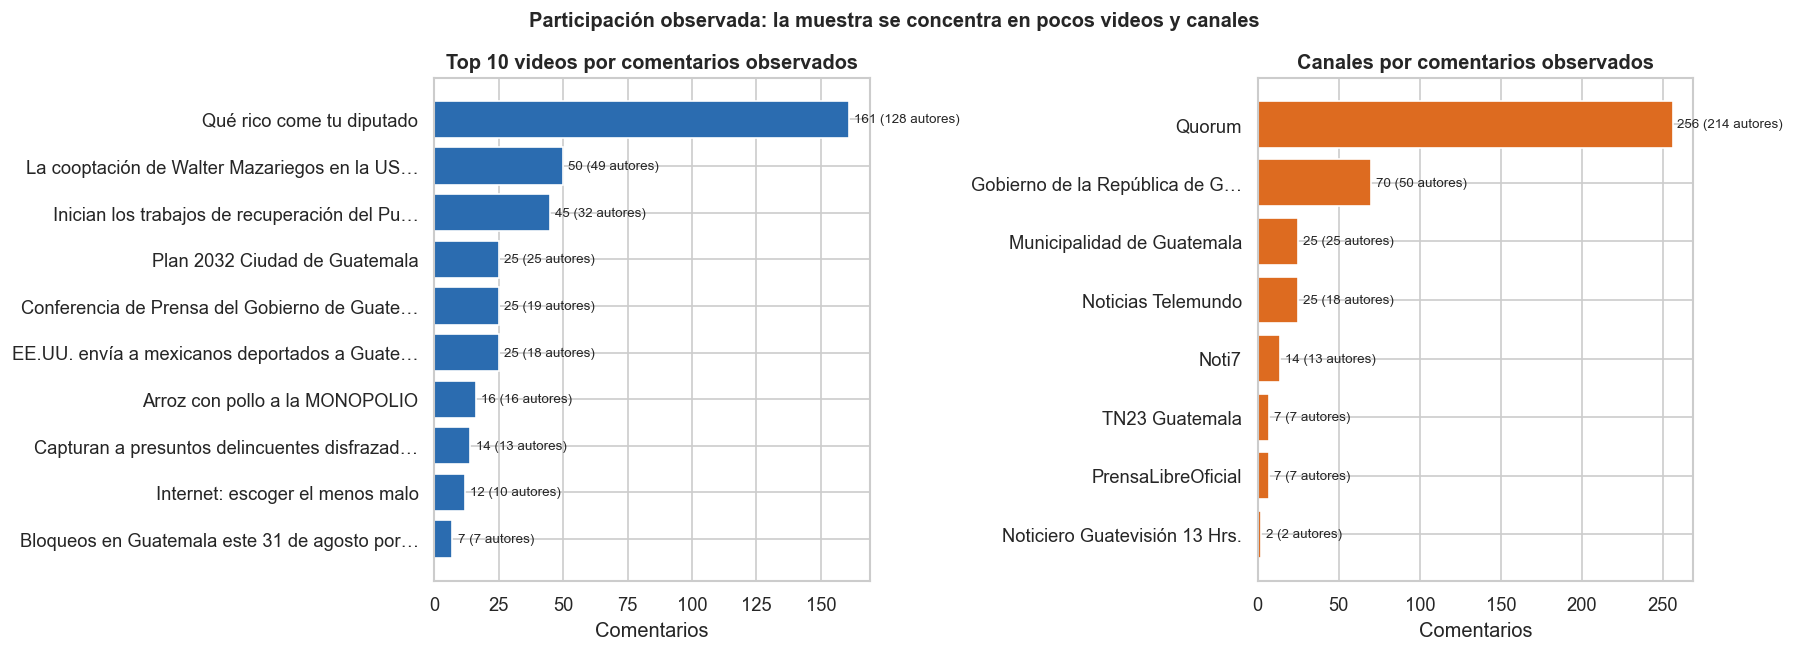

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
top_v = videos_eda.nlargest(10, "comentarios_obs").sort_values("comentarios_obs")
axes[0].barh([acortar(t, 44) for t in top_v["title"]], top_v["comentarios_obs"], color=AZUL)
axes[0].set(title="Top 10 videos por comentarios observados", xlabel="Comentarios")
for y, (c, a) in enumerate(zip(top_v["comentarios_obs"], top_v["autores_unicos"])):
    axes[0].text(c + 2, y, f"{c} ({a} autores)", va="center", fontsize=8)

top_c = por_canal.nlargest(8, "comentarios").sort_values("comentarios")
axes[1].barh([acortar(t, 30) for t in top_c["channel_name"]], top_c["comentarios"], color=NARANJA)
axes[1].set(title="Canales por comentarios observados", xlabel="Comentarios")
for y, (c, a) in enumerate(zip(top_c["comentarios"], top_c["autores"])):
    axes[1].text(c + 3, y, f"{c} ({a} autores)", va="center", fontsize=8)
fig.suptitle("Participación observada: la muestra se concentra en pocos videos y canales", fontweight="bold")
fig.tight_layout()
guardar_figura("01_top_participacion")

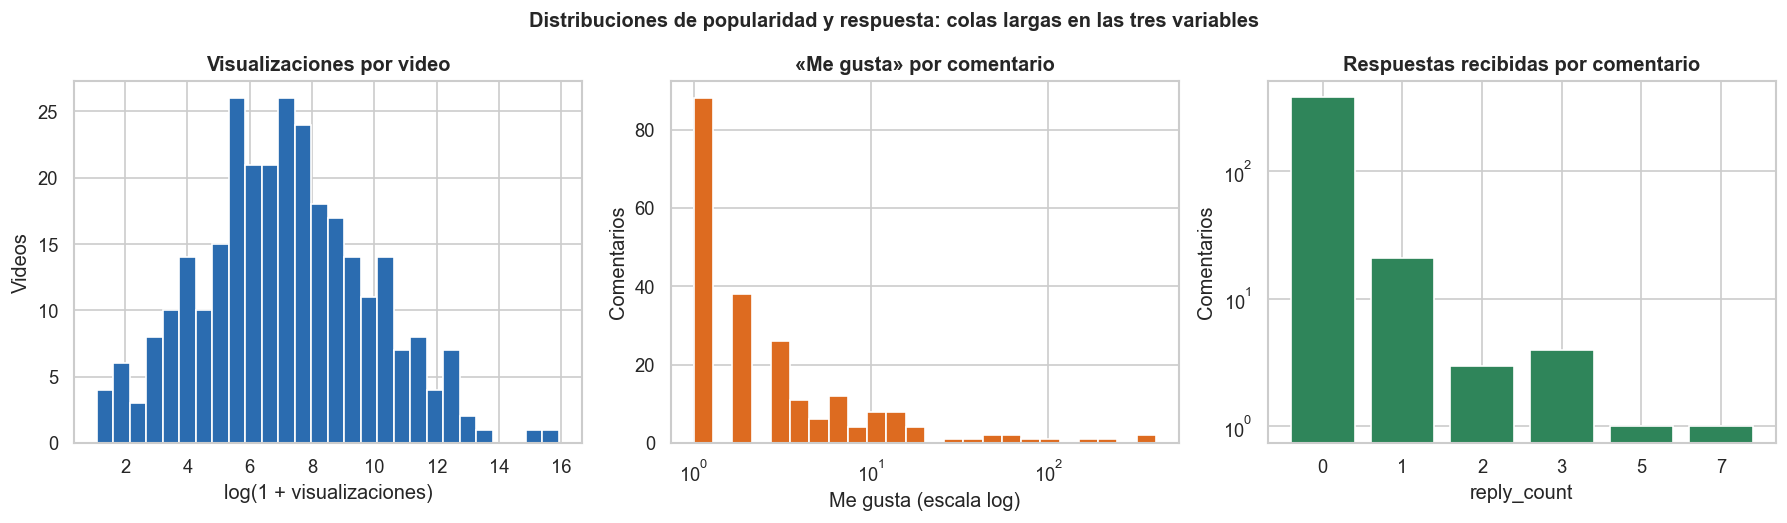

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
axes[0].hist(np.log1p(videos_eda["view_count"].astype(float)), bins=28, color=AZUL, edgecolor="white")
axes[0].set(title="Visualizaciones por video", xlabel="log(1 + visualizaciones)", ylabel="Videos")
axes[1].hist(comentarios["like_count"], bins=np.logspace(0, np.log10(max(comentarios["like_count"].max(), 2)), 25),
             color=NARANJA, edgecolor="white")
axes[1].set(title="«Me gusta» por comentario", xlabel="Me gusta (escala log)", ylabel="Comentarios", xscale="log")
conteo_respuestas = comentarios["reply_count"].value_counts().sort_index()
axes[2].bar(conteo_respuestas.index.astype(str), conteo_respuestas.values, color=VERDE)
axes[2].set(title="Respuestas recibidas por comentario", xlabel="reply_count", ylabel="Comentarios")
axes[2].set_yscale("log")
fig.suptitle("Distribuciones de popularidad y respuesta: colas largas en las tres variables", fontweight="bold")
fig.tight_layout()
guardar_figura("02_distribuciones_conteos")

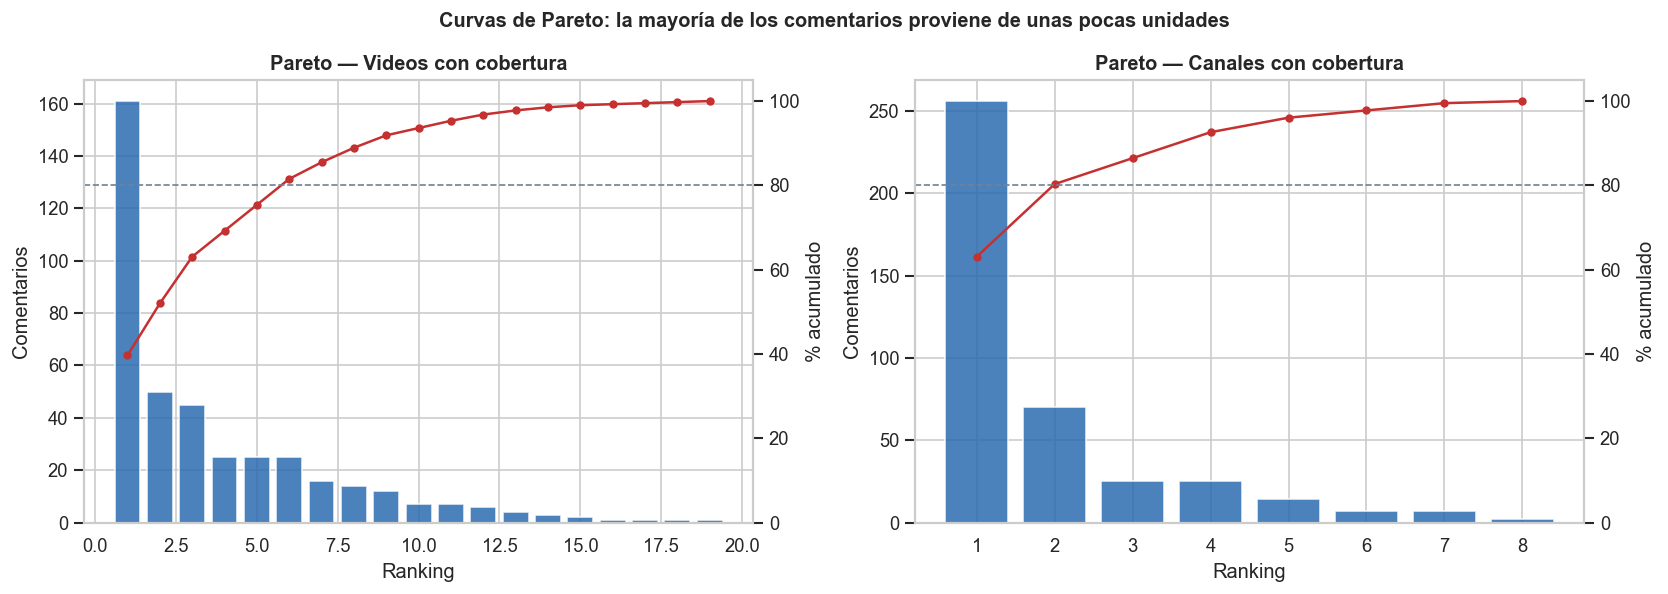

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for eje, valores, titulo in [
    (axes[0], por_video["comentarios_obs"].sort_values(ascending=False), "Videos con cobertura"),
    (axes[1], por_canal.query("comentarios > 0")["comentarios"].sort_values(ascending=False), "Canales con cobertura"),
]:
    acumulado = valores.cumsum() / valores.sum() * 100
    posiciones = np.arange(1, len(valores) + 1)
    eje.bar(posiciones, valores.values, color=AZUL, alpha=0.85, label="Comentarios")
    gemelo = eje.twinx()
    gemelo.plot(posiciones, acumulado.values, color=ROJO, marker="o", ms=4, label="Acumulado %")
    gemelo.axhline(80, color=GRIS, ls="--", lw=1)
    gemelo.set_ylim(0, 105)
    gemelo.set_ylabel("% acumulado")
    gemelo.grid(False)
    eje.set(title=f"Pareto — {titulo}", xlabel="Ranking", ylabel="Comentarios")
fig.suptitle("Curvas de Pareto: la mayoría de los comentarios proviene de unas pocas unidades", fontweight="bold")
fig.tight_layout()
guardar_figura("03_concentracion_pareto")

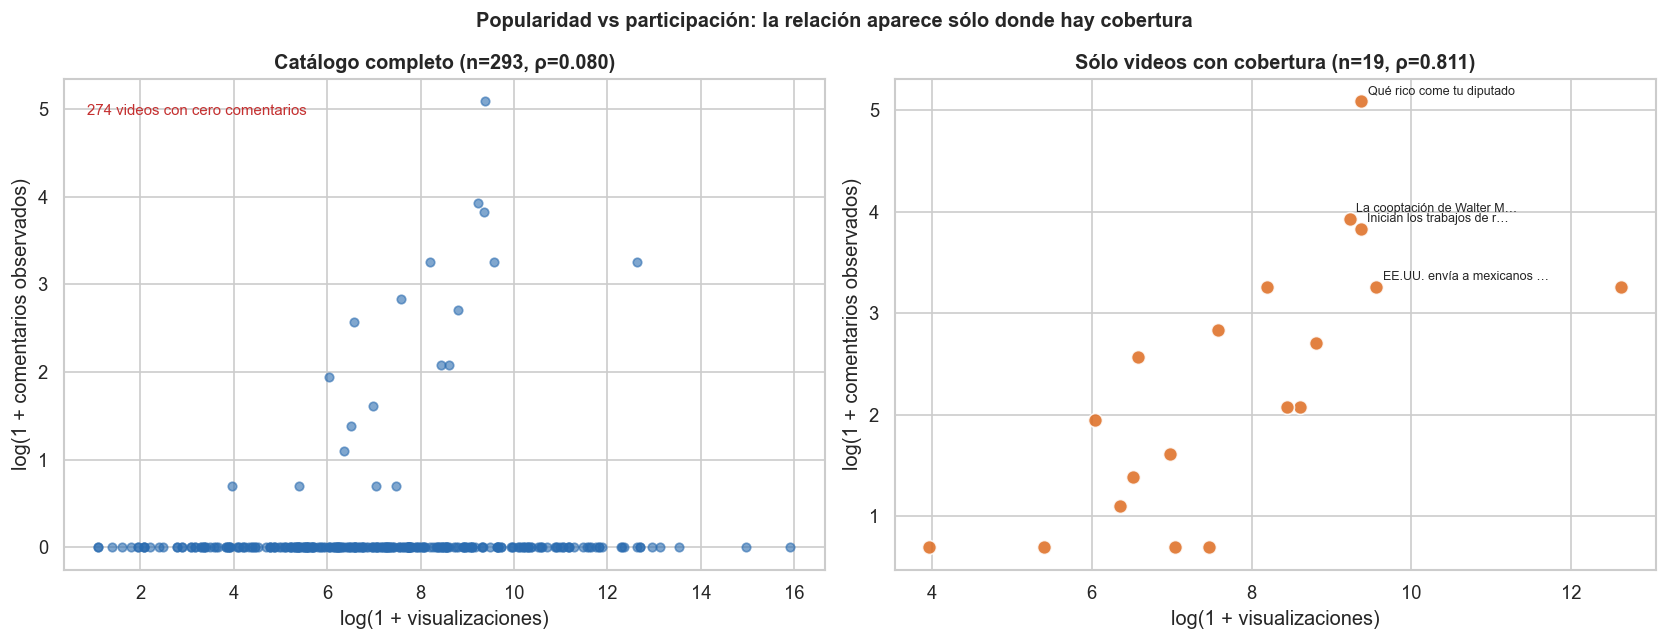

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
axes[0].scatter(np.log1p(videos_eda["view_count"].astype(float)), np.log1p(videos_eda["comentarios_obs"]),
                color=AZUL, alpha=0.6, s=26)
axes[0].set(title=f"Catálogo completo (n={len(videos_eda)}, ρ={rho_todos:.3f})",
            xlabel="log(1 + visualizaciones)", ylabel="log(1 + comentarios observados)")
axes[0].text(0.03, 0.95, f"{int((videos_eda['comentarios_obs'] == 0).sum())} videos con cero comentarios",
             transform=axes[0].transAxes, va="top", fontsize=9, color=ROJO)
axes[1].scatter(np.log1p(sub["view_count"].astype(float)), np.log1p(sub["comentarios_obs"]),
                color=NARANJA, alpha=0.85, s=70, edgecolor="white")
axes[1].set(title=f"Sólo videos con cobertura (n={len(sub)}, ρ={rho_cob:.3f})",
            xlabel="log(1 + visualizaciones)", ylabel="log(1 + comentarios observados)")
for _, fila in sub.nlargest(4, "comentarios_obs").iterrows():
    axes[1].annotate(acortar(fila["title"], 26), (np.log1p(float(fila["view_count"])), np.log1p(fila["comentarios_obs"])),
                     fontsize=7.5, xytext=(4, 4), textcoords="offset points")
fig.suptitle("Popularidad vs participación: la relación aparece sólo donde hay cobertura", fontweight="bold")
fig.tight_layout()
guardar_figura("04_visualizaciones_vs_comentarios")

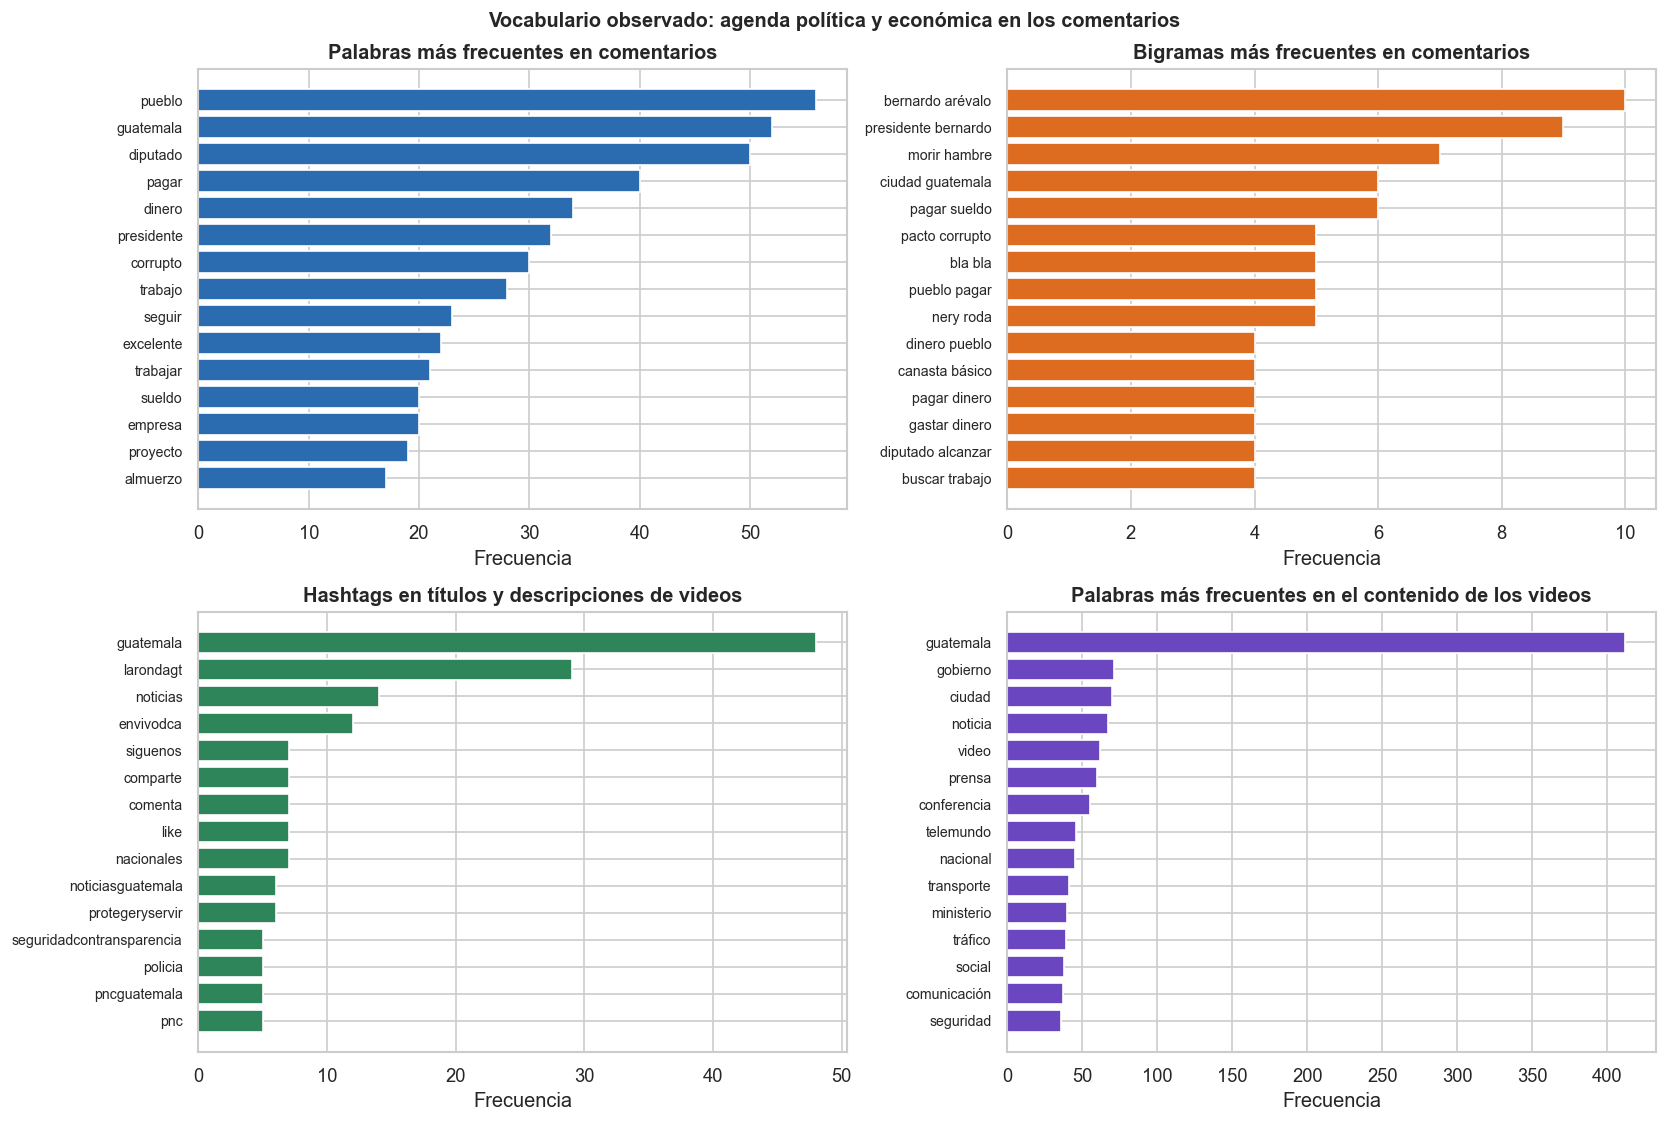

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9.5))
especificaciones = [
    (palabras_comentarios.head(15), "termino", "Palabras más frecuentes en comentarios", AZUL),
    (bigramas_comentarios.head(15), "bigrama", "Bigramas más frecuentes en comentarios", NARANJA),
    (hashtags_videos.head(15), "hashtag", "Hashtags en títulos y descripciones de videos", VERDE),
    (palabras_videos.head(15), "termino", "Palabras más frecuentes en el contenido de los videos", MORADO),
]
for eje, (frame, columna, titulo, color) in zip(axes.ravel(), especificaciones):
    datos = frame.sort_values("frecuencia")
    eje.barh(datos[columna], datos["frecuencia"], color=color)
    eje.set(title=titulo, xlabel="Frecuencia")
    eje.tick_params(axis="y", labelsize=8.5)
fig.suptitle("Vocabulario observado: agenda política y económica en los comentarios", fontweight="bold")
fig.tight_layout()
guardar_figura("05_frecuencias_texto")

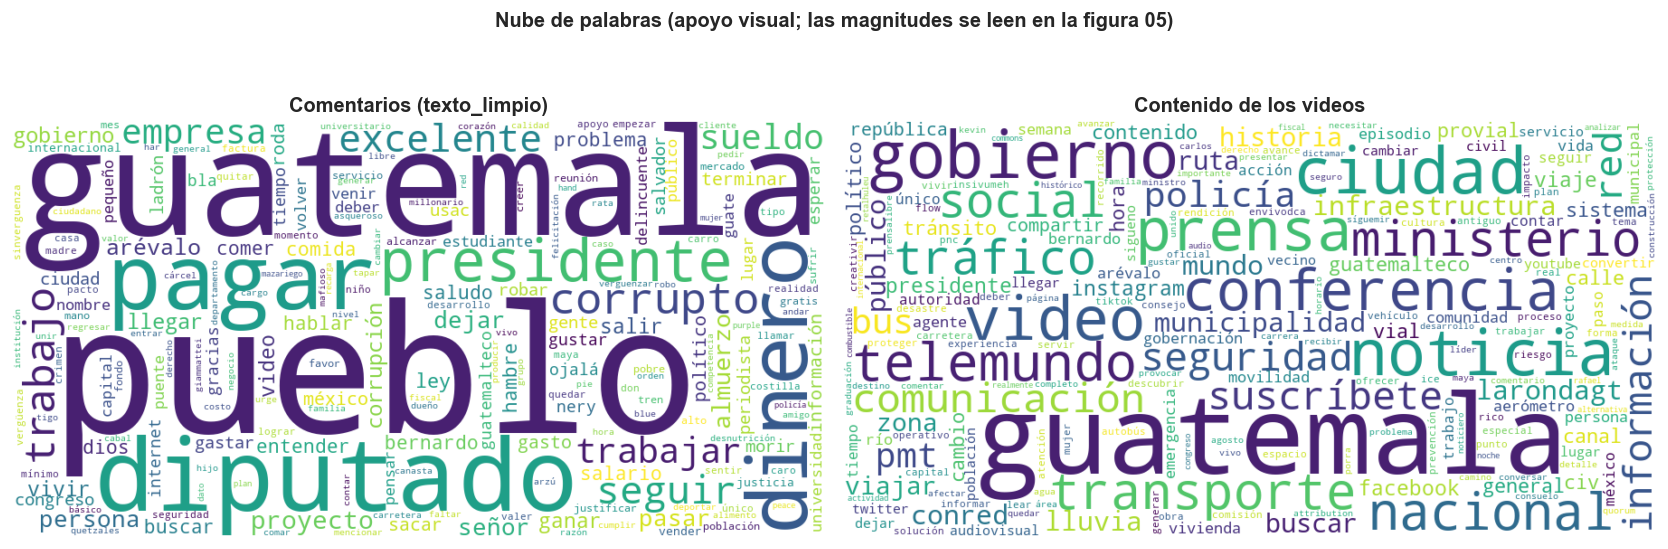

Nube de palabras generada.


In [27]:
try:
    from wordcloud import WordCloud
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
    for eje, textos, titulo in [
        (axes[0], " ".join(comentarios["texto_limpio"]), "Comentarios (texto_limpio)"),
        (axes[1], " ".join(videos["texto_limpio"]), "Contenido de los videos"),
    ]:
        nube = WordCloud(width=900, height=460, background_color="white", colormap="viridis",
                         random_state=RANDOM_SEED, collocations=False).generate(textos)
        eje.imshow(nube, interpolation="bilinear")
        eje.set_title(titulo)
        eje.axis("off")
    fig.suptitle("Nube de palabras (apoyo visual; las magnitudes se leen en la figura 05)", fontweight="bold")
    fig.tight_layout()
    guardar_figura("06_nube_de_palabras")
    print("Nube de palabras generada.")
except ImportError:
    print("wordcloud no está instalado; se omite la nube (los gráficos de barras la sustituyen).")

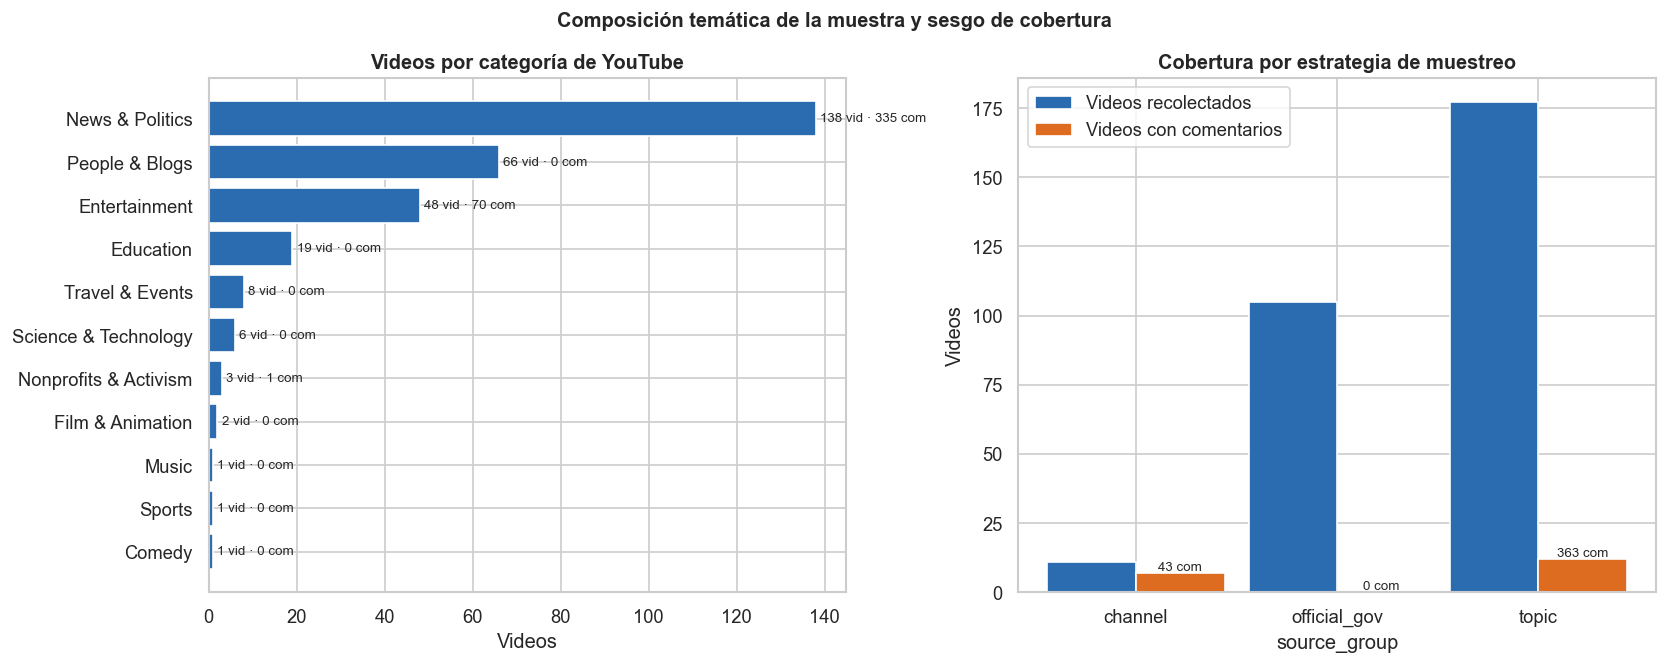

source_group  videos  comentarios  con_cobertura
     channel      11           43              7
official_gov     105            0              0
       topic     177          363             12


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
categorias = videos_eda["category"].value_counts().sort_values()
axes[0].barh(categorias.index, categorias.values, color=AZUL)
axes[0].set(title="Videos por categoría de YouTube", xlabel="Videos")
comentarios_por_categoria = videos_eda.groupby("category")["comentarios_obs"].sum().reindex(categorias.index)
for y, (v, c) in enumerate(zip(categorias.values, comentarios_por_categoria.values)):
    axes[0].text(v + 1, y, f"{v} vid · {int(c)} com", va="center", fontsize=8)

resumen_fuente = videos_eda.groupby("source_group").agg(
    videos=("video_id", "size"), comentarios=("comentarios_obs", "sum"),
    con_cobertura=("tiene_comentarios", "sum")).reset_index()
x = np.arange(len(resumen_fuente))
axes[1].bar(x - 0.22, resumen_fuente["videos"], width=0.44, color=AZUL, label="Videos recolectados")
axes[1].bar(x + 0.22, resumen_fuente["con_cobertura"], width=0.44, color=NARANJA, label="Videos con comentarios")
axes[1].set(title="Cobertura por estrategia de muestreo", xticks=x, xlabel="source_group", ylabel="Videos")
axes[1].set_xticklabels(resumen_fuente["source_group"])
axes[1].legend()
for i, fila in resumen_fuente.iterrows():
    axes[1].text(i + 0.22, fila["con_cobertura"] + 1, f"{int(fila['comentarios'])} com", ha="center", fontsize=8)
fig.suptitle("Composición temática de la muestra y sesgo de cobertura", fontweight="bold")
fig.tight_layout()
guardar_figura("07_categorias_y_fuentes")
registrar("resumen_fuente", resumen_fuente.to_dict("records"))
print(resumen_fuente.to_string(index=False))

### 3.5 Preguntas obligatorias del inciso 3.5

Cada respuesta se sostiene con una tabla calculada a continuación. Las preguntas sobre comunidades
se amplían en la actividad 7 con la partición formal, y las de sentimiento en la actividad 9.

In [29]:
# (a) ¿Qué videos y canales concentran la mayor participación observada?
concentran_videos = videos_eda.nlargest(5, "comentarios_obs")[
    ["title", "channel_name", "category", "view_count", "comentarios_obs", "autores_unicos", "likes"]
].assign(cuota_pct=lambda d: (100 * d["comentarios_obs"] / len(comentarios)).round(1))
concentran_canales = por_canal.nlargest(5, "comentarios")[
    ["channel_name", "videos", "videos_con_comentarios", "comentarios", "autores"]
].assign(cuota_pct=lambda d: (100 * d["comentarios"] / len(comentarios)).round(1))
guardar_tabla(concentran_videos, "28_p1_videos_que_concentran")
guardar_tabla(concentran_canales, "29_p1_canales_que_concentran")
registrar("p1_videos", concentran_videos.to_dict("records"))
registrar("p1_canales", concentran_canales.to_dict("records"))
print(concentran_videos.to_string(index=False))
print()
print(concentran_canales.to_string(index=False))

                                                                                            title                          channel_name        category  view_count  comentarios_obs  autores_unicos  likes  cuota_pct
                                                                        Qué rico come tu diputado                                Quorum News & Politics       11775              161             128    358       39.7
                                                    La cooptación de Walter Mazariegos en la USAC                                Quorum News & Politics       10156               50              49     91       12.3
                                       Inician los trabajos de recuperación del Puente Belice II. Gobierno de la República de Guatemala   Entertainment       11670               45              32     90       11.1
EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo                    Noticias Telemundo News

In [30]:
# (b) ¿Existen audiencias compartidas entre videos, canales o temas?
autores_multivideo = por_autor.query("videos > 1").sort_values(["canales", "videos", "comentarios"], ascending=False)
autores_multicanal = por_autor.query("canales > 1").sort_values(["canales", "comentarios"], ascending=False)

detalle_compartidos = (
    comentarios[comentarios["author_channel_id"].isin(autores_multivideo["author_channel_id"])]
    .groupby(["author_handle", "channel_name"])["video_id"].nunique()
    .reset_index(name="videos_comentados")
    .sort_values(["author_handle", "videos_comentados"], ascending=[True, False])
)
guardar_tabla(autores_multivideo, "30_p2_autores_en_varios_videos")
guardar_tabla(detalle_compartidos, "31_p2_detalle_audiencia_compartida")

audiencia = pd.DataFrame([
    ["Autores que comentan en más de un video", len(autores_multivideo), round(100 * len(autores_multivideo) / len(por_autor), 2)],
    ["Autores que comentan en más de un canal", len(autores_multicanal), round(100 * len(autores_multicanal) / len(por_autor), 2)],
    ["Autores exclusivos de un solo video", int((por_autor["videos"] == 1).sum()), round(100 * (por_autor["videos"] == 1).mean(), 2)],
], columns=["indicador", "autores", "porcentaje_del_total"])
guardar_tabla(audiencia, "32_p2_audiencia_compartida_resumen")
registrar("audiencia_compartida", audiencia.to_dict("records"))
registrar("autores_multivideo_n", len(autores_multivideo))
registrar("autores_multicanal_n", len(autores_multicanal))
print(audiencia.to_string(index=False))
print()
print(autores_multivideo.to_string(index=False))

                              indicador  autores  porcentaje_del_total
Autores que comentan en más de un video        9                  2.71
Autores que comentan en más de un canal        4                  1.20
    Autores exclusivos de un solo video      323                 97.29

       author_channel_id        author_handle  comentarios  videos  canales  likes  respuestas
UCHTGCgY2l-DQJIvlA_cpa_Q  @virgiliogarcia3039            3       2        2     14           0
UCdFlugHJJa4l3YqWuNRmvXw   @MarcosCarillo-b1r            2       2        2      0           1
UCjZgFEowMBrsjodqfovzdKw @franciscoflores3120            2       2        2      0           0
UCsUCN0Yq_UyTvKjOJLmNrnQ    @moisesvaldez4043            2       2        2      0           0
UCvcu1kR8xMYy_I1Ty-2mV2Q        @hashojea7348            4       3        1      0           0
UCpsKOkt5iWTbenzeuq7dsmQ       @inge_vergueta            3       3        1      4           0
UCylqlpsh8ENNM1LqgQ1KbxA         @Jel.Awesh.M     

In [31]:
# (c) ¿Qué autores funcionan como puentes entre contenidos que de otra forma permanecerían separados?
#     Evidencia preliminar: autores presentes en varios videos y, sobre todo, en varios canales.
puentes_preliminares = autores_multivideo.merge(
    comentarios.groupby("author_channel_id")["video_id"].apply(lambda s: " | ".join(sorted(set(s)))).rename("videos_ids"),
    on="author_channel_id", how="left",
).merge(
    comentarios.groupby("author_channel_id")["channel_name"].apply(lambda s: " | ".join(sorted(set(s)))).rename("canales"),
    on="author_channel_id", how="left",
)
guardar_tabla(puentes_preliminares, "33_p3_autores_puente_preliminares")
registrar("puentes_preliminares", puentes_preliminares.to_dict("records"))
puentes_preliminares[["author_handle", "comentarios", "videos", "canales_x", "canales_y"]].rename(
    columns={"canales_x": "n_canales", "canales_y": "canales"})

,author_handle,comentarios,videos,n_canales,canales
0,@virgiliogarcia3039,3,2,2,Gobierno de la República de Guatemala | Quorum
1,@MarcosCarillo-b1r,2,2,2,Quorum | TN23 Guatemala
2,@franciscoflores3120,2,2,2,Gobierno de la República de Guatemala | Noti7
3,@moisesvaldez4043,2,2,2,PrensaLibreOficial | Quorum
4,@hashojea7348,4,3,1,Quorum
5,@inge_vergueta,3,3,1,Quorum
6,@Jel.Awesh.M,3,2,1,Quorum
7,@Alejandro00710,2,2,1,Quorum
8,@josegil3813,2,2,1,Gobierno de la República de Guatemala


In [32]:
# (d) ¿Qué temas y sentimientos caracterizan la participación por video? (nivel comunidad: act. 7 y 9)
def terminos_de(video_id: str, n: int = 6) -> str:
    textos = comentarios.loc[comentarios["video_id"] == video_id, "texto_limpio"]
    contador = Counter(t for texto in textos for t in str(texto).split())
    return ", ".join(t for t, _ in contador.most_common(n))


perfil_videos = por_video.merge(
    videos[["video_id", "title", "channel_name", "category"]], on="video_id", how="left"
)
perfil_videos["terminos"] = perfil_videos["video_id"].map(terminos_de)
sentimiento_video = comentarios.groupby("video_id").agg(
    sent_medio=("puntaje_sentimiento", "mean"),
    pct_neg=("sentimiento", lambda s: round(100 * (s == "NEG").mean(), 1)),
    pct_pos=("sentimiento", lambda s: round(100 * (s == "POS").mean(), 1)),
).reset_index()
perfil_videos = perfil_videos.merge(sentimiento_video, on="video_id", how="left")
perfil_videos["sent_medio"] = perfil_videos["sent_medio"].round(3)
perfil_videos = perfil_videos.sort_values("comentarios_obs", ascending=False)
guardar_tabla(perfil_videos[["video_id", "title", "channel_name", "category", "comentarios_obs",
                             "autores_unicos", "sent_medio", "pct_neg", "pct_pos", "terminos"]],
              "34_p4_perfil_tematico_y_sentimiento_por_video")
registrar("perfil_videos", perfil_videos.head(8)[
    ["title", "channel_name", "comentarios_obs", "sent_medio", "pct_neg", "pct_pos", "terminos"]].to_dict("records"))
print(perfil_videos.head(8)[["title", "comentarios_obs", "sent_medio", "pct_neg", "terminos"]].to_string(index=False))

                                                                                            title  comentarios_obs  sent_medio  pct_neg                                                        terminos
                                                                        Qué rico come tu diputado              161      -0.671     80.7                pueblo, diputado, pagar, dinero, trabajo, sueldo
                                                    La cooptación de Walter Mazariegos en la USAC               50      -0.342     58.0 corrupto, usac, estudiante, universidad, excelente, información
                                       Inician los trabajos de recuperación del Puente Belice II.               45      -0.109     40.0    presidente, guatemala, proyecto, arévalo, terminar, bernardo
EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo               25      -0.473     64.0                   you, deportar, entrar, méxico, persona, pasar


In [33]:
# (e) ¿La visibilidad medida por visualizaciones coincide con la participación observada?
ranking = sub.copy()
ranking["rank_vistas"] = ranking["view_count"].rank(ascending=False, method="min").astype(int)
ranking["rank_comentarios"] = ranking["comentarios_obs"].rank(ascending=False, method="min").astype(int)
ranking["desfase"] = ranking["rank_vistas"] - ranking["rank_comentarios"]
ranking["comentarios_por_10k_vistas"] = (
    10_000 * ranking["comentarios_obs"] / ranking["view_count"].astype(float)).round(2)
ranking = ranking.sort_values("rank_comentarios")
guardar_tabla(ranking[["title", "channel_name", "view_count", "comentarios_obs",
                       "rank_vistas", "rank_comentarios", "desfase", "comentarios_por_10k_vistas"]],
              "35_p5_visibilidad_vs_participacion")
registrar("ranking_visibilidad", ranking.head(10)[
    ["title", "view_count", "comentarios_obs", "rank_vistas", "rank_comentarios", "comentarios_por_10k_vistas"]
].to_dict("records"))
registrar("desfase_max", int(ranking["desfase"].abs().max()))
print(ranking[["title", "view_count", "comentarios_obs", "rank_vistas", "rank_comentarios",
               "comentarios_por_10k_vistas"]].head(10).to_string(index=False))

                                                                                            title  view_count  comentarios_obs  rank_vistas  rank_comentarios  comentarios_por_10k_vistas
                                                                        Qué rico come tu diputado       11775              161            3                 1                      136.73
                                                    La cooptación de Walter Mazariegos en la USAC       10156               50            5                 2                       49.23
                                       Inician los trabajos de recuperación del Puente Belice II.       11670               45            4                 3                       38.56
EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo       14200               25            2                 4                       17.61
                                      Conferencia de Prensa del Gobier

In [34]:
# (f) ¿Qué conclusiones están limitadas por el procedimiento de recolección y la cobertura?
cobertura_por_fuente = videos_eda.groupby("source_group").agg(
    videos=("video_id", "size"),
    con_comentarios=("tiene_comentarios", "sum"),
    comentarios=("comentarios_obs", "sum"),
    vistas_medianas=("view_count", "median"),
).reset_index()
cobertura_por_fuente["cobertura_pct"] = (
    100 * cobertura_por_fuente["con_comentarios"] / cobertura_por_fuente["videos"]).round(1)
guardar_tabla(cobertura_por_fuente, "36_p6_cobertura_por_estrategia")
registrar("cobertura_por_fuente", cobertura_por_fuente.to_dict("records"))
print(cobertura_por_fuente.to_string(index=False))

source_group  videos  con_comentarios  comentarios  vistas_medianas  cobertura_pct
     channel      11                7           43            673.0           63.6
official_gov     105                0            0            521.0            0.0
       topic     177               12          363           2214.0            6.8


### 3.6 Tres preguntas adicionales surgidas del análisis exploratorio

1. ¿La intensidad de participación de un autor (varios comentarios en el mismo video) se comporta
   distinto de su amplitud (comentar en varios videos)?
2. ¿Los comentarios con más «me gusta» son sistemáticamente más negativos que el resto?
3. ¿La estrategia de muestreo (`source_group`) produce perfiles temáticos y de sentimiento distintos?

In [35]:
# Pregunta adicional 1: intensidad vs amplitud.
por_autor_ext = por_autor.merge(
    comentarios.groupby("author_channel_id")["puntaje_sentimiento"].mean().rename("sent_medio"),
    on="author_channel_id", how="left")
por_autor_ext["comentarios_por_video"] = (por_autor_ext["comentarios"] / por_autor_ext["videos"]).round(2)

intensidad = pd.DataFrame([
    ["Autores con 1 comentario en 1 video", int(((por_autor_ext["comentarios"] == 1) & (por_autor_ext["videos"] == 1)).sum())],
    ["Autores con varios comentarios en un solo video (intensidad)",
     int(((por_autor_ext["comentarios"] > 1) & (por_autor_ext["videos"] == 1)).sum())],
    ["Autores presentes en varios videos (amplitud)", int((por_autor_ext["videos"] > 1).sum())],
    ["Máximo de comentarios de un autor en un mismo video",
     int(comentarios.groupby(["author_channel_id", "video_id"]).size().max())],
], columns=["perfil", "autores"])
rho_int, p_int = spearman(por_autor_ext["comentarios"], por_autor_ext["videos"])
guardar_tabla(intensidad, "37_extra1_intensidad_vs_amplitud")
registrar("intensidad", intensidad.to_dict("records"))
registrar("rho_intensidad_amplitud", round(rho_int, 3))
print(intensidad.to_string(index=False))
print(f"\nSpearman entre número de comentarios y número de videos por autor: ρ={rho_int:.3f} (p={p_int:.4f})")

                                                      perfil  autores
                         Autores con 1 comentario en 1 video      286
Autores con varios comentarios en un solo video (intensidad)       37
               Autores presentes en varios videos (amplitud)        9
         Máximo de comentarios de un autor en un mismo video        6

Spearman entre número de comentarios y número de videos por autor: ρ=0.420 (p=0.0000)


In [36]:
# Pregunta adicional 2: ¿los comentarios más aplaudidos son más negativos?
comentarios["tramo_likes"] = pd.cut(
    comentarios["like_count"], bins=[-1, 0, 2, 10, 50, np.inf],
    labels=["0", "1–2", "3–10", "11–50", ">50"])
likes_sentimiento = comentarios.groupby("tramo_likes", observed=True).agg(
    comentarios_n=("comment_id", "size"),
    sent_medio=("puntaje_sentimiento", "mean"),
    pct_negativos=("sentimiento", lambda s: round(100 * (s == "NEG").mean(), 1)),
    likes_medianos=("like_count", "median"),
).reset_index()
likes_sentimiento["sent_medio"] = likes_sentimiento["sent_medio"].round(3)
rho_ls, p_ls = spearman(comentarios["like_count"], comentarios["puntaje_sentimiento"])
guardar_tabla(likes_sentimiento, "38_extra2_likes_vs_sentimiento")
registrar("likes_sentimiento", likes_sentimiento.to_dict("records"))
registrar("rho_likes_sentimiento", round(rho_ls, 3))
registrar("p_likes_sentimiento", round(p_ls, 4))
print(likes_sentimiento.to_string(index=False))
print(f"\nSpearman entre «me gusta» y puntaje de sentimiento: ρ={rho_ls:.3f} (p={p_ls:.4f})")

tramo_likes  comentarios_n  sent_medio  pct_negativos  likes_medianos
          0            189      -0.529           69.8             0.0
        1–2            126      -0.348           57.1             1.0
       3–10             63      -0.241           57.1             4.0
      11–50             19      -0.070           47.4            15.0
        >50              9       0.729            0.0           113.0

Spearman entre «me gusta» y puntaje de sentimiento: ρ=0.234 (p=0.0000)


In [37]:
# Pregunta adicional 3: ¿la estrategia de muestreo produce perfiles distintos?
perfil_fuente = comentarios.groupby("source_group").agg(
    comentarios_n=("comment_id", "size"),
    autores=("author_channel_id", "nunique"),
    videos=("video_id", "nunique"),
    likes_medianos=("like_count", "median"),
    sent_medio=("puntaje_sentimiento", "mean"),
    pct_negativos=("sentimiento", lambda s: round(100 * (s == "NEG").mean(), 1)),
).reset_index()
perfil_fuente["sent_medio"] = perfil_fuente["sent_medio"].round(3)
perfil_fuente["terminos"] = perfil_fuente["source_group"].map(
    lambda g: ", ".join(t for t, _ in Counter(
        t for texto in comentarios.loc[comentarios["source_group"] == g, "texto_limpio"]
        for t in str(texto).split()).most_common(6)))
guardar_tabla(perfil_fuente, "39_extra3_perfil_por_estrategia")
registrar("perfil_fuente", perfil_fuente.to_dict("records"))
print(perfil_fuente.to_string(index=False))

source_group  comentarios_n  autores  videos  likes_medianos  sent_medio  pct_negativos                                                   terminos
     channel            231      192      11             1.0      -0.543           71.9           pueblo, diputado, pagar, dinero, trabajo, sueldo
       topic            175      144       9             1.0      -0.162           47.4 guatemala, presidente, proyecto, arévalo, gobierno, saludo


## 4. Construcción de la red bipartita autor–video

### 4.5 Qué significa exactamente una arista (se declara antes de construirla)

Una arista **no dirigida** `autor — video` significa **una sola cosa**: *ese autor publicó al menos
un comentario principal en ese video dentro de la muestra recolectada*. Su **peso** es el número de
comentarios que ese autor publicó en ese video.

Una arista **no** significa:

- que el autor sea amigo, seguidor o suscriptor del canal;
- que exista conversación directa con nadie (los datos no dicen quién respondió a quién);
- aprobación del contenido: la actividad 9 muestra que la mayoría de los comentarios son negativos,
  de modo que participar suele ser sinónimo de criticar, no de apoyar;
- que el autor haya visto el video completo, ni que sea su única actividad en YouTube.

La red es **bipartita**: sólo existen aristas autor↔video. Nunca autor↔autor ni video↔video; esas
relaciones aparecen únicamente como *proyecciones* (actividad 5), que son construcciones derivadas.

### 4.1 – 4.3 Tabla de nodos, tabla de aristas y construcción del grafo

In [38]:
def valor_grafo(valor):
    """Convierte a tipos que GraphML admite."""
    if isinstance(valor, (list, tuple, set, dict)):
        return json.dumps(list(valor), ensure_ascii=False)
    try:
        if valor is None or bool(pd.isna(valor)):
            return ""
    except (TypeError, ValueError):
        pass
    if isinstance(valor, (np.integer,)):
        return int(valor)
    if isinstance(valor, (np.floating,)):
        return float(valor)
    if isinstance(valor, (np.bool_,)):
        return bool(valor)
    return valor


# --- Tabla de aristas: una fila por par (autor, video) observado ---
aristas = comentarios.groupby(["author_channel_id", "video_id"]).agg(
    peso=("comment_id", "size"),
    likes=("like_count", "sum"),
    respuestas=("reply_count", "sum"),
    sent_medio=("puntaje_sentimiento", "mean"),
).reset_index()
aristas["sent_medio"] = aristas["sent_medio"].round(3)
aristas["origen"] = "author::" + aristas["author_channel_id"]
aristas["destino"] = "video::" + aristas["video_id"]
aristas["tipo_arista"] = "comento_en"
aristas = aristas.merge(comentarios[["author_channel_id", "author_handle"]].drop_duplicates(),
                        on="author_channel_id", how="left")
aristas = aristas.merge(videos[["video_id", "title", "channel_name"]], on="video_id", how="left")

# --- Tabla de nodos: autores + TODOS los videos del catálogo ---
nodos_autor = por_autor.rename(columns={"comentarios": "comentarios_publicados",
                                        "videos": "videos_comentados",
                                        "canales": "canales_comentados"}).copy()
nodos_autor = nodos_autor.merge(
    comentarios.groupby("author_channel_id")["puntaje_sentimiento"].mean().round(3).rename("sent_medio"),
    on="author_channel_id", how="left")
nodos_autor["node_id"] = "author::" + nodos_autor["author_channel_id"]
nodos_autor["tipo_nodo"] = "autor"
nodos_autor["bipartite"] = 0
nodos_autor["etiqueta"] = nodos_autor["author_handle"]
nodos_autor["id_original"] = nodos_autor["author_channel_id"]

nodos_video = videos_eda.rename(columns={"comentarios_obs": "comentarios_recibidos",
                                         "autores_unicos": "autores_distintos"}).copy()
nodos_video = nodos_video.merge(sentimiento_video[["video_id", "sent_medio"]], on="video_id", how="left")
nodos_video["node_id"] = "video::" + nodos_video["video_id"]
nodos_video["tipo_nodo"] = "video"
nodos_video["bipartite"] = 1
nodos_video["etiqueta"] = nodos_video["title"].map(lambda t: acortar(t, 60))
nodos_video["id_original"] = nodos_video["video_id"]

COLS_NODO = ["node_id", "tipo_nodo", "bipartite", "etiqueta", "id_original"]
nodos = pd.concat([
    nodos_autor[COLS_NODO + ["comentarios_publicados", "videos_comentados", "canales_comentados",
                             "likes", "respuestas", "sent_medio"]],
    nodos_video[COLS_NODO + ["channel_id", "channel_name", "category", "source_group", "view_count",
                             "comentarios_recibidos", "autores_distintos", "sent_medio", "tiene_comentarios"]],
], ignore_index=True)
nodos["observado"] = np.where(
    nodos["tipo_nodo"] == "autor", True, nodos["tiene_comentarios"].fillna(False)).astype(bool)

guardar_tabla(nodos, "40_nodos_red_bipartita")
guardar_tabla(aristas[["origen", "destino", "peso", "likes", "respuestas", "sent_medio", "tipo_arista",
                       "author_channel_id", "author_handle", "video_id", "title", "channel_name"]],
              "41_aristas_red_bipartita")
print(f"Nodos: {len(nodos)} (autores: {(nodos['tipo_nodo'] == 'autor').sum()}, videos: {(nodos['tipo_nodo'] == 'video').sum()})")
print(f"Aristas: {len(aristas)} — peso total: {int(aristas['peso'].sum())} (= total de comentarios)")
nodos.head(4)

Nodos: 625 (autores: 332, videos: 293)
Aristas: 343 — peso total: 406 (= total de comentarios)


,node_id,tipo_nodo,bipartite,etiqueta,id_original,comentarios_publicados,videos_comentados,canales_comentados,likes,respuestas,sent_medio,channel_id,channel_name,category,source_group,view_count,comentarios_recibidos,autores_distintos,tiene_comentarios,observado
0,author::UC-HeUTT6_g-VoiWds2a4H-w,autor,0,@JorgeMunoz-gd9et,UC-HeUTT6_g-VoiWds2a4H-w,1,1.0,1.0,0.0,0.0,0.449,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,True
1,author::UC-Iul5tDYH_oiAMXQH-KaaQ,autor,0,@AlbertoMancilla-p9h,UC-Iul5tDYH_oiAMXQH-KaaQ,1,1.0,1.0,1.0,0.0,0.920,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,True
2,author::UC-QOpE7GOxlXcHZ8b7HbQKA,autor,0,@mariaalexander427,UC-QOpE7GOxlXcHZ8b7HbQKA,2,1.0,1.0,0.0,0.0,-0.742,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,True
3,author::UC-fiZBS5Gp1eCJd9ucgWnCg,autor,0,@Tommii.10,UC-fiZBS5Gp1eCJd9ucgWnCg,1,1.0,1.0,6.0,0.0,-0.476,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,True


In [39]:
aristas[["origen", "destino", "peso", "likes", "respuestas", "sent_medio", "author_handle", "title"]].head(6)

,origen,destino,peso,likes,respuestas,sent_medio,author_handle,title
0,author::UC-HeUTT6_g-VoiWds2a4H-w,video::6W4u8sGEnGM,1,0,0,0.449,@JorgeMunoz-gd9et,Inician los trabajos de recuperación del Puente Belice II.
1,author::UC-Iul5tDYH_oiAMXQH-KaaQ,video::6W4u8sGEnGM,1,1,0,0.920,@AlbertoMancilla-p9h,Inician los trabajos de recuperación del Puente Belice II.
2,author::UC-QOpE7GOxlXcHZ8b7HbQKA,video::OkXlHx0hx-8,2,0,0,-0.742,@mariaalexander427,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticia...
3,author::UC-fiZBS5Gp1eCJd9ucgWnCg,video::j43HgwYFKfk,1,6,0,-0.476,@Tommii.10,La cooptación de Walter Mazariegos en la USAC
4,author::UC-hfX8J5JPJ-dfuakzegMLA,video::n8iP75gIpmw,1,6,0,0.574,@normaleticiaorozcojuarez2418,Qué rico come tu diputado
5,author::UC-jS_kA9w-OmpupXDx156Rg,video::n8iP75gIpmw,1,2,0,-0.963,@simoncreyesc7579,Qué rico come tu diputado


In [40]:
# --- Grafo completo (incluye los 274 videos sin comentarios recolectados) ---
G_completo = nx.Graph()
for _, fila in nodos.iterrows():
    atributos = {k: valor_grafo(v) for k, v in fila.items() if k != "node_id"}
    G_completo.add_node(fila["node_id"], **atributos)
for _, fila in aristas.iterrows():
    G_completo.add_edge(fila["origen"], fila["destino"], weight=int(fila["peso"]),
                        likes=int(fila["likes"]), respuestas=int(fila["respuestas"]),
                        sent_medio=float(fila["sent_medio"]), tipo="comento_en")

# --- Subgrafo observado: sólo nodos con al menos una arista ---
G_obs = G_completo.subgraph([n for n, g in G_completo.degree() if g > 0]).copy()

AUTORES_G = {n for n, d in G_completo.nodes(data=True) if d["tipo_nodo"] == "autor"}
VIDEOS_G = {n for n, d in G_completo.nodes(data=True) if d["tipo_nodo"] == "video"}
AUTORES_OBS = [n for n in G_obs if G_obs.nodes[n]["tipo_nodo"] == "autor"]
VIDEOS_OBS = [n for n in G_obs if G_obs.nodes[n]["tipo_nodo"] == "video"]

validacion = pd.DataFrame([
    ["¿Es bipartita?", nx.is_bipartite(G_completo)],
    ["Aristas dentro del mismo tipo (deben ser 0)",
     sum(1 for u, v in G_completo.edges() if G_completo.nodes[u]["tipo_nodo"] == G_completo.nodes[v]["tipo_nodo"])],
    ["Suma de pesos = número de comentarios",
     int(sum(d["weight"] for _, _, d in G_completo.edges(data=True))) == len(comentarios)],
    ["Nodos totales (red completa)", G_completo.number_of_nodes()],
    ["Aristas totales", G_completo.number_of_edges()],
    ["Nodos en la subred observada", G_obs.number_of_nodes()],
    ["Videos sin ninguna arista (falta de cobertura)", len(VIDEOS_G) - len(VIDEOS_OBS)],
], columns=["verificación", "resultado"])
guardar_tabla(validacion.astype(str), "42_validacion_red_bipartita")
registrar("red_nodos_total", G_completo.number_of_nodes())
registrar("red_aristas_total", G_completo.number_of_edges())
registrar("red_obs_nodos", G_obs.number_of_nodes())
registrar("red_obs_autores", len(AUTORES_OBS))
registrar("red_obs_videos", len(VIDEOS_OBS))
registrar("peso_total", int(aristas["peso"].sum()))
registrar("peso_max", int(aristas["peso"].max()))
validacion

,verificación,resultado
0,¿Es bipartita?,True
1,Aristas dentro del mismo tipo (deben ser 0),0
2,Suma de pesos = número de comentarios,True
3,Nodos totales (red completa),625
4,Aristas totales,343
5,Nodos en la subred observada,351
6,Videos sin ninguna arista (falta de cobertura),274


In [41]:
nx.write_graphml(G_completo, GRAFOS / "red_bipartita_autor_video.graphml")
nx.write_graphml(G_obs, GRAFOS / "red_bipartita_observada.graphml")
print("GraphML exportado para inspección en Gephi.")

GraphML exportado para inspección en Gephi.


### 4.4 Visualización de la red completa

Se visualiza **la red completa, sin eliminar nodos**: los 274 videos sin comentarios recolectados
son un hallazgo sustantivo (el sesgo de cobertura) y borrarlos por estética ocultaría el resultado
más importante del muestreo. Se usan dos vistas complementarias porque una sola no basta: un
diseño bipartito en columnas que muestra la escala real, y un diseño de fuerzas sobre la subred
observada que revela la estructura interna.

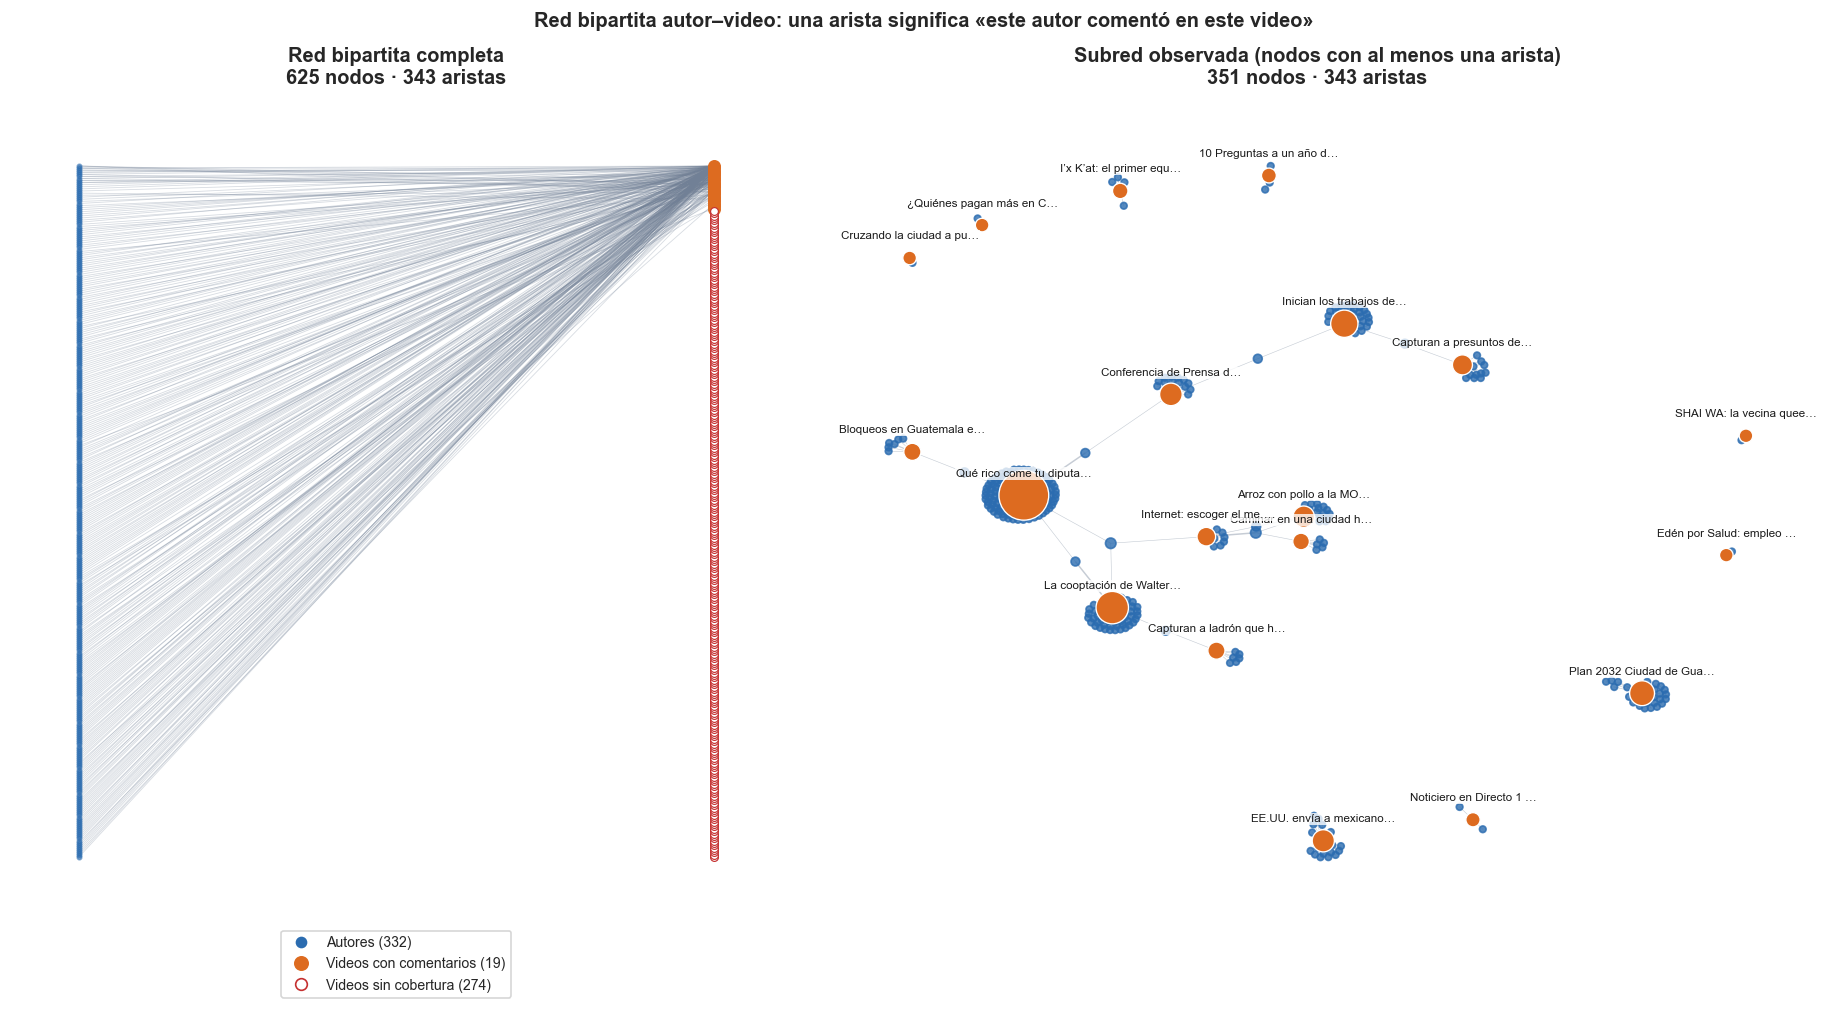

Figura 08 generada.


In [42]:
fig, ejes = plt.subplots(1, 2, figsize=(15.5, 8.5), gridspec_kw={"width_ratios": [1, 1.35]})

# Vista A: las dos particiones en columnas, incluyendo los videos sin cobertura.
autores_ordenados = sorted(AUTORES_G, key=lambda n: (G_completo.degree(n), n), reverse=True)
videos_ordenados = sorted(VIDEOS_G, key=lambda n: (G_completo.degree(n), n), reverse=True)
posicion = {}
posicion.update({n: (0.0, 1 - i / max(len(autores_ordenados) - 1, 1)) for i, n in enumerate(autores_ordenados)})
posicion.update({n: (1.0, 1 - i / max(len(videos_ordenados) - 1, 1)) for i, n in enumerate(videos_ordenados)})
videos_aislados = sorted(n for n in VIDEOS_G if G_completo.degree(n) == 0)

nx.draw_networkx_edges(G_completo, posicion, ax=ejes[0], edge_color=GRIS, alpha=0.28, width=0.5)
nx.draw_networkx_nodes(G_completo, posicion, nodelist=autores_ordenados, ax=ejes[0],
                       node_color=AZUL, node_size=7, alpha=0.55)
nx.draw_networkx_nodes(G_completo, posicion, nodelist=[n for n in videos_ordenados if G_completo.degree(n) > 0],
                       ax=ejes[0], node_color=NARANJA, node_size=46)
nx.draw_networkx_nodes(G_completo, posicion, nodelist=videos_aislados, ax=ejes[0],
                       node_color="white", edgecolors=ROJO, linewidths=0.7, node_size=22)
ejes[0].set_title(f"Red bipartita completa\n{G_completo.number_of_nodes()} nodos · {G_completo.number_of_edges()} aristas")
ejes[0].axis("off")
ejes[0].legend(handles=[
    Line2D([], [], marker="o", ls="", color=AZUL, ms=6, label=f"Autores ({len(AUTORES_G)})"),
    Line2D([], [], marker="o", ls="", color=NARANJA, ms=8, label=f"Videos con comentarios ({len(VIDEOS_OBS)})"),
    Line2D([], [], marker="o", ls="", mfc="white", mec=ROJO, ms=7, label=f"Videos sin cobertura ({len(videos_aislados)})"),
], loc="lower center", frameon=True, fontsize=8.5, bbox_to_anchor=(0.5, -0.09))

# Vista B: subred observada con diseño de fuerzas.
pos_obs = nx.spring_layout(G_obs, seed=RANDOM_SEED, k=0.30, iterations=400, weight="weight")
tam_video = [60 + 6.5 * G_obs.degree(n) for n in VIDEOS_OBS]
pesos = [G_obs[u][v]["weight"] for u, v in G_obs.edges()]
nx.draw_networkx_edges(G_obs, pos_obs, ax=ejes[1], edge_color=GRIS, alpha=0.4,
                       width=[0.35 + 0.55 * (w - 1) for w in pesos])
nx.draw_networkx_nodes(G_obs, pos_obs, nodelist=AUTORES_OBS, ax=ejes[1], node_color=AZUL,
                       node_size=[16 + 12 * (G_obs.degree(n) - 1) for n in AUTORES_OBS], alpha=0.8)
nx.draw_networkx_nodes(G_obs, pos_obs, nodelist=VIDEOS_OBS, ax=ejes[1], node_color=NARANJA,
                       node_size=tam_video, edgecolors="white", linewidths=0.8)
etiquetas_desplazadas = {n: (x, y + 0.055) for n, (x, y) in pos_obs.items() if n in VIDEOS_OBS}
textos = nx.draw_networkx_labels(
    G_obs, etiquetas_desplazadas, ax=ejes[1], font_size=7.0,
    labels={n: acortar(G_obs.nodes[n]["etiqueta"], 24) for n in VIDEOS_OBS})
for texto in textos.values():
    texto.set_bbox(dict(facecolor="white", edgecolor="none", alpha=0.78, pad=0.6))
ejes[1].set_title(f"Subred observada (nodos con al menos una arista)\n"
                  f"{G_obs.number_of_nodes()} nodos · {G_obs.number_of_edges()} aristas")
ejes[1].axis("off")
fig.suptitle("Red bipartita autor–video: una arista significa «este autor comentó en este video»",
             fontweight="bold", y=0.98)
fig.tight_layout()
guardar_figura("08_red_bipartita")
print("Figura 08 generada.")

## 5. Proyecciones de la red

### 5.1 – 5.2 Proyección autor–autor y proyección video–video

- **Autor–autor**: dos autores se conectan si comentaron en el **mismo video**. El peso es el
  **número de videos que comparten**.
- **Video–video**: dos videos se conectan si comparten **al menos un autor**. El peso es el
  **número de autores compartidos**.

Ambas se calculan sobre la subred observada. Advertencia estructural: una proyección convierte cada
video en una **camarilla** (*clique*) entre todos sus comentaristas, de modo que el número de
aristas crece con el cuadrado del número de comentaristas y **no** representa interacción real.

In [43]:
from networkx.algorithms import bipartite

def proyectar(G: nx.Graph, lado: list[str]) -> nx.Graph:
    """Proyección ponderada con orden canónico.

    networkx recorre conjuntos para construir la proyección, y el orden de iteración de conjuntos
    de cadenas varía entre procesos por la aleatorización del hash. Eso no cambia el grafo, pero sí
    el orden de nodos y aristas, y con él las tablas exportadas y los diseños de fuerzas. Se
    reconstruye el grafo insertando nodos y aristas ordenados para que el análisis sea reproducible
    bit a bit.
    """
    bruta = bipartite.weighted_projected_graph(G, lado)
    canonica = nx.Graph()
    canonica.add_nodes_from(sorted(bruta.nodes(data=True)), )
    for u, v, datos in sorted(bruta.edges(data=True), key=lambda e: (e[0], e[1])):
        canonica.add_edge(u, v, **datos)
    return canonica


P_autores = proyectar(G_obs, sorted(AUTORES_OBS))
P_videos = proyectar(G_obs, sorted(VIDEOS_OBS))

aristas_pa = pd.DataFrame(
    [{"autor_a": G_obs.nodes[u]["etiqueta"], "autor_b": G_obs.nodes[v]["etiqueta"],
      "videos_compartidos": d["weight"], "nodo_a": u, "nodo_b": v}
     for u, v, d in P_autores.edges(data=True)]
).sort_values(["videos_compartidos", "nodo_a", "nodo_b"], ascending=[False, True, True])

aristas_pv = pd.DataFrame(
    [{"video_a": G_obs.nodes[u]["etiqueta"], "video_b": G_obs.nodes[v]["etiqueta"],
      "autores_compartidos": d["weight"], "nodo_a": u, "nodo_b": v}
     for u, v, d in P_videos.edges(data=True)]
).sort_values(["autores_compartidos", "nodo_a", "nodo_b"], ascending=[False, True, True])

guardar_tabla(aristas_pa, "43_aristas_proyeccion_autor_autor")
guardar_tabla(aristas_pv, "44_aristas_proyeccion_video_video")
nx.write_graphml(P_autores, GRAFOS / "proyeccion_autor_autor.graphml")
nx.write_graphml(P_videos, GRAFOS / "proyeccion_video_video.graphml")

registrar("pa_nodos", P_autores.number_of_nodes())
registrar("pa_aristas", P_autores.number_of_edges())
registrar("pv_nodos", P_videos.number_of_nodes())
registrar("pv_aristas", P_videos.number_of_edges())
registrar("pv_aristas_top", aristas_pv.head(6)[["video_a", "video_b", "autores_compartidos"]].to_dict("records"))
print(aristas_pv.head(8)[["video_a", "video_b", "autores_compartidos"]].to_string(index=False))

                                                     video_a                                                     video_b  autores_compartidos
               La cooptación de Walter Mazariegos en la USAC                                   Qué rico come tu diputado                    2
                             Internet: escoger el menos malo                              Arroz con pollo a la MONOPOLIO                    2
Capturan a presuntos delincuentes disfrazados de mujer seña…  Inician los trabajos de recuperación del Puente Belice II.                    1
  Inician los trabajos de recuperación del Puente Belice II. Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt                    1
 Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt                                   Qué rico come tu diputado                    1
                     Caminar en una ciudad hecha para carros                             Internet: escoger el menos malo                    1
      

### 5.3 Comparación: ¿qué fenómeno representa cada proyección?

In [44]:
comparacion = pd.DataFrame([
    ["Nodos", P_autores.number_of_nodes(), P_videos.number_of_nodes()],
    ["Aristas", P_autores.number_of_edges(), P_videos.number_of_edges()],
    ["Densidad", round(nx.density(P_autores), 4), round(nx.density(P_videos), 4)],
    ["Grado medio", round(2 * P_autores.number_of_edges() / max(P_autores.number_of_nodes(), 1), 2),
     round(2 * P_videos.number_of_edges() / max(P_videos.number_of_nodes(), 1), 2)],
    ["Peso máximo de una arista", int(max((d["weight"] for *_, d in P_autores.edges(data=True)), default=0)),
     int(max((d["weight"] for *_, d in P_videos.edges(data=True)), default=0))],
    ["Aristas con peso > 1", int(sum(1 for *_, d in P_autores.edges(data=True) if d["weight"] > 1)),
     int(sum(1 for *_, d in P_videos.edges(data=True) if d["weight"] > 1))],
    ["Nodos aislados", len(list(nx.isolates(P_autores))), len(list(nx.isolates(P_videos)))],
    ["Componentes conexas", nx.number_connected_components(P_autores), nx.number_connected_components(P_videos)],
    ["Transitividad", round(nx.transitivity(P_autores), 4), round(nx.transitivity(P_videos), 4)],
], columns=["métrica", "proyección_autor_autor", "proyección_video_video"])
guardar_tabla(comparacion, "45_comparacion_proyecciones")
registrar("comparacion_proyecciones", comparacion.to_dict("records"))
comparacion

,métrica,proyección_autor_autor,proyección_video_video
0,Nodos,332.0000,19.0000
1,Aristas,10732.0000,11.0000
2,Densidad,0.1953,0.0643
3,Grado medio,64.6500,1.1600
4,Peso máximo de una arista,2.0000,2.0000
5,Aristas con peso > 1,2.0000,2.0000
6,Nodos aislados,4.0000,9.0000
7,Componentes conexas,10.0000,10.0000
8,Transitividad,0.9840,0.3158


**Lectura de la comparación.**

- La **proyección autor–autor** representa *co-presencia en la misma sección de comentarios*. Su
  densidad es artificialmente alta porque cada video crea una camarilla completa: el video con 128
  comentaristas aporta por sí solo 8 128 aristas. Casi todas las aristas tienen peso 1, es decir,
  la única evidencia es «coincidieron una vez en un video». No es una red de conversación.
- La **proyección video–video** representa *solapamiento de audiencia*: cuántas personas
  comentaron en ambos videos. Es mucho más informativa porque cada arista corresponde a personas
  concretas y verificables, y es la que permite hablar de audiencias compartidas entre canales.
- Conclusión metodológica: para *comunidades* y *centralidad* conviene trabajar sobre la red
  **bipartita**, no sobre la proyección autor–autor, cuyas camarillas inflan artificialmente la
  cohesión y la intermediación.

### 5.4 Visualización de ambas proyecciones

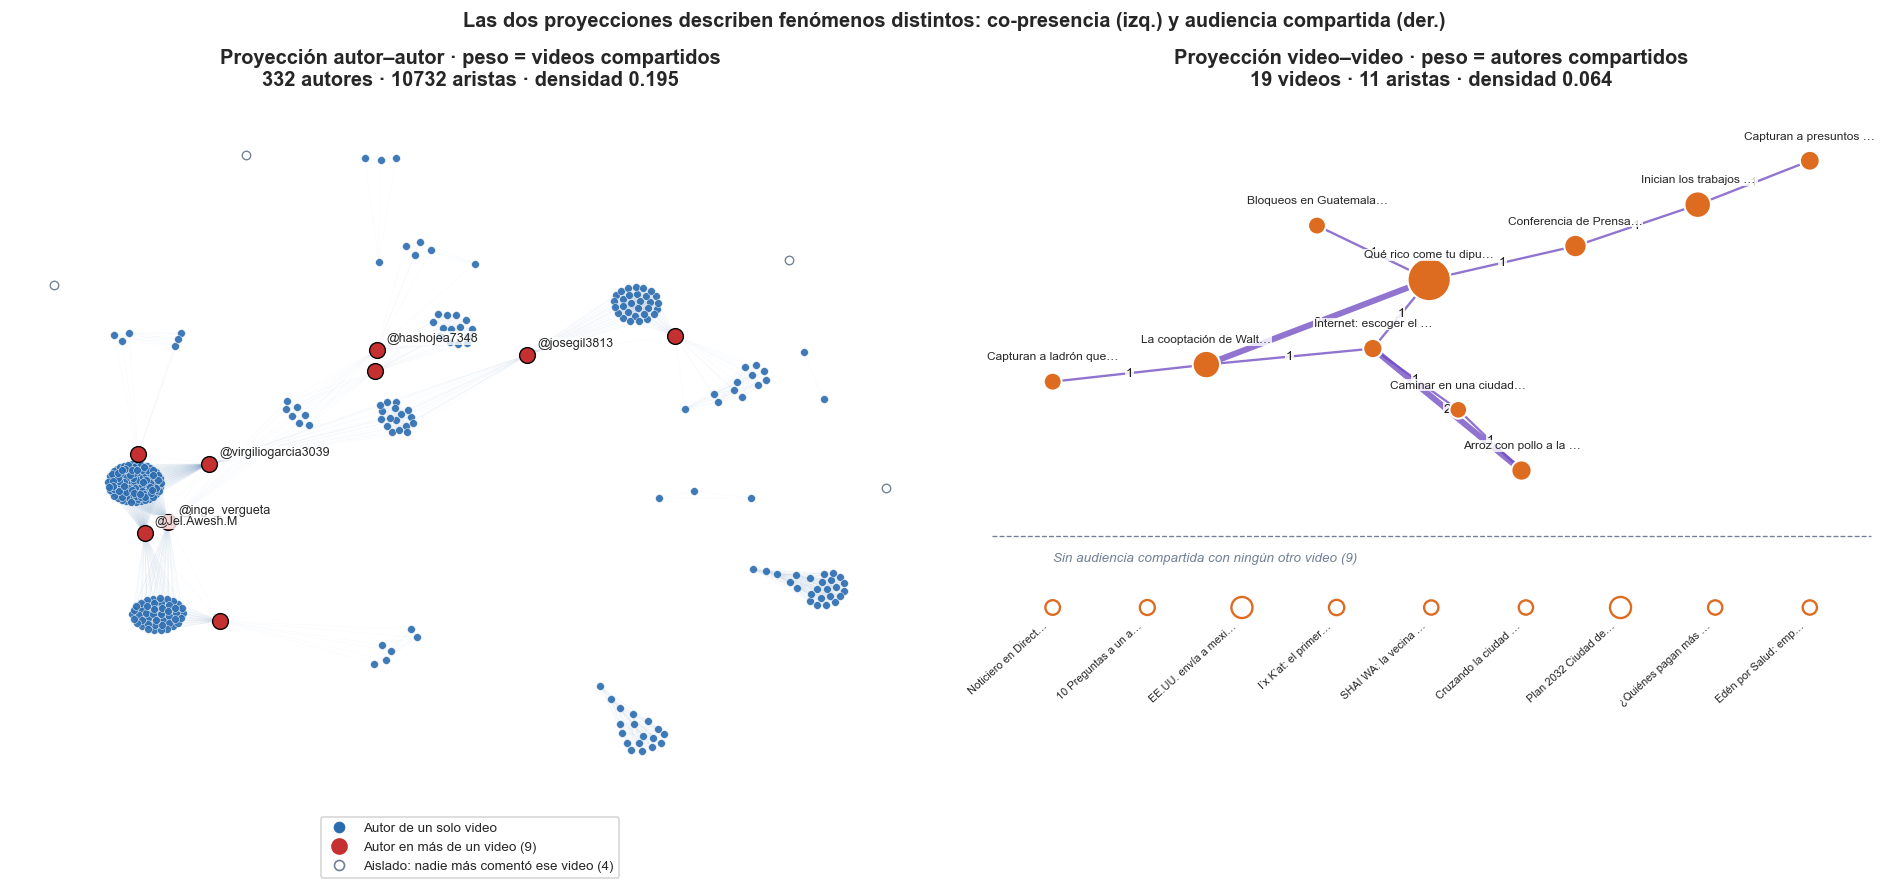

Figura 09 generada.


In [45]:
def disposicion_con_aislados(G: nx.Graph, semilla: int = RANDOM_SEED, k: float = 1.0) -> dict:
    """Coloca la parte conectada con un diseño de fuerzas y alinea los nodos aislados abajo.

    Un spring_layout convencional empuja los nodos aislados hacia los bordes y comprime la parte
    conectada hasta hacerla ilegible; separarlos deja ver la estructura y a la vez conserva
    los nodos aislados, que son un hallazgo y no deben eliminarse.
    """
    aislados = sorted(nx.isolates(G))
    conectados = [n for n in G if n not in set(aislados)]
    posicion = {}
    if conectados:
        sub = G.subgraph(conectados)
        base = nx.kamada_kawai_layout(sub) if sub.number_of_nodes() > 2 else nx.spring_layout(sub, seed=semilla)
        coord = np.array(list(base.values()))
        rango = np.ptp(coord, axis=0)
        rango[rango == 0] = 1
        for nodo, (x, y) in base.items():                       # reescalado a [-1, 1] × [0, 1]
            posicion[nodo] = (2 * (x - coord[:, 0].min()) / rango[0] - 1,
                              (y - coord[:, 1].min()) / rango[1] * 0.95 + 0.30)
    for indice, nodo in enumerate(aislados):
        posicion[nodo] = (-1 + 2 * indice / max(len(aislados) - 1, 1), -0.12)
    return posicion


intermediacion_pa = nx.betweenness_centrality(G_obs, normalized=True, seed=RANDOM_SEED)

fig, ejes = plt.subplots(1, 2, figsize=(16, 7.5))

# --- Proyección autor-autor: cada video se convierte en una camarilla completa ---
pos_pa = nx.spring_layout(P_autores, seed=RANDOM_SEED, k=0.85, iterations=250)
puente_pa = [n for n in P_autores if G_obs.degree(n) > 1]
aislados_pa = list(nx.isolates(P_autores))
nx.draw_networkx_edges(P_autores, pos_pa, ax=ejes[0], edge_color=AZUL, alpha=0.035, width=0.35)
nx.draw_networkx_nodes(P_autores, pos_pa, ax=ejes[0],
                       nodelist=[n for n in P_autores if n not in set(puente_pa) | set(aislados_pa)],
                       node_color=AZUL, node_size=22, alpha=0.9, edgecolors="white", linewidths=0.3)
nx.draw_networkx_nodes(P_autores, pos_pa, nodelist=aislados_pa, ax=ejes[0], node_color="white",
                       edgecolors=GRIS, linewidths=0.8, node_size=26)
nx.draw_networkx_nodes(P_autores, pos_pa, nodelist=puente_pa, ax=ejes[0], node_color=ROJO,
                       node_size=90, edgecolors="black", linewidths=0.8)
for nodo in sorted(puente_pa, key=lambda n: -intermediacion_pa.get(n, 0))[:5]:
    x, y = pos_pa[nodo]
    ejes[0].annotate(acortar(G_obs.nodes[nodo]["etiqueta"], 20), (x, y), fontsize=7.5,
                     xytext=(6, 5), textcoords="offset points",
                     bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=0.5))
ejes[0].set_title(f"Proyección autor–autor · peso = videos compartidos\n"
                  f"{P_autores.number_of_nodes()} autores · {P_autores.number_of_edges()} aristas · "
                  f"densidad {nx.density(P_autores):.3f}")
ejes[0].axis("off")
ejes[0].legend(handles=[
    Line2D([], [], marker="o", ls="", color=AZUL, ms=6, label="Autor de un solo video"),
    Line2D([], [], marker="o", ls="", color=ROJO, ms=9, label=f"Autor en más de un video ({len(puente_pa)})"),
    Line2D([], [], marker="o", ls="", mfc="white", mec=GRIS, ms=6, label=f"Aislado: nadie más comentó ese video ({len(aislados_pa)})"),
], loc="lower center", fontsize=8, bbox_to_anchor=(0.5, -0.10), ncol=1)

# --- Proyección video-video: solapamiento real de audiencias ---
pos_pv = disposicion_con_aislados(P_videos)
aislados_pv = sorted(nx.isolates(P_videos))
conectados_pv = [n for n in P_videos if n not in set(aislados_pv)]
pesos_pv = [P_videos[u][v]["weight"] for u, v in P_videos.edges()]
nx.draw_networkx_edges(P_videos, pos_pv, ax=ejes[1], edge_color=MORADO, alpha=0.75,
                       width=[1.4 + 2.2 * (w - 1) for w in pesos_pv])
nx.draw_networkx_nodes(P_videos, pos_pv, nodelist=conectados_pv, ax=ejes[1], node_color=NARANJA,
                       node_size=[90 + 3.6 * G_obs.nodes[n]["comentarios_recibidos"] for n in conectados_pv],
                       edgecolors="white", linewidths=1.2)
nx.draw_networkx_nodes(P_videos, pos_pv, nodelist=aislados_pv, ax=ejes[1], node_color="white",
                       edgecolors=NARANJA, linewidths=1.4,
                       node_size=[70 + 3.6 * G_obs.nodes[n]["comentarios_recibidos"] for n in aislados_pv])
nx.draw_networkx_edge_labels(P_videos, pos_pv, ax=ejes[1], font_size=8, rotate=False,
                             bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=0.4),
                             edge_labels={(u, v): d["weight"] for u, v, d in P_videos.edges(data=True)})
for nodo in conectados_pv:
    x, y = pos_pv[nodo]
    ejes[1].annotate(acortar(G_obs.nodes[nodo]["etiqueta"], 22), (x, y), fontsize=7.2, ha="center",
                     xytext=(0, 13), textcoords="offset points",
                     bbox=dict(facecolor="white", edgecolor="none", alpha=0.82, pad=0.4))
for nodo in aislados_pv:
    x, y = pos_pv[nodo]
    ejes[1].annotate(acortar(G_obs.nodes[nodo]["etiqueta"], 20), (x, y), fontsize=6.6, rotation=42,
                     ha="right", va="top", xytext=(-2, -8), textcoords="offset points")
ejes[1].axhline(0.10, color=GRIS, ls="--", lw=0.8, xmin=0.02, xmax=0.98)
ejes[1].text(-1.0, 0.02, f"Sin audiencia compartida con ningún otro video ({len(aislados_pv)})",
             fontsize=8, color=GRIS, style="italic")
ejes[1].set_ylim(-0.75, 1.45)
ejes[1].set_title(f"Proyección video–video · peso = autores compartidos\n"
                  f"{P_videos.number_of_nodes()} videos · {P_videos.number_of_edges()} aristas · "
                  f"densidad {nx.density(P_videos):.3f}")
ejes[1].axis("off")

fig.suptitle("Las dos proyecciones describen fenómenos distintos: co-presencia (izq.) y audiencia compartida (der.)",
             fontweight="bold")
fig.tight_layout()
guardar_figura("09_proyecciones")
print("Figura 09 generada.")

## 6. Topología y fragmentación

### 6.1 – 6.2 Métricas estructurales de la red bipartita y de las proyecciones

In [46]:
def metricas_red(G: nx.Graph, nombre: str, bipartita: bool = False) -> dict:
    n, m = G.number_of_nodes(), G.number_of_edges()
    grados = [g for _, g in G.degree()]
    if n == 0:
        return {"red": nombre}
    if bipartita:
        lado_a = {x for x, d in G.nodes(data=True) if d.get("tipo_nodo") == "autor"}
        lado_b = set(G) - lado_a
        densidad = m / (len(lado_a) * len(lado_b)) if lado_a and lado_b else np.nan
    else:
        densidad = nx.density(G)
    componentes = sorted(nx.connected_components(G), key=lambda c: (-len(c), min(c)))
    mayor = G.subgraph(componentes[0]) if componentes else G
    return {
        "red": nombre,
        "nodos": n,
        "aristas": m,
        "densidad": round(float(densidad), 5),
        "grado_medio": round(float(np.mean(grados)), 3),
        "grado_mediano": float(np.median(grados)),
        "grado_max": int(np.max(grados)),
        "grado_min": int(np.min(grados)),
        "componentes": len(componentes),
        "tam_componente_mayor": len(componentes[0]) if componentes else 0,
        "pct_en_componente_mayor": round(100 * len(componentes[0]) / n, 2) if componentes else 0,
        "aislados": int(sum(1 for g in grados if g == 0)),
        "transitividad": round(nx.transitivity(G), 5),
        "clustering_medio": round(nx.average_clustering(G), 5),
        "diametro_componente_mayor": nx.diameter(mayor) if mayor.number_of_nodes() > 1 else 0,
        "camino_medio_componente_mayor": round(nx.average_shortest_path_length(mayor), 3)
        if mayor.number_of_nodes() > 1 else 0,
    }


topologia = pd.DataFrame([
    metricas_red(G_completo, "Bipartita completa (293 videos + 332 autores)", bipartita=True),
    metricas_red(G_obs, "Bipartita observada (19 videos + 332 autores)", bipartita=True),
    metricas_red(P_autores, "Proyección autor–autor"),
    metricas_red(P_videos, "Proyección video–video"),
])
guardar_tabla(topologia, "46_metricas_topologicas")
registrar("topologia", topologia.to_dict("records"))
topologia.T

,0,1,2,3
red,Bipartita completa (293 videos + 332 autores),Bipartita observada (19 videos + 332 autores),Proyección autor–autor,Proyección video–video
nodos,625,351,332,19
aristas,343,343,10732,11
densidad,0.00353,0.05438,0.19532,0.06433
grado_medio,1.098,1.954,64.651,1.158
grado_mediano,1.0,1.0,48.0,1.0
grado_max,128,128,183,4
grado_min,0,1,0,0
componentes,284,10,10,10
tam_componente_mayor,286,286,276,10


**Cohesión y transitividad: por qué el coeficiente clásico vale exactamente 0.**

En una red **bipartita** no pueden existir triángulos: un ciclo cerrado necesita alternar autor y
video, de modo que el ciclo más corto tiene longitud 4. Por eso la transitividad y el *clustering*
clásicos son 0 **por construcción**, no por falta de cohesión. La medida correcta es el
*clustering* bipartito de Latapy, que cuantifica el solapamiento de vecindarios entre nodos del
mismo lado, y el coeficiente de redundancia, que mide qué fracción de los vecinos de un nodo
seguiría conectada si ese nodo desapareciera.

In [47]:
from networkx.algorithms.bipartite import cluster as bcluster

clustering_bip = bcluster.clustering(G_obs, mode="dot")
# La redundancia sólo está definida para nodos con al menos dos vecinos.
nodos_con_dos_vecinos = [n for n in G_obs if G_obs.degree(n) >= 2]
redundancia = nx.bipartite.node_redundancy(G_obs, nodes=nodos_con_dos_vecinos) if nodos_con_dos_vecinos else {}

cohesion = pd.DataFrame([
    ["Transitividad clásica (bipartita observada)", round(nx.transitivity(G_obs), 5),
     "Vale 0 por construcción: una red bipartita no admite triángulos."],
    ["Clustering bipartito de Latapy — autores", round(float(np.mean([clustering_bip[n] for n in AUTORES_OBS])), 5),
     "Solapamiento medio de vecindarios entre autores."],
    ["Clustering bipartito de Latapy — videos", round(float(np.mean([clustering_bip[n] for n in VIDEOS_OBS])), 5),
     "Solapamiento medio de audiencias entre videos."],
    [f"Redundancia media ({len(nodos_con_dos_vecinos)} nodos con grado ≥ 2)",
     round(float(np.mean(list(redundancia.values()))), 5) if redundancia else np.nan,
     "Fracción de pares de vecinos que seguirían conectados por otro camino si el nodo desapareciera."],
    ["Transitividad — proyección autor–autor", round(nx.transitivity(P_autores), 5),
     "Cercana a 1 porque cada video genera una camarilla completa; es un artefacto de la proyección."],
    ["Transitividad — proyección video–video", round(nx.transitivity(P_videos), 5),
     "Baja: los solapamientos de audiencia rara vez cierran triángulos."],
    ["Densidad — bipartita observada", round(G_obs.number_of_edges() / (len(AUTORES_OBS) * len(VIDEOS_OBS)), 5),
     "Se calcula sobre el producto de los dos lados, no sobre n(n-1)/2."],
], columns=["medida", "valor", "interpretación"])
guardar_tabla(cohesion, "47_cohesion_y_transitividad")
registrar("cohesion", cohesion.to_dict("records"))
cohesion

,medida,valor,interpretación
0,Transitividad clásica (bipartita observada),0.00000,Vale 0 por construcción: una red bipartita no admite triángulos.
1,Clustering bipartito de Latapy — autores,0.94227,Solapamiento medio de vecindarios entre autores.
2,Clustering bipartito de Latapy — videos,0.01438,Solapamiento medio de audiencias entre videos.
3,Redundancia media (24 nodos con grado ≥ 2),0.11242,Fracción de pares de vecinos que seguirían conectados por otro camino si el nodo desap...
4,Transitividad — proyección autor–autor,0.98403,Cercana a 1 porque cada video genera una camarilla completa; es un artefacto de la pro...
5,Transitividad — proyección video–video,0.31579,Baja: los solapamientos de audiencia rara vez cierran triángulos.
6,Densidad — bipartita observada,0.05438,"Se calcula sobre el producto de los dos lados, no sobre n(n-1)/2."


### 6.1 Distribución de grados: ¿pocas conexiones o concentradas en unos pocos?

                  lado  nodos  grado_medio  grado_mediano  grado_max  pct_con_grado_1
               Autores    332        1.033            1.0          3             97.3
Videos (con cobertura)     19       18.053            7.0        128             21.1


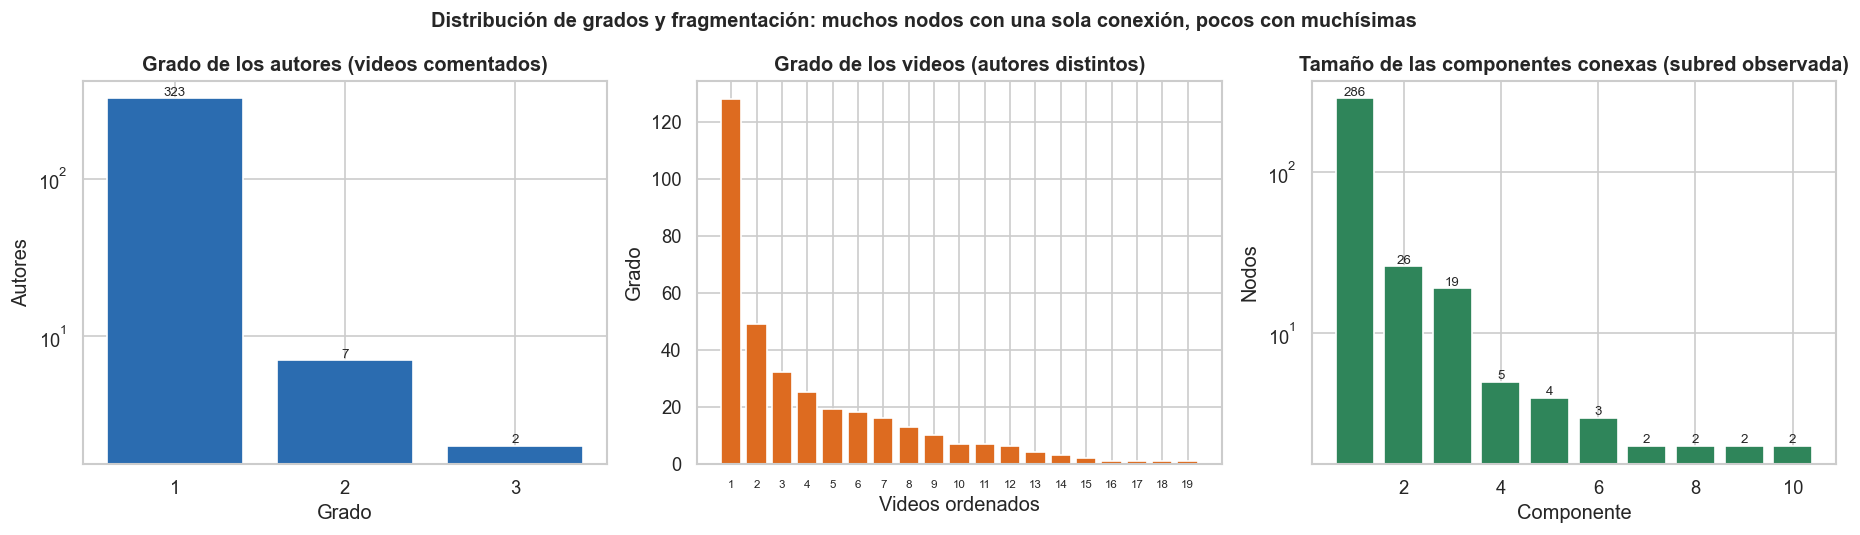

In [48]:
grados_autor = pd.Series([G_obs.degree(n) for n in AUTORES_OBS])
grados_video = pd.Series([G_obs.degree(n) for n in VIDEOS_OBS])
fuerza_autor = pd.Series([G_obs.degree(n, weight="weight") for n in AUTORES_OBS])

distribucion_grados = pd.DataFrame({
    "grado": sorted(set(grados_autor) | set(grados_video)),
}).assign(
    autores=lambda d: d["grado"].map(grados_autor.value_counts()).fillna(0).astype(int),
    videos=lambda d: d["grado"].map(grados_video.value_counts()).fillna(0).astype(int),
)
guardar_tabla(distribucion_grados, "48_distribucion_de_grados")

resumen_grados = pd.DataFrame([
    ["Autores", len(grados_autor), round(grados_autor.mean(), 3), float(grados_autor.median()),
     int(grados_autor.max()), round(100 * (grados_autor == 1).mean(), 1)],
    ["Videos (con cobertura)", len(grados_video), round(grados_video.mean(), 3), float(grados_video.median()),
     int(grados_video.max()), round(100 * (grados_video == 1).mean(), 1)],
], columns=["lado", "nodos", "grado_medio", "grado_mediano", "grado_max", "pct_con_grado_1"])
guardar_tabla(resumen_grados, "49_resumen_grados_por_lado")
registrar("resumen_grados", resumen_grados.to_dict("records"))
registrar("pct_autores_grado1", round(100 * (grados_autor == 1).mean(), 1))
print(resumen_grados.to_string(index=False))

fig, ejes = plt.subplots(1, 3, figsize=(15.5, 4.5))
conteo_a = grados_autor.value_counts().sort_index()
ejes[0].bar(conteo_a.index.astype(str), conteo_a.values, color=AZUL)
ejes[0].set(title="Grado de los autores (videos comentados)", xlabel="Grado", ylabel="Autores")
ejes[0].set_yscale("log")
for x, v in enumerate(conteo_a.values):
    ejes[0].text(x, v, str(v), ha="center", va="bottom", fontsize=8)

ejes[1].bar(range(len(grados_video)), sorted(grados_video, reverse=True), color=NARANJA)
ejes[1].set(title="Grado de los videos (autores distintos)", xlabel="Videos ordenados", ylabel="Grado")
ejes[1].set_xticks(range(len(grados_video)))
ejes[1].set_xticklabels([str(i + 1) for i in range(len(grados_video))], fontsize=7)

tam_componentes = sorted((len(c) for c in nx.connected_components(G_obs)), reverse=True)
ejes[2].bar(range(1, len(tam_componentes) + 1), tam_componentes, color=VERDE)
ejes[2].set(title="Tamaño de las componentes conexas (subred observada)",
            xlabel="Componente", ylabel="Nodos")
ejes[2].set_yscale("log")
for x, v in enumerate(tam_componentes, start=1):
    ejes[2].text(x, v, str(v), ha="center", va="bottom", fontsize=8)
fig.suptitle("Distribución de grados y fragmentación: muchos nodos con una sola conexión, "
             "pocos con muchísimas", fontweight="bold")
fig.tight_layout()
guardar_figura("10_distribucion_grados_componentes")

### 6.3 Nodos periféricos y aislados: aislamiento observado vs ausencia de datos

In [49]:
componentes_obs = sorted(nx.connected_components(G_obs), key=lambda c: (-len(c), min(c)))
componente_de = {n: i + 1 for i, c in enumerate(componentes_obs) for n in c}

tabla_componentes = pd.DataFrame([{
    "componente": i + 1,
    "nodos": len(c),
    "autores": sum(1 for n in c if G_obs.nodes[n]["tipo_nodo"] == "autor"),
    "videos": sum(1 for n in c if G_obs.nodes[n]["tipo_nodo"] == "video"),
    "comentarios": int(sum(d["weight"] for u, v, d in G_obs.edges(c, data=True))),
    "titulos": " | ".join(sorted(acortar(G_obs.nodes[n]["etiqueta"], 34)
                                 for n in c if G_obs.nodes[n]["tipo_nodo"] == "video")),
} for i, c in enumerate(componentes_obs)])
guardar_tabla(tabla_componentes, "50_componentes_conexas")
registrar("componentes", tabla_componentes.to_dict("records"))
print(tabla_componentes[["componente", "nodos", "autores", "videos", "comentarios"]].to_string(index=False))

 componente  nodos  autores  videos  comentarios
          1    286      276      10          343
          2     26       25       1           25
          3     19       18       1           25
          4      5        4       1            4
          5      4        3       1            3
          6      3        2       1            2
          7      2        1       1            1
          8      2        1       1            1
          9      2        1       1            1
         10      2        1       1            1


In [50]:
videos_sin_cobertura = nodos[(nodos["tipo_nodo"] == "video") & (~nodos["observado"])]
periferia = pd.DataFrame([
    ["Videos sin ninguna arista", len(videos_sin_cobertura),
     "AUSENCIA DE DATOS. No se recolectaron comentarios para ellos; no puede afirmarse que nadie comentó."],
    ["Videos con cobertura y grado 1", int((grados_video == 1).sum()),
     "AISLAMIENTO OBSERVADO PARCIAL. Recibieron un solo comentarista dentro de la muestra."],
    ["Autores con grado 1 (un solo video)", int((grados_autor == 1).sum()),
     "PERIFERIA OBSERVADA. Participación de una sola vez en la muestra; pueden ser activos fuera de ella."],
    ["Autores con grado ≥ 2", int((grados_autor >= 2).sum()),
     "NÚCLEO CONECTOR. Son los únicos nodos capaces de unir videos distintos."],
    ["Autores aislados en la proyección autor–autor", len(list(nx.isolates(P_autores))),
     "Comentaron en un video donde nadie más de la muestra comentó."],
    ["Videos aislados en la proyección video–video", len(list(nx.isolates(P_videos))),
     "No comparten ningún comentarista con otro video de la muestra."],
    ["Componentes conexas de la subred observada", len(componentes_obs),
     f"La mayor reúne {len(componentes_obs[0])} nodos ({round(100 * len(componentes_obs[0]) / G_obs.number_of_nodes(), 1)} % de la subred)."],
], columns=["grupo", "conteo", "lectura"])
guardar_tabla(periferia, "51_periferia_y_aislamiento")
registrar("periferia", periferia.to_dict("records"))
registrar("videos_sin_cobertura_n", len(videos_sin_cobertura))
registrar("n_componentes_obs", len(componentes_obs))
registrar("tam_componente_mayor", len(componentes_obs[0]))
registrar("pct_componente_mayor", round(100 * len(componentes_obs[0]) / G_obs.number_of_nodes(), 1))
periferia

,grupo,conteo,lectura
0,Videos sin ninguna arista,274,AUSENCIA DE DATOS. No se recolectaron comentarios para ellos; no puede afirmarse que n...
1,Videos con cobertura y grado 1,4,AISLAMIENTO OBSERVADO PARCIAL. Recibieron un solo comentarista dentro de la muestra.
2,Autores con grado 1 (un solo video),323,PERIFERIA OBSERVADA. Participación de una sola vez en la muestra; pueden ser activos f...
3,Autores con grado ≥ 2,9,NÚCLEO CONECTOR. Son los únicos nodos capaces de unir videos distintos.
4,Autores aislados en la proyección autor–autor,4,Comentaron en un video donde nadie más de la muestra comentó.
5,Videos aislados en la proyección video–video,9,No comparten ningún comentarista con otro video de la muestra.
6,Componentes conexas de la subred observada,10,La mayor reúne 286 nodos (81.5 % de la subred).


## 7. Comunidades

### 7.1 Selección de la red y justificación

Se detectan comunidades sobre la **red bipartita observada** (351 nodos, 343 aristas), no sobre la
proyección autor–autor. Razones:

1. La proyección **inventa** 10 732 aristas a partir de 343 observaciones. Cualquier comunidad
   detectada allí reflejaría el artefacto de las camarillas, no la estructura de participación.
2. La red bipartita conserva la unidad de observación real: *quién comentó dónde*. Una comunidad
   resulta ser un grupo de autores agrupados alrededor de uno o varios videos, que es exactamente
   el objeto de interés.
3. Al mantener autores y videos como nodos, cada comunidad es **interpretable**: puede describirse
   por sus videos, su canal, sus temas y su sentimiento.

Los **videos sin cobertura se excluyen** de la detección: son nodos de grado 0 y cada uno formaría
una comunidad trivial de tamaño 1, inflando artificialmente el número de comunidades. Se
contabilizan aparte como ausencia de datos.

### 7.2 Algoritmo, supuestos y tratamiento de los pesos

**Algoritmo: Louvain con pesos** (`python-louvain`, semilla fija 42).

- *Supuesto de modularidad*: una comunidad es un conjunto de nodos con más aristas internas de las
  que cabría esperar en un grafo aleatorio con la misma distribución de grados (modelo nulo de
  configuración).
- *Tratamiento de los pesos*: el peso de la arista es el número de comentarios del autor en ese
  video, de modo que un autor que comentó seis veces pesa más que uno que comentó una vez. Se
  reporta también la partición **sin pesos** para verificar que el resultado no depende de esa
  decisión.
- *Limitación conocida*: la modularidad clásica no está diseñada para redes bipartitas — el modelo
  nulo permite aristas autor–autor que aquí son imposibles, lo que **sobreestima** la modularidad.
  Por eso el valor se interpreta de forma comparativa, no como una medida absoluta de calidad, y se
  contrasta con dos algoritmos alternativos. La alternativa formal sería la modularidad bipartita
  de Barber; el resultado no cambiaría cualitativamente porque cada componente conexa ya separa
  grupos casi disjuntos.
- *Resolución límite*: Louvain no detecta comunidades más pequeñas que √(2m); con m = 343 el umbral
  es ≈ 26 nodos, lo que explica que las componentes pequeñas queden como comunidades completas.

In [51]:
import community as community_louvain

particion_pesada = community_louvain.best_partition(G_obs, weight="weight", random_state=RANDOM_SEED)
G_obs_unitaria = G_obs.copy()                       # misma estructura, todos los pesos en 1
nx.set_edge_attributes(G_obs_unitaria, 1, "weight")
particion_sin_peso = community_louvain.best_partition(
    G_obs_unitaria, weight="weight", random_state=RANDOM_SEED)

def a_conjuntos(particion: dict) -> list[set]:
    """Agrupa la partición y la ordena por tamaño, desempatando por el nodo menor.

    El desempate evita que dos comunidades del mismo tamaño intercambien su número entre
    ejecuciones, lo que cambiaría las etiquetas C1…C17 de las tablas y figuras.
    """
    grupos: dict[int, set] = {}
    for nodo, comunidad in particion.items():
        grupos.setdefault(comunidad, set()).add(nodo)
    return sorted(grupos.values(), key=lambda c: (-len(c), min(c)))


comunidades = a_conjuntos(particion_pesada)
mod_pesada = nx.community.modularity(G_obs, comunidades, weight="weight")
mod_sin_peso = nx.community.modularity(G_obs, a_conjuntos(particion_sin_peso), weight=None)

# Robustez: dos algoritmos alternativos sobre la misma red.
com_nx = list(nx.community.louvain_communities(G_obs, weight="weight", seed=RANDOM_SEED))
com_greedy = list(nx.community.greedy_modularity_communities(G_obs, weight="weight"))
com_etiquetas = list(nx.community.asyn_lpa_communities(G_obs, weight="weight", seed=RANDOM_SEED))

comparacion_algoritmos = pd.DataFrame([
    ["Louvain con pesos (python-louvain)", len(comunidades), round(mod_pesada, 4),
     max(len(c) for c in comunidades)],
    ["Louvain sin pesos (python-louvain)", len(a_conjuntos(particion_sin_peso)), round(mod_sin_peso, 4),
     max(len(c) for c in a_conjuntos(particion_sin_peso))],
    ["Louvain (networkx)", len(com_nx), round(nx.community.modularity(G_obs, com_nx, weight="weight"), 4),
     max(len(c) for c in com_nx)],
    ["Modularidad voraz (CNM)", len(com_greedy),
     round(nx.community.modularity(G_obs, com_greedy, weight="weight"), 4), max(len(c) for c in com_greedy)],
    ["Propagación de etiquetas", len(list(com_etiquetas)),
     round(nx.community.modularity(G_obs, com_etiquetas, weight="weight"), 4),
     max(len(c) for c in com_etiquetas)],
], columns=["algoritmo", "comunidades", "modularidad", "tamaño_mayor"])
guardar_tabla(comparacion_algoritmos, "52_comparacion_algoritmos_comunidades")
registrar("comparacion_algoritmos", comparacion_algoritmos.to_dict("records"))
registrar("modularidad", round(mod_pesada, 4))
registrar("n_comunidades", len(comunidades))
comparacion_algoritmos

,algoritmo,comunidades,modularidad,tamaño_mayor
0,Louvain con pesos (python-louvain),17,0.7774,126
1,Louvain sin pesos (python-louvain),17,0.7901,125
2,Louvain (networkx),17,0.7774,126
3,Modularidad voraz (CNM),17,0.7774,126
4,Propagación de etiquetas,19,0.7712,127


### 7.3 – 7.5 Número, tamaño, calidad y caracterización de las comunidades

In [52]:
nodo_a_comunidad = {n: i + 1 for i, c in enumerate(comunidades) for n in c}
nx.set_node_attributes(G_obs, nodo_a_comunidad, "comunidad")
comentarios["comunidad"] = comentarios["video_id"].map(
    lambda v: nodo_a_comunidad.get(f"video::{v}", np.nan))

filas_comunidad = []
for indice, miembros in enumerate(comunidades, start=1):
    autores_c = sorted(n for n in miembros if G_obs.nodes[n]["tipo_nodo"] == "autor")
    videos_c = sorted((n for n in miembros if G_obs.nodes[n]["tipo_nodo"] == "video"),
                      key=lambda n: (-G_obs.degree(n), n))
    ids_video = [n.split("::", 1)[1] for n in videos_c]
    sub_com = comentarios[comentarios["video_id"].isin(ids_video)]
    terminos = Counter(t for texto in sub_com["texto_limpio"] for t in str(texto).split())
    filas_comunidad.append({
        "comunidad": indice,
        "nodos": len(miembros),
        "autores": len(autores_c),
        "videos": len(videos_c),
        "comentarios": int(len(sub_com)),
        "intensidad_comentarios_por_autor": round(len(sub_com) / max(len(autores_c), 1), 2),
        "canales": " | ".join(sorted(sub_com["channel_name"].unique())),
        "categorias": " | ".join(sorted(videos.loc[videos["video_id"].isin(ids_video), "category"].unique())),
        "likes_totales": int(sub_com["like_count"].sum()),
        "respuestas_totales": int(sub_com["reply_count"].sum()),
        "sent_medio": round(float(sub_com["puntaje_sentimiento"].mean()), 3) if len(sub_com) else np.nan,
        "pct_negativos": round(100 * (sub_com["sentimiento"] == "NEG").mean(), 1) if len(sub_com) else np.nan,
        "pct_positivos": round(100 * (sub_com["sentimiento"] == "POS").mean(), 1) if len(sub_com) else np.nan,
        "temas_frecuentes": ", ".join(t for t, _ in terminos.most_common(8)),
        "videos_titulos": " | ".join(acortar(G_obs.nodes[n]["etiqueta"], 40) for n in videos_c),
    })

perfil_comunidades = pd.DataFrame(filas_comunidad)
guardar_tabla(perfil_comunidades, "53_perfil_de_comunidades")
registrar("perfil_comunidades", perfil_comunidades.to_dict("records"))
print(perfil_comunidades[["comunidad", "nodos", "autores", "videos", "comentarios",
                          "sent_medio", "pct_negativos"]].to_string(index=False))

 comunidad  nodos  autores  videos  comentarios  sent_medio  pct_negativos
         1    126      125       1          161      -0.671           80.7
         2     48       47       1           50      -0.342           58.0
         3     32       29       3           34      -0.209           50.0
         4     31       30       1           45      -0.109           40.0
         5     26       25       1           25       0.609            8.0
         6     19       18       1           25      -0.473           64.0
         7     19       18       1           25      -0.422           68.0
         8     14       13       1           14      -0.177           28.6
         9      8        7       1            7      -0.759           85.7
        10      8        7       1            7      -0.622           85.7
        11      5        4       1            4       0.467           25.0
        12      4        3       1            3       0.157           33.3
        13      3        

In [53]:
# Comunidades sobre la proyección video–video: ¿el agrupamiento temático coincide?
com_videos = list(nx.community.louvain_communities(P_videos, weight="weight", seed=RANDOM_SEED))
mapa_videos = {n: i + 1 for i, c in enumerate(sorted(com_videos, key=len, reverse=True)) for n in c}
robustez_video = pd.DataFrame([{
    "video": acortar(G_obs.nodes[n]["etiqueta"], 48),
    "comunidad_bipartita": nodo_a_comunidad[n],
    "comunidad_proyeccion": mapa_videos[n],
    "canal": G_obs.nodes[n]["channel_name"],
    "comentarios": G_obs.nodes[n]["comentarios_recibidos"],
} for n in VIDEOS_OBS]).sort_values(["comunidad_bipartita", "comentarios"], ascending=[True, False])
guardar_tabla(robustez_video, "54_comunidades_por_video")
registrar("robustez_video", robustez_video.to_dict("records"))
print(robustez_video.to_string(index=False))

                                           video  comunidad_bipartita  comunidad_proyeccion                                 canal  comentarios
                       Qué rico come tu diputado                    1                     1                                Quorum        161.0
   La cooptación de Walter Mazariegos en la USAC                    2                     1                                Quorum         50.0
                  Arroz con pollo a la MONOPOLIO                    3                     3                                Quorum         16.0
                 Internet: escoger el menos malo                    3                     3                                Quorum         12.0
         Caminar en una ciudad hecha para carros                    3                     3                                Quorum          6.0
Inician los trabajos de recuperación del Puente…                    4                     2 Gobierno de la República de Guatemala         45.0

### 7.4 Visualización de todas las comunidades

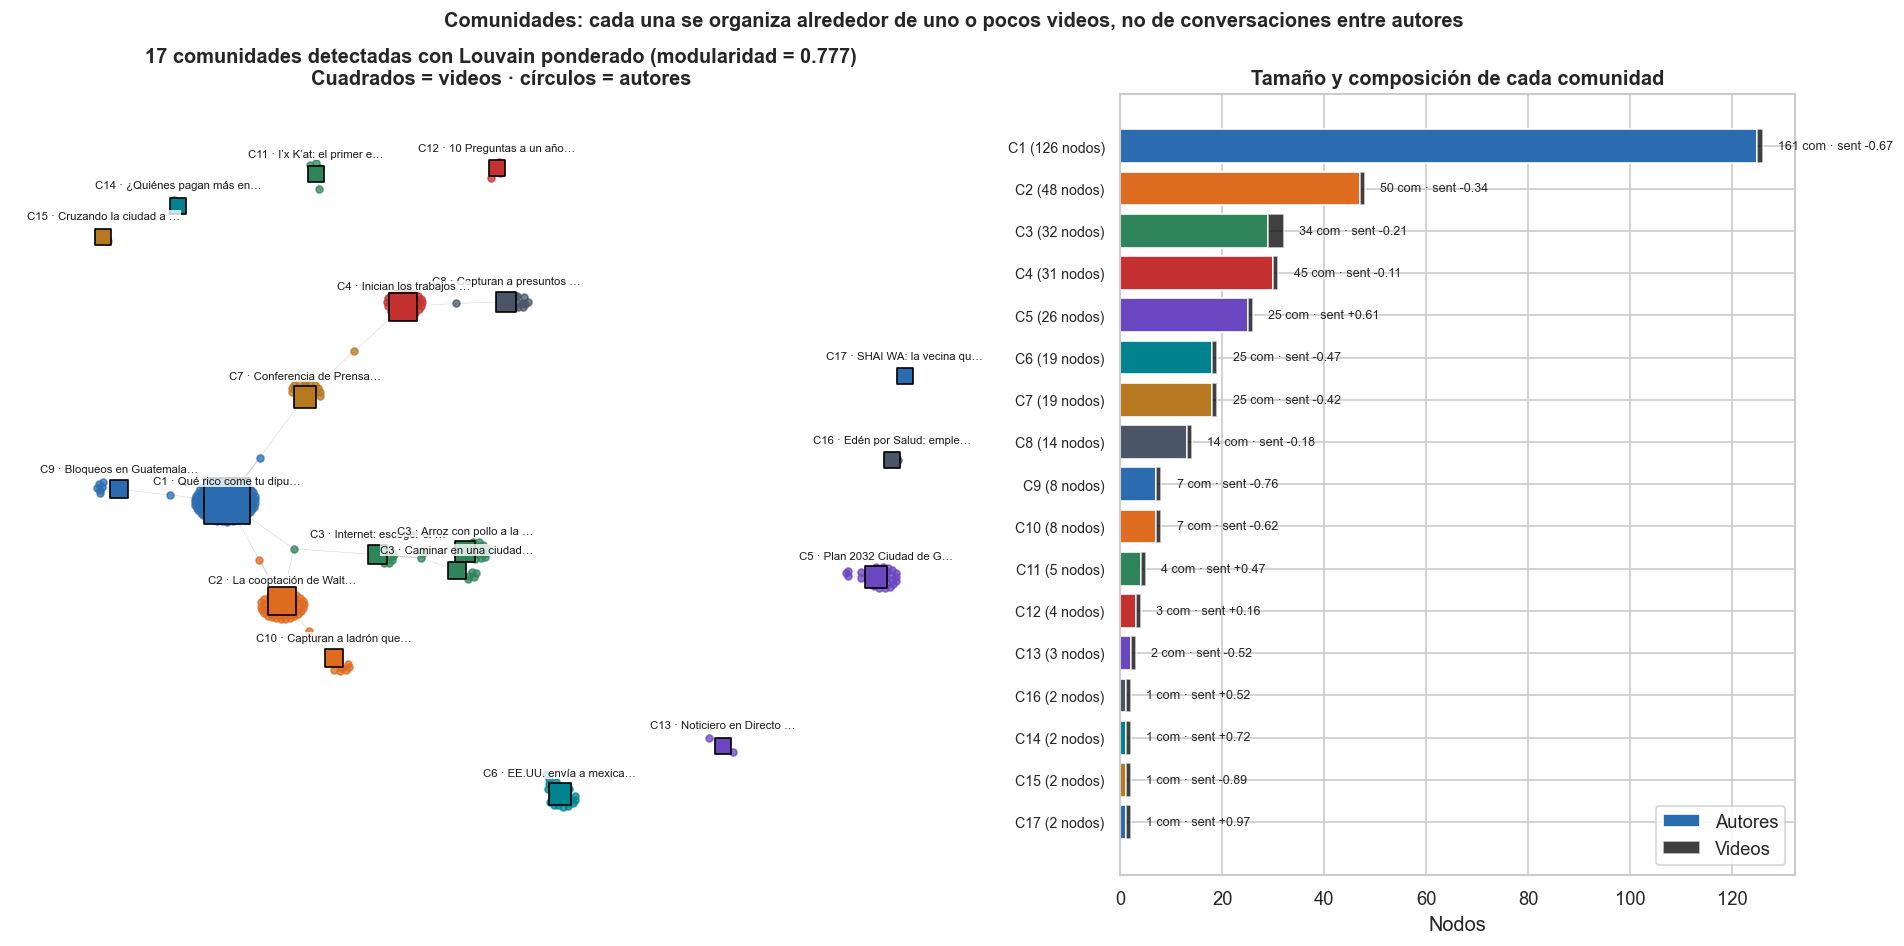

Figura 11 generada.


In [54]:
paleta_com = (PALETA * (len(comunidades) // len(PALETA) + 1))[:len(comunidades)]
fig, ejes = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={"width_ratios": [1.45, 1]})

pos_com = nx.spring_layout(G_obs, seed=RANDOM_SEED, k=0.32, iterations=500, weight="weight")
nx.draw_networkx_edges(G_obs, pos_com, ax=ejes[0], edge_color=GRIS, alpha=0.35,
                       width=[0.3 + 0.5 * (G_obs[u][v]["weight"] - 1) for u, v in G_obs.edges()])
for indice, miembros in enumerate(comunidades, start=1):
    color = paleta_com[indice - 1]
    autores_c = sorted(n for n in miembros if G_obs.nodes[n]["tipo_nodo"] == "autor")
    videos_c = sorted(n for n in miembros if G_obs.nodes[n]["tipo_nodo"] == "video")
    nx.draw_networkx_nodes(G_obs, pos_com, nodelist=autores_c, ax=ejes[0], node_color=color,
                           node_size=17, alpha=0.75)
    nx.draw_networkx_nodes(G_obs, pos_com, nodelist=videos_c, ax=ejes[0], node_color=color,
                           node_size=[80 + 4.2 * G_obs.nodes[n]["comentarios_recibidos"] for n in videos_c],
                           edgecolors="black", linewidths=1.0, node_shape="s")
etq = nx.draw_networkx_labels(
    G_obs, {n: (x, y + 0.055) for n, (x, y) in pos_com.items()}, ax=ejes[0], font_size=6.8,
    labels={n: f"C{nodo_a_comunidad[n]} · {acortar(G_obs.nodes[n]['etiqueta'], 22)}" for n in VIDEOS_OBS})
for t in etq.values():
    t.set_bbox(dict(facecolor="white", edgecolor="none", alpha=0.8, pad=0.5))
ejes[0].set_title(f"{len(comunidades)} comunidades detectadas con Louvain ponderado "
                  f"(modularidad = {mod_pesada:.3f})\nCuadrados = videos · círculos = autores")
ejes[0].axis("off")

orden = perfil_comunidades.sort_values("nodos")
posiciones = np.arange(len(orden))
ejes[1].barh(posiciones, orden["autores"], color=[paleta_com[c - 1] for c in orden["comunidad"]], label="Autores")
ejes[1].barh(posiciones, orden["videos"], left=orden["autores"], color="black", alpha=0.75, label="Videos")
ejes[1].set_yticks(posiciones)
ejes[1].set_yticklabels([f"C{c} ({n} nodos)" for c, n in zip(orden["comunidad"], orden["nodos"])], fontsize=8.5)
ejes[1].set(title="Tamaño y composición de cada comunidad", xlabel="Nodos")
ejes[1].legend(loc="lower right")
for y, (com, com_n, sent) in enumerate(zip(orden["comunidad"], orden["comentarios"], orden["sent_medio"])):
    ejes[1].text(orden["nodos"].iloc[y] + 3, y, f"{com_n} com · sent {sent:+.2f}", va="center", fontsize=7.5)
fig.suptitle("Comunidades: cada una se organiza alrededor de uno o pocos videos, no de conversaciones entre autores",
             fontweight="bold")
fig.tight_layout()
guardar_figura("11_comunidades")
print("Figura 11 generada.")

## 8. Nodos centrales y participantes puente

### 8.1 Medidas de centralidad y justificación de su uso

| Medida | Qué mide aquí | Por qué se usa |
|---|---|---|
| Grado bipartito | Videos comentados (autor) / comentaristas distintos (video) | Es la medida directa de alcance; se normaliza por el tamaño del **lado opuesto**, no por *n*, porque un autor sólo puede conectarse con videos. |
| Fuerza (grado ponderado) | Número total de comentarios del nodo | Distingue *amplitud* (muchos videos) de *intensidad* (muchos comentarios en uno). |
| Intermediación | Cuántos caminos más cortos pasan por el nodo | Es **la** medida de participante puente: identifica a quien conecta audiencias separadas. |
| Cercanía | Distancia media al resto de la componente | Indica qué tan integrado está un nodo; se calcula por componente (la red está fragmentada). |
| Vector propio | Conexión con nodos a su vez muy conectados | Mide estar en la zona densa de la red; en redes bipartitas se interpreta con cautela. |
| PageRank | Probabilidad estacionaria de un paseo aleatorio | Robusto ante fragmentación gracias al factor de amortiguación; útil para rankear videos. |

La **intermediación no se calcula sobre la proyección autor–autor**: dentro de una camarilla todos
los caminos tienen longitud 1 y la intermediación colapsa a 0 salvo para los pocos autores que
unen camarillas, lo que exagera su importancia.

In [55]:
grado_bip = nx.bipartite.degree_centrality(G_obs, AUTORES_OBS)
intermediacion = nx.betweenness_centrality(G_obs, weight=None, normalized=True, seed=RANDOM_SEED)
cercania = nx.closeness_centrality(G_obs)
pagerank = nx.pagerank(G_obs, weight="weight", alpha=0.85)
try:
    vector_propio = nx.eigenvector_centrality_numpy(G_obs, weight="weight")
except Exception:
    vector_propio = nx.eigenvector_centrality(G_obs, weight="weight", max_iter=2000, tol=1e-6)

centralidad = pd.DataFrame([{
    "node_id": n,
    "tipo_nodo": G_obs.nodes[n]["tipo_nodo"],
    "etiqueta": G_obs.nodes[n]["etiqueta"],
    "comunidad": nodo_a_comunidad[n],
    "componente": componente_de[n],
    "grado": G_obs.degree(n),
    "fuerza": G_obs.degree(n, weight="weight"),
    "grado_bipartito": round(grado_bip[n], 4),
    "intermediacion": round(intermediacion[n], 5),
    "cercania": round(cercania[n], 4),
    "pagerank": round(pagerank[n], 5),
    "vector_propio": round(vector_propio[n], 5),
} for n in G_obs.nodes])
centralidad = centralidad.merge(
    nodos[["node_id", "channel_name", "category", "view_count", "comentarios_recibidos", "sent_medio"]],
    on="node_id", how="left")
guardar_tabla(centralidad.sort_values("pagerank", ascending=False), "55_centralidad_todos_los_nodos")

,node_id,tipo_nodo,etiqueta,comunidad,componente,grado,fuerza,grado_bipartito,intermediacion,cercania,pagerank,vector_propio,channel_name,category,view_count,comentarios_recibidos,sent_medio
346,video::n8iP75gIpmw,video,Qué rico come tu diputado,1,1,128,161,0.3855,0.56570,0.3046,0.16729,0.70700,Quorum,News & Politics,11775,161.0,-0.670855
344,video::j43HgwYFKfk,video,La cooptación de Walter Mazariegos en la USAC,2,1,49,50,0.1476,0.22747,0.2214,0.06319,0.01046,Quorum,News & Politics,10156,50.0,-0.342152
334,video::6W4u8sGEnGM,video,Inician los trabajos de recuperación del Puente Belice II.,4,1,32,45,0.0964,0.18762,0.1583,0.04259,0.00004,Gobierno de la República de Guatemala,Entertainment,11670,45.0,-0.108582
345,video::lj983NWyAQY,video,Plan 2032 Ciudad de Guatemala,5,2,25,25,0.0753,0.00491,0.0714,0.03427,0.00000,Municipalidad de Guatemala,News & Politics,304089,25.0,0.609418
336,video::OkXlHx0hx-8,video,EE.UU. envía a mexicanos deportados a Guatemala antes de su…,6,3,18,25,0.0542,0.00251,0.0514,0.02511,0.00000,Noticias Telemundo,News & Politics,14200,25.0,-0.473098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,author::UChyps3dqY-VY1_wLeq-2lhw,autor,@maydamorales4395,4,1,1,1,0.0526,0.00000,0.1326,0.00123,0.00000,NaN,NaN,<NA>,NaN,0.217000
245,author::UCiOZX__1gahg1ypIj0_XG_w,autor,@mariogonzalezorellana8956,4,1,1,1,0.0526,0.00000,0.1326,0.00123,0.00000,NaN,NaN,<NA>,NaN,0.081000
280,author::UCql1n3Ey6ULMSOACjMe-fxQ,autor,@RolandoGonzalez-o7g,4,1,1,1,0.0526,0.00000,0.1326,0.00123,0.00000,NaN,NaN,<NA>,NaN,-0.960000
297,author::UCtsxPYw8VUsH_FfnKg-0lmw,autor,@AlejandroPérez-b6r,4,1,1,1,0.0526,0.00000,0.1326,0.00123,0.00000,NaN,NaN,<NA>,NaN,-0.405000


### 8.2 Interpretación separada: autores

In [56]:
centralidad_autores = centralidad.query("tipo_nodo == 'autor'").copy()
centralidad_autores["recurrencia"] = centralidad_autores["fuerza"]        # comentarios totales
centralidad_autores["diversidad"] = centralidad_autores["grado"]          # videos distintos
top_autores = centralidad_autores.sort_values(
    ["intermediacion", "diversidad", "recurrencia"], ascending=False).head(15)
guardar_tabla(top_autores[["etiqueta", "comunidad", "componente", "diversidad", "recurrencia",
                           "intermediacion", "cercania", "pagerank", "vector_propio", "sent_medio"]],
              "56_centralidad_autores")
registrar("top_autores", top_autores.head(10)[
    ["etiqueta", "diversidad", "recurrencia", "intermediacion", "pagerank", "sent_medio"]].to_dict("records"))
print(top_autores[["etiqueta", "diversidad", "recurrencia", "intermediacion", "cercania", "pagerank"]]
      .to_string(index=False))

                  etiqueta  diversidad  recurrencia  intermediacion  cercania  pagerank
       @virgiliogarcia3039           2            3         0.23158    0.2528   0.00304
            @inge_vergueta           3            3         0.21808    0.2655   0.00332
              @josegil3813           2            2         0.17683    0.1827   0.00208
              @Jel.Awesh.M           2            3         0.08915    0.2479   0.00346
             @hashojea7348           3            4         0.05971    0.1732   0.00454
      @franciscoflores3120           2            2         0.05790    0.1346   0.00229
           @Alejandro00710           2            2         0.03230    0.1717   0.00245
        @MarcosCarillo-b1r           2            2         0.03186    0.1761   0.00270
         @moisesvaldez4043           2            2         0.03186    0.2249   0.00248
        @eugeneramirez4405           1            6         0.00000    0.0264   0.00555
        @Murmullodelbarrio      

### 8.2 Interpretación separada: videos

In [57]:
centralidad_videos = centralidad.query("tipo_nodo == 'video'").copy()
top_videos_red = centralidad_videos.sort_values("pagerank", ascending=False)
guardar_tabla(top_videos_red[["etiqueta", "channel_name", "category", "comunidad", "componente",
                              "grado", "fuerza", "intermediacion", "cercania", "pagerank",
                              "vector_propio", "view_count", "sent_medio"]],
              "57_centralidad_videos")
registrar("top_videos_red", top_videos_red.head(10)[
    ["etiqueta", "channel_name", "grado", "fuerza", "intermediacion", "pagerank"]].to_dict("records"))
print(top_videos_red[["etiqueta", "channel_name", "grado", "fuerza", "intermediacion", "pagerank"]]
      .head(12).to_string(index=False))

                                                    etiqueta                          channel_name  grado  fuerza  intermediacion  pagerank
                                   Qué rico come tu diputado                                Quorum    128     161         0.56570   0.16729
               La cooptación de Walter Mazariegos en la USAC                                Quorum     49      50         0.22747   0.06319
  Inician los trabajos de recuperación del Puente Belice II. Gobierno de la República de Guatemala     32      45         0.18762   0.04259
                               Plan 2032 Ciudad de Guatemala            Municipalidad de Guatemala     25      25         0.00491   0.03427
EE.UU. envía a mexicanos deportados a Guatemala antes de su…                    Noticias Telemundo     18      25         0.00251   0.02511
 Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt Gobierno de la República de Guatemala     19      25         0.24403   0.02490
                    

### 8.3 Participantes recurrentes, autores puente y videos articuladores

Un nodo es **articulador** si eliminarlo desconecta su componente. Es la prueba estructural directa
que pide el enunciado: «si lo elimináramos de la red, ésta se segmenta».

In [58]:
articulacion = set(nx.articulation_points(G_obs))
autores_articuladores = sorted(n for n in articulacion if G_obs.nodes[n]["tipo_nodo"] == "autor")
videos_articuladores = sorted(n for n in articulacion if G_obs.nodes[n]["tipo_nodo"] == "video")


def fragmentos_al_quitar(nodo: str) -> tuple[int, int]:
    """Componentes antes y después de eliminar el nodo."""
    antes = nx.number_connected_components(G_obs)
    copia = G_obs.copy()
    copia.remove_node(nodo)
    return antes, nx.number_connected_components(copia)


puentes = pd.DataFrame([{
    "autor": G_obs.nodes[n]["etiqueta"],
    "videos_comentados": G_obs.degree(n),
    "comentarios": G_obs.degree(n, weight="weight"),
    "intermediacion": round(intermediacion[n], 5),
    "comunidad": nodo_a_comunidad[n],
    "componentes_antes": fragmentos_al_quitar(n)[0],
    "componentes_despues": fragmentos_al_quitar(n)[1],
    "videos_que_conecta": " | ".join(sorted(acortar(G_obs.nodes[v]["etiqueta"], 34) for v in G_obs[n])),
} for n in autores_articuladores]).sort_values("intermediacion", ascending=False)
guardar_tabla(puentes, "58_autores_puente_articuladores")
registrar("puentes", puentes.to_dict("records"))
registrar("n_autores_puente", len(puentes))

articuladores_video = pd.DataFrame([{
    "video": G_obs.nodes[n]["etiqueta"],
    "canal": G_obs.nodes[n]["channel_name"],
    "comentaristas": G_obs.degree(n),
    "intermediacion": round(intermediacion[n], 5),
    "componentes_antes": fragmentos_al_quitar(n)[0],
    "componentes_despues": fragmentos_al_quitar(n)[1],
} for n in videos_articuladores]).sort_values("intermediacion", ascending=False)
guardar_tabla(articuladores_video, "59_videos_articuladores")
registrar("articuladores_video", articuladores_video.to_dict("records"))
registrar("n_videos_articuladores", len(articuladores_video))
print(puentes.to_string(index=False))
print()
print(articuladores_video.to_string(index=False))

               autor  videos_comentados  comentarios  intermediacion  comunidad  componentes_antes  componentes_despues                                                                                    videos_que_conecta
 @virgiliogarcia3039                  2            3         0.23158          1                 10                   11                                        Conferencia de Prensa del Gobiern… | Qué rico come tu diputado
      @inge_vergueta                  3            3         0.21808          3                 10                   11      Internet: escoger el menos malo | La cooptación de Walter Mazariego… | Qué rico come tu diputado
        @josegil3813                  2            2         0.17683          7                 10                   11                               Conferencia de Prensa del Gobiern… | Inician los trabajos de recuperac…
       @hashojea7348                  3            4         0.05971          3                 10              

In [59]:
# Participantes recurrentes: los que vuelven, con o sin efecto puente.
recurrentes = centralidad_autores.query("recurrencia > 1").sort_values(
    ["recurrencia", "diversidad"], ascending=False)
guardar_tabla(recurrentes[["etiqueta", "comunidad", "diversidad", "recurrencia", "intermediacion", "sent_medio"]],
              "60_autores_recurrentes")
registrar("n_recurrentes", len(recurrentes))
registrar("recurrentes_top", recurrentes.head(10)[
    ["etiqueta", "diversidad", "recurrencia", "sent_medio"]].to_dict("records"))
print(f"Autores con más de un comentario: {len(recurrentes)}")
print(recurrentes.head(10)[["etiqueta", "diversidad", "recurrencia", "sent_medio"]].to_string(index=False))

Autores con más de un comentario: 46
                  etiqueta  diversidad  recurrencia  sent_medio
        @eugeneramirez4405           1            6      -0.481
        @Murmullodelbarrio           1            6      -0.314
              @ManuelEdran           1            5      -0.025
    @albertoshernandez5251           1            5       0.389
             @hashojea7348           3            4       0.460
@ErvinLeonardoCarreraLatín           1            4      -0.850
            @inge_vergueta           3            3      -0.048
       @virgiliogarcia3039           2            3      -0.857
              @Jel.Awesh.M           2            3      -0.673
           @marioajset4283           1            3      -0.954


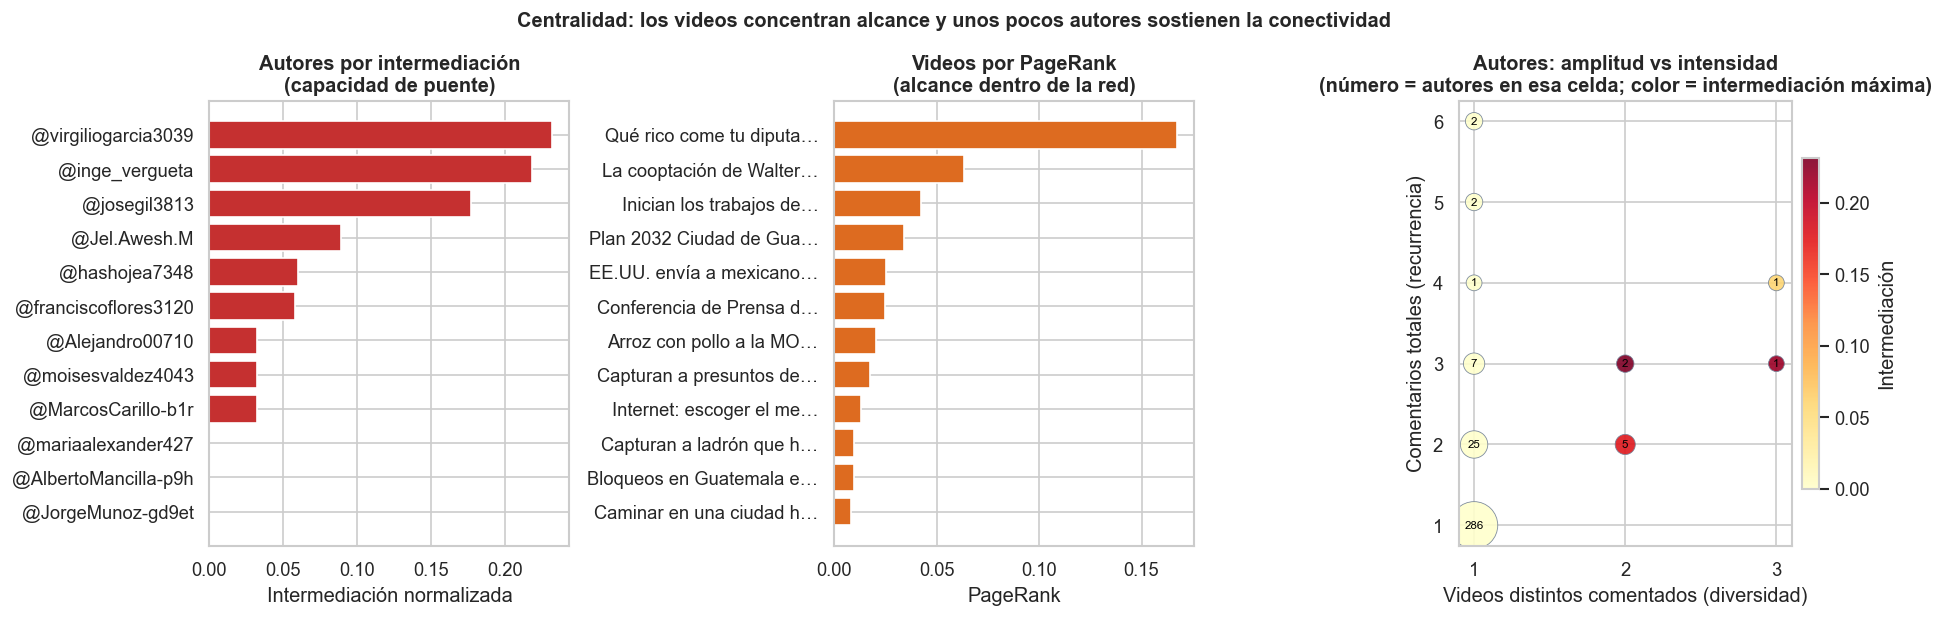

Figura 12 generada.


In [60]:
fig, ejes = plt.subplots(1, 3, figsize=(16, 5.2))

top_int = centralidad_autores.nlargest(12, "intermediacion").sort_values("intermediacion")
ejes[0].barh([acortar(e, 24) for e in top_int["etiqueta"]], top_int["intermediacion"], color=ROJO)
ejes[0].set(title="Autores por intermediación\n(capacidad de puente)", xlabel="Intermediación normalizada")

top_pr = centralidad_videos.nlargest(12, "pagerank").sort_values("pagerank")
ejes[1].barh([acortar(e, 24) for e in top_pr["etiqueta"]], top_pr["pagerank"], color=NARANJA)
ejes[1].set(title="Videos por PageRank\n(alcance dentro de la red)", xlabel="PageRank")

# Muchos autores comparten exactamente las mismas coordenadas: se agrupan y el tamaño indica cuántos.
celdas = centralidad_autores.groupby(["diversidad", "recurrencia"]).agg(
    autores=("node_id", "size"), intermediacion=("intermediacion", "max")).reset_index()
dispersion = ejes[2].scatter(celdas["diversidad"], celdas["recurrencia"],
                             s=45 + 45 * np.sqrt(celdas["autores"]),
                             c=celdas["intermediacion"], cmap="YlOrRd", vmin=0,
                             alpha=0.9, edgecolor=GRIS, lw=0.5)
for _, celda in celdas.iterrows():
    ejes[2].annotate(int(celda["autores"]), (celda["diversidad"], celda["recurrencia"]),
                     fontsize=7, ha="center", va="center", color="black")
ejes[2].set(title="Autores: amplitud vs intensidad\n(número = autores en esa celda; color = intermediación máxima)",
            xlabel="Videos distintos comentados (diversidad)", ylabel="Comentarios totales (recurrencia)",
            xticks=sorted(centralidad_autores["diversidad"].unique()))
fig.colorbar(dispersion, ax=ejes[2], label="Intermediación", fraction=0.046, pad=0.03)
fig.suptitle("Centralidad: los videos concentran alcance y unos pocos autores sostienen la conectividad",
             fontweight="bold")
fig.tight_layout()
guardar_figura("12_centralidad")
print("Figura 12 generada.")

## 9. Análisis de contenido y sentimiento

### 9.1 Herramienta, justificación y resultados globales

El modelo y su justificación se detallaron en la sección 2.8. Se recuerda lo esencial: se usa
`pysentimiento` (RoBERTuito), un transformer entrenado **en español** con texto de redes sociales,
aplicado sobre `texto_original` para conservar negación, puntuación y emojis.

In [61]:
print(f"Modelo utilizado: {MODELO_SENTIMIENTO}")

resumen_sentimiento = comentarios["sentimiento"].value_counts().reindex(["POS", "NEU", "NEG"]).fillna(0).astype(int)
tabla_sentimiento = pd.DataFrame({
    "etiqueta": ["Positivo", "Neutro", "Negativo"],
    "comentarios": resumen_sentimiento.values,
    "porcentaje": (100 * resumen_sentimiento.values / len(comentarios)).round(1),
})
tabla_sentimiento["confianza_media"] = [
    round(float(comentarios.loc[comentarios["sentimiento"] == e, "confianza_sentimiento"].mean()), 3)
    for e in ["POS", "NEU", "NEG"]]
guardar_tabla(tabla_sentimiento, "61_sentimiento_global")
registrar("tabla_sentimiento", tabla_sentimiento.to_dict("records"))
registrar("pct_negativo_global", float(tabla_sentimiento.loc[2, "porcentaje"]))
print(tabla_sentimiento.to_string(index=False))

ejemplos = pd.concat([
    comentarios.nlargest(3, "prob_pos")[["texto_original", "sentimiento", "confianza_sentimiento"]],
    comentarios.nlargest(3, "prob_neg")[["texto_original", "sentimiento", "confianza_sentimiento"]],
    comentarios.nlargest(3, "prob_neu")[["texto_original", "sentimiento", "confianza_sentimiento"]],
])
ejemplos["texto_original"] = ejemplos["texto_original"].map(lambda t: acortar(t, 95))
guardar_tabla(ejemplos, "62_ejemplos_sentimiento")
print()
print(ejemplos.to_string(index=False))

Modelo utilizado: pysentimiento / RoBERTuito (robertuito-sentiment-analysis, español)
etiqueta  comentarios  porcentaje  confianza_media
Positivo           78        19.2            0.813
  Neutro           79        19.5            0.625
Negativo          249        61.3            0.871

                                                                                 texto_original sentimiento  confianza_sentimiento
                               Es un proyecto extraordinario , vamos adelante mi guate hermosa!         POS               0.978018
Que bueno que Guatemala sea una cuidad bonita y ojalá todos los proyectos sean realidad. Se lo…         POS               0.976056
                          Gracias por este video, que importante conocer este tipo de espacios.         POS               0.974342
      Que indignante saber como se artan estos coches y finalmente el pueblo esta ciendo dañado         NEG               0.985907
Ni el mismo lo cree, estos son sinverguenzas y se pasa

### 9.2 Sentimiento por video, canal, tema y comunidad

Se aplica un **umbral mínimo de 10 comentarios** para comparar grupos: por debajo, la proporción de
negativos tiene un error estándar mayor a 15 puntos porcentuales y cualquier diferencia sería ruido.
Los grupos por debajo del umbral se reportan pero se marcan como no comparables.

In [62]:
UMBRAL = 10


def resumen_sentimiento_por(columna: str, etiqueta: str) -> pd.DataFrame:
    agregado = comentarios.groupby(columna).agg(
        comentarios=("comment_id", "size"),
        autores=("author_channel_id", "nunique"),
        sent_medio=("puntaje_sentimiento", "mean"),
        pct_neg=("sentimiento", lambda s: round(100 * (s == "NEG").mean(), 1)),
        pct_neu=("sentimiento", lambda s: round(100 * (s == "NEU").mean(), 1)),
        pct_pos=("sentimiento", lambda s: round(100 * (s == "POS").mean(), 1)),
        likes=("like_count", "sum"),
    ).reset_index()
    agregado["sent_medio"] = agregado["sent_medio"].round(3)
    agregado["comparable"] = agregado["comentarios"] >= UMBRAL
    agregado.insert(0, "dimension", etiqueta)
    return agregado.sort_values("comentarios", ascending=False)


sent_por_canal = resumen_sentimiento_por("channel_name", "Canal")
sent_por_comunidad = resumen_sentimiento_por("comunidad", "Comunidad")
sent_por_categoria = resumen_sentimiento_por("source_group", "Estrategia de muestreo")

sent_por_video = comentarios.merge(videos[["video_id", "title", "category"]], on="video_id", how="left")
sent_por_video = sent_por_video.groupby(["video_id", "title", "category"]).agg(
    comentarios=("comment_id", "size"),
    autores=("author_channel_id", "nunique"),
    sent_medio=("puntaje_sentimiento", "mean"),
    pct_neg=("sentimiento", lambda s: round(100 * (s == "NEG").mean(), 1)),
    pct_pos=("sentimiento", lambda s: round(100 * (s == "POS").mean(), 1)),
).reset_index()
sent_por_video["sent_medio"] = sent_por_video["sent_medio"].round(3)
sent_por_video["comparable"] = sent_por_video["comentarios"] >= UMBRAL
sent_por_video = sent_por_video.sort_values("sent_medio")

sent_por_tema = comentarios.merge(videos[["video_id", "category"]], on="video_id", how="left")
sent_por_tema = sent_por_tema.groupby("category").agg(
    comentarios=("comment_id", "size"),
    videos=("video_id", "nunique"),
    sent_medio=("puntaje_sentimiento", "mean"),
    pct_neg=("sentimiento", lambda s: round(100 * (s == "NEG").mean(), 1)),
).reset_index()
sent_por_tema["sent_medio"] = sent_por_tema["sent_medio"].round(3)
sent_por_tema["comparable"] = sent_por_tema["comentarios"] >= UMBRAL
sent_por_tema = sent_por_tema.sort_values("comentarios", ascending=False)

for frame, nombre in [(sent_por_video, "63_sentimiento_por_video"), (sent_por_canal, "64_sentimiento_por_canal"),
                      (sent_por_tema, "65_sentimiento_por_categoria"), (sent_por_comunidad, "66_sentimiento_por_comunidad"),
                      (sent_por_categoria, "67_sentimiento_por_estrategia")]:
    guardar_tabla(frame, nombre)

registrar("sent_por_canal", sent_por_canal.to_dict("records"))
registrar("sent_por_video", sent_por_video.to_dict("records"))
registrar("sent_por_tema", sent_por_tema.to_dict("records"))
registrar("sent_por_comunidad", sent_por_comunidad.head(8).to_dict("records"))
print(sent_por_canal[["channel_name", "comentarios", "autores", "sent_medio", "pct_neg", "pct_pos", "comparable"]]
      .to_string(index=False))
print()
print(sent_por_tema.to_string(index=False))

                         channel_name  comentarios  autores  sent_medio  pct_neg  pct_pos  comparable
                               Quorum          256      214      -0.502     69.9     14.1        True
Gobierno de la República de Guatemala           70       50      -0.221     50.0     24.3        True
           Municipalidad de Guatemala           25       25       0.609      8.0     80.0        True
                   Noticias Telemundo           25       18      -0.473     64.0      8.0        True
                                Noti7           14       13      -0.177     28.6     21.4        True
                   PrensaLibreOficial            7        7      -0.759     85.7      0.0       False
                       TN23 Guatemala            7        7      -0.622     85.7      0.0       False
        Noticiero Guatevisión 13 Hrs.            2        2      -0.519     50.0      0.0       False

             category  comentarios  videos  sent_medio  pct_neg  comparable
     

In [63]:
# Prueba de que las diferencias entre los grupos comparables no son casuales.
grupos_comparables = [g["puntaje_sentimiento"].values
                      for _, g in comentarios.groupby("channel_name") if len(g) >= UMBRAL]
h_stat, p_kruskal = stats.kruskal(*grupos_comparables) if len(grupos_comparables) > 1 else (np.nan, np.nan)
contingencia = pd.crosstab(comentarios["channel_name"], comentarios["sentimiento"])
contingencia = contingencia.loc[contingencia.sum(axis=1) >= UMBRAL]
chi2, p_chi2, gl, _ = stats.chi2_contingency(contingencia)

pruebas = pd.DataFrame([
    ["Kruskal–Wallis: puntaje de sentimiento entre canales comparables", round(float(h_stat), 3), round(float(p_kruskal), 6),
     f"{len(grupos_comparables)} canales con ≥{UMBRAL} comentarios"],
    ["Chi-cuadrado: etiqueta de sentimiento × canal", round(float(chi2), 3), round(float(p_chi2), 6),
     f"{gl} grados de libertad"],
], columns=["prueba", "estadístico", "p_valor", "detalle"])
guardar_tabla(pruebas, "68_pruebas_diferencias_sentimiento")
registrar("pruebas_sentimiento", pruebas.to_dict("records"))
pruebas

,prueba,estadístico,p_valor,detalle
0,Kruskal–Wallis: puntaje de sentimiento entre canales comparables,53.687,0.0,5 canales con ≥10 comentarios
1,Chi-cuadrado: etiqueta de sentimiento × canal,82.110,0.0,8 grados de libertad


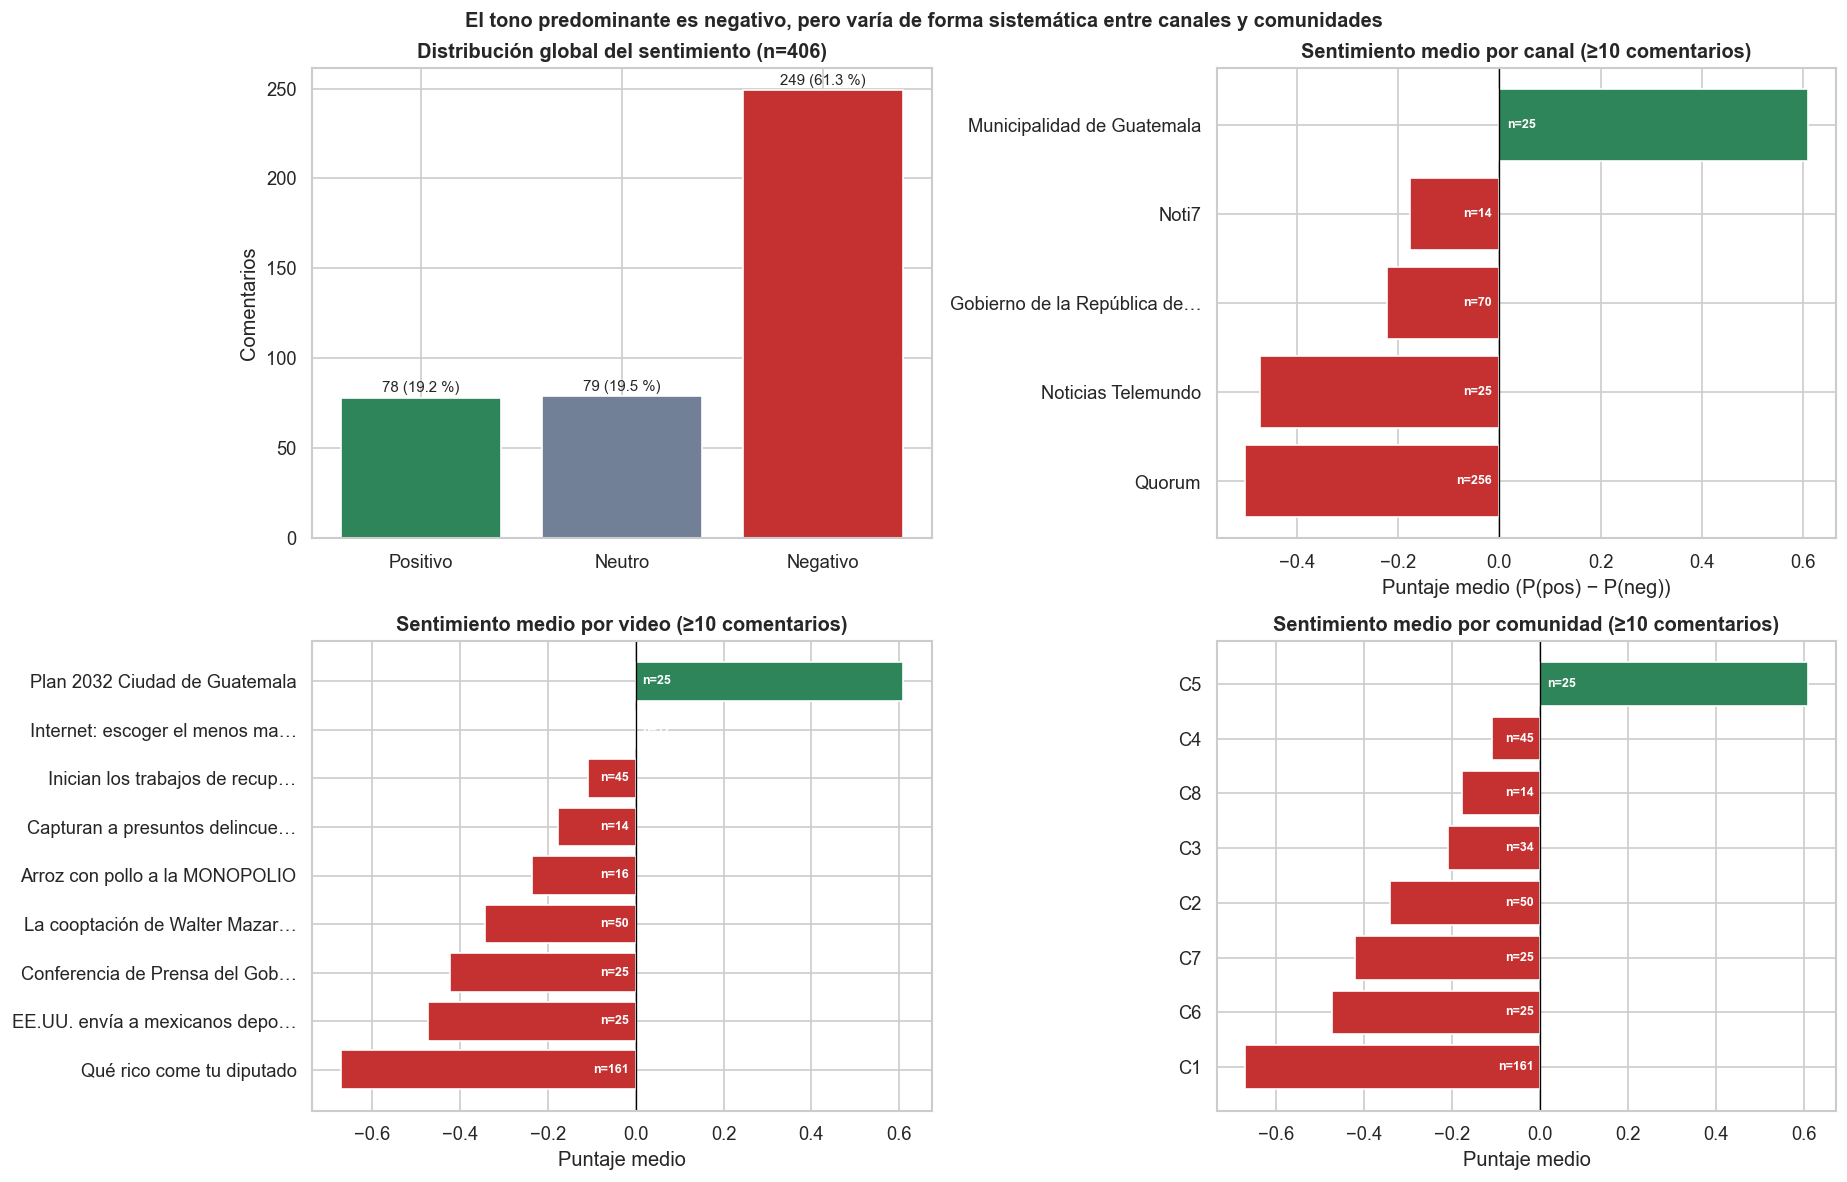

Figura 13 generada.


In [64]:
fig, ejes = plt.subplots(2, 2, figsize=(15.5, 10))

ejes[0, 0].bar(tabla_sentimiento["etiqueta"], tabla_sentimiento["comentarios"], color=[VERDE, GRIS, ROJO])
ejes[0, 0].set(title=f"Distribución global del sentimiento (n={len(comentarios)})", ylabel="Comentarios")
for x, (v, p) in enumerate(zip(tabla_sentimiento["comentarios"], tabla_sentimiento["porcentaje"])):
    ejes[0, 0].text(x, v + 3, f"{v} ({p} %)", ha="center", fontsize=9)

canales_cmp = sent_por_canal.query("comparable").sort_values("sent_medio")
colores = [ROJO if s < 0 else VERDE for s in canales_cmp["sent_medio"]]
ejes[0, 1].barh([acortar(c, 28) for c in canales_cmp["channel_name"]], canales_cmp["sent_medio"], color=colores)
ejes[0, 1].axvline(0, color="black", lw=0.8)
ejes[0, 1].set(title=f"Sentimiento medio por canal (≥{UMBRAL} comentarios)", xlabel="Puntaje medio (P(pos) − P(neg))")
def anotar_n(eje, valores, conteos):
    """Escribe el tamaño de muestra dentro de la barra, junto al cero, para no chocar con las etiquetas."""
    for y, (valor, n) in enumerate(zip(valores, conteos)):
        eje.text(-0.015 if valor < 0 else 0.015, y, f"n={n}", va="center",
                 ha="right" if valor < 0 else "left", fontsize=7.5, color="white", fontweight="bold")


anotar_n(ejes[0, 1], canales_cmp["sent_medio"], canales_cmp["comentarios"])

videos_cmp = sent_por_video.query("comparable")
ejes[1, 0].barh([acortar(t, 30) for t in videos_cmp["title"]], videos_cmp["sent_medio"],
                color=[ROJO if s < 0 else VERDE for s in videos_cmp["sent_medio"]])
ejes[1, 0].axvline(0, color="black", lw=0.8)
ejes[1, 0].set(title=f"Sentimiento medio por video (≥{UMBRAL} comentarios)", xlabel="Puntaje medio")
anotar_n(ejes[1, 0], videos_cmp["sent_medio"], videos_cmp["comentarios"])

com_cmp = sent_por_comunidad.query("comparable").sort_values("sent_medio")
ejes[1, 1].barh([f"C{int(c)}" for c in com_cmp["comunidad"]], com_cmp["sent_medio"],
                color=[ROJO if s < 0 else VERDE for s in com_cmp["sent_medio"]])
ejes[1, 1].axvline(0, color="black", lw=0.8)
ejes[1, 1].set(title=f"Sentimiento medio por comunidad (≥{UMBRAL} comentarios)", xlabel="Puntaje medio")
anotar_n(ejes[1, 1], com_cmp["sent_medio"], com_cmp["comentarios"])
fig.suptitle("El tono predominante es negativo, pero varía de forma sistemática entre canales y comunidades",
             fontweight="bold")
fig.tight_layout()
guardar_figura("13_sentimiento")
print("Figura 13 generada.")

## 10. Interpretación, limitaciones y conclusiones

### 10.2 Limitaciones (se declaran antes de interpretar)

In [65]:
limitaciones = pd.DataFrame([
    ["Cobertura de comentarios",
     f"Sólo {videos_con_comentarios} de {len(videos_raw)} videos ({round(100 * videos_con_comentarios / len(videos_raw), 1)} %) "
     f"tienen comentarios recolectados; {videos_sin_comentarios} tienen cero.",
     "Los 274 videos sin comentarios NO son videos sin participación: son videos sin datos. "
     "Todo resultado de red describe la subred observada, no YouTube Guatemala."],
    ["Selección por consultas",
     f"Los videos se encontraron con {videos_raw['source_query'].nunique()} consultas de búsqueda y tres estrategias "
     f"(topic, official_gov, channel); {int((videos_eda['source_group'] == 'official_gov').sum())} videos oficiales "
     "no aportaron ni un comentario.",
     "La muestra no es aleatoria ni representativa. Sobrerrepresenta noticias y política "
     f"({int(por_categoria.iloc[0]['videos'])} de {len(videos_raw)} videos) y excluye por diseño lo que no aparece en esas consultas."],
    ["Fechas relativas",
     "published_time y published_text son textos como «hace 2 días», dependientes del instante de recolección.",
     "No se puede construir una línea temporal fiable ni analizar la evolución de la conversación."],
    ["Conteos observados en el momento de recolección",
     f"view_count_text y view_count difieren en {disponibles - coinciden} de {disponibles} videos "
     f"(diferencia mediana de {dif_mediana} vistas): fueron capturados en instantes distintos.",
     "Las visualizaciones y los «me gusta» son fotografías, no valores definitivos; los rankings son aproximados."],
    ["Ausencia de relaciones explícitas entre autores",
     "reply_count indica cuántas respuestas recibió un comentario pero no quién las escribió; "
     "no se recolectaron los comentarios de respuesta.",
     "Es imposible construir una red de conversación. Toda relación autor–autor de este informe es "
     "CO-PARTICIPACIÓN derivada, nunca interacción observada."],
    ["Concentración en pocos videos",
     f"Un solo video reúne {int(video_top['comentarios_obs'])} de {len(comentarios)} comentarios "
     f"({round(100 * video_top['comentarios_obs'] / len(comentarios), 1)} %) y un solo canal el "
     f"{round(100 * canal_top['comentarios'] / len(comentarios), 1)} %.",
     "Los promedios globales están dominados por ese contenido. Cualquier afirmación sobre «los "
     "comentarios en general» es en realidad una afirmación sobre ese video."],
    ["Sólo comentarios principales",
     "El archivo contiene 406 comentarios de primer nivel; las respuestas anidadas no se recolectaron.",
     "Se subestima la actividad de quienes participan sobre todo respondiendo a otros."],
    ["Sentimiento automático",
     "El modelo alcanza en promedio ~0.80 de confianza, pero fue entrenado con tuits, no con "
     "comentarios de YouTube guatemaltecos, y no está calibrado para ironía ni modismos locales.",
     "Las etiquetas son una aproximación agregada útil, no un juicio fiable comentario a comentario."],
    ["Identidad de los autores",
     "author_channel_id identifica cuentas, no personas.",
     "Una persona con varias cuentas aparece como varios nodos, y una cuenta compartida como uno solo."],
], columns=["limitación", "evidencia_cuantitativa", "consecuencia_para_la_interpretación"])
guardar_tabla(limitaciones, "69_limitaciones")
registrar("limitaciones", limitaciones.to_dict("records"))
limitaciones

,limitación,evidencia_cuantitativa,consecuencia_para_la_interpretación
0,Cobertura de comentarios,Sólo 19 de 293 videos (6.5 %) tienen comentarios recolectados; 274 tienen cero.,Los 274 videos sin comentarios NO son videos sin participación: son videos sin datos. ...
1,Selección por consultas,"Los videos se encontraron con 21 consultas de búsqueda y tres estrategias (topic, offi...",La muestra no es aleatoria ni representativa. Sobrerrepresenta noticias y política (13...
2,Fechas relativas,"published_time y published_text son textos como «hace 2 días», dependientes del instan...",No se puede construir una línea temporal fiable ni analizar la evolución de la convers...
3,Conteos observados en el momento de recolección,view_count_text y view_count difieren en 53 de 280 videos (diferencia mediana de 4 vis...,"Las visualizaciones y los «me gusta» son fotografías, no valores definitivos; los rank..."
4,Ausencia de relaciones explícitas entre autores,reply_count indica cuántas respuestas recibió un comentario pero no quién las escribió...,Es imposible construir una red de conversación. Toda relación autor–autor de este info...
5,Concentración en pocos videos,Un solo video reúne 161 de 406 comentarios (39.7 %) y un solo canal el 63.1 %.,Los promedios globales están dominados por ese contenido. Cualquier afirmación sobre «...
6,Sólo comentarios principales,El archivo contiene 406 comentarios de primer nivel; las respuestas anidadas no se rec...,Se subestima la actividad de quienes participan sobre todo respondiendo a otros.
7,Sentimiento automático,"El modelo alcanza en promedio ~0.80 de confianza, pero fue entrenado con tuits, no con...","Las etiquetas son una aproximación agregada útil, no un juicio fiable comentario a com..."
8,Identidad de los autores,"author_channel_id identifica cuentas, no personas.","Una persona con varias cuentas aparece como varios nodos, y una cuenta compartida como..."


### 10.3 Descripción, asociación e inferencia

In [66]:
niveles = pd.DataFrame([
    ["DESCRIPCIÓN (válida)",
     f"En la muestra, {len(comentarios)} comentarios de {int(comentarios['author_channel_id'].nunique())} autores "
     f"se reparten en {videos_con_comentarios} videos; el {round(100 * (grados_autor == 1).mean(), 1)} % de los autores "
     "aparece en un solo video.",
     "Es un conteo directo sobre los datos entregados. No requiere supuestos."],
    ["ASOCIACIÓN (válida con reservas)",
     f"Entre los {len(sub)} videos con cobertura, visualizaciones y comentarios covarían (ρ = {rho_cob:.3f}); "
     f"los comentarios con más «me gusta» tienden a ser menos negativos (ρ = {rho_ls:.3f}).",
     "Son correlaciones sobre muestras pequeñas y seleccionadas. No implican causalidad: "
     "no puede afirmarse que más vistas *causen* más comentarios."],
    ["INFERENCIA (NO válida aquí)",
     "«Los guatemaltecos son negativos en YouTube» o «este canal genera más rechazo que los demás».",
     "La muestra no es probabilística, cubre el 6.5 % de los videos y está dominada por un canal. "
     "No permite generalizar a la población de usuarios ni a YouTube Guatemala."],
], columns=["nivel", "ejemplo_extraído_de_este_análisis", "por_qué"])
guardar_tabla(niveles, "70_descripcion_asociacion_inferencia")
registrar("niveles", niveles.to_dict("records"))
niveles

,nivel,ejemplo_extraído_de_este_análisis,por_qué
0,DESCRIPCIÓN (válida),"En la muestra, 406 comentarios de 332 autores se reparten en 19 videos; el 97.3 % de l...",Es un conteo directo sobre los datos entregados. No requiere supuestos.
1,ASOCIACIÓN (válida con reservas),"Entre los 19 videos con cobertura, visualizaciones y comentarios covarían (ρ = 0.811);...",Son correlaciones sobre muestras pequeñas y seleccionadas. No implican causalidad: no ...
2,INFERENCIA (NO válida aquí),«Los guatemaltecos son negativos en YouTube» o «este canal genera más rechazo que los ...,"La muestra no es probabilística, cubre el 6.5 % de los videos y está dominada por un c..."


### 10.1 y 10.4 Hallazgos integrados

In [67]:
hallazgos = pd.DataFrame([
    ["Estructura", "La red es una constelación de estrellas, no una conversación",
     f"{G_obs.number_of_nodes()} nodos y {G_obs.number_of_edges()} aristas; grado medio de los autores "
     f"{grados_autor.mean():.2f} frente a {grados_video.mean():.1f} de los videos; "
     f"{round(100 * (grados_autor == 1).mean(), 1)} % de los autores tiene grado 1.",
     "La participación se organiza alrededor del contenido, no de vínculos entre personas: "
     "casi todos comentan una vez, en un único video, y no vuelven."],
    ["Fragmentación", "Un núcleo grande y nueve islas",
     f"{len(componentes_obs)} componentes; la mayor reúne {len(componentes_obs[0])} nodos "
     f"({round(100 * len(componentes_obs[0]) / G_obs.number_of_nodes(), 1)} %); diámetro 12.",
     "El núcleo se sostiene por muy pocos autores; las islas son videos cuya audiencia no coincide "
     "con ninguna otra dentro de la muestra."],
    ["Puentes", "Siete personas sostienen la conectividad",
     f"{len(puentes)} autores son puntos de articulación de {len(por_autor)} ({round(100 * len(puentes) / len(por_autor), 1)} %); "
     f"el de mayor intermediación alcanza {puentes['intermediacion'].max():.3f}.",
     "Eliminar a esos siete autores fragmenta la componente principal. Son estructuralmente "
     "críticos, aunque sólo aportan entre 2 y 4 comentarios cada uno."],
    ["Comunidades", "Las comunidades son videos, no grupos sociales",
     f"{len(comunidades)} comunidades con modularidad {mod_pesada:.3f}; "
     f"{int((perfil_comunidades['videos'] == 1).sum())} de ellas contienen un solo video.",
     "La modularidad alta no revela tribus de usuarios: refleja que cada video captura una audiencia "
     "propia que no se solapa con las demás."],
    ["Concentración", "Un video y un canal dominan la muestra",
     f"El video líder reúne {round(100 * video_top['comentarios_obs'] / len(comentarios), 1)} % de los comentarios y "
     f"el canal líder {round(100 * canal_top['comentarios'] / len(comentarios), 1)} %; Gini de comentarios por video "
     f"{gini(por_video['comentarios_obs'].values):.3f}.",
     "La participación observada es extremadamente desigual; los promedios globales describen "
     "sobre todo a ese contenido."],
    ["Popularidad ≠ participación", "Ser visto y ser comentado no es lo mismo",
     f"«{acortar(str(ranking.iloc[0]['title']), 40)}» ocupa el puesto {int(ranking.iloc[0]['rank_comentarios'])} en comentarios "
     f"y el {int(ranking.iloc[0]['rank_vistas'])} en vistas; el video más visto (304 089 vistas) genera "
     f"{ranking.query('rank_vistas == 1')['comentarios_por_10k_vistas'].iloc[0]:.2f} comentarios por cada 10 000 vistas, "
     f"frente a {ranking['comentarios_por_10k_vistas'].max():.0f} del más participativo.",
     "La visibilidad no predice la participación: los videos que activan a la audiencia son los que "
     "tocan un nervio, no los más vistos."],
    ["Contenido y tono", "Participar es sobre todo criticar",
     f"{int(tabla_sentimiento.loc[2, 'comentarios'])} de {len(comentarios)} comentarios son negativos "
     f"({tabla_sentimiento.loc[2, 'porcentaje']} %); el vocabulario dominante es «pueblo», «diputado», «pagar», «dinero».",
     "El tono negativo no es uniforme: varía de forma significativa entre canales "
     f"(Kruskal–Wallis, {'p < 0.001' if p_kruskal < 0.001 else f'p = {p_kruskal:.3f}'}), "
     "del −0.50 de Quorum al +0.61 de la Municipalidad."],
    ["Cobertura", "El hallazgo metodológico principal",
     f"{videos_sin_comentarios} de {len(videos_raw)} videos sin comentarios; "
     f"0 de {int((videos_eda['source_group'] == 'official_gov').sum())} videos de la estrategia official_gov aportó datos.",
     "La forma de la red está determinada tanto por el comportamiento de los usuarios como por el "
     "procedimiento de recolección. Ignorarlo llevaría a confundir ausencia de datos con silencio social."],
], columns=["eje", "hallazgo", "evidencia", "interpretación"])
guardar_tabla(hallazgos, "71_hallazgos_integrados")
registrar("hallazgos", hallazgos.to_dict("records"))
hallazgos

,eje,hallazgo,evidencia,interpretación
0,Estructura,"La red es una constelación de estrellas, no una conversación",351 nodos y 343 aristas; grado medio de los autores 1.03 frente a 18.1 de los videos; ...,"La participación se organiza alrededor del contenido, no de vínculos entre personas: c..."
1,Fragmentación,Un núcleo grande y nueve islas,10 componentes; la mayor reúne 286 nodos (81.5 %); diámetro 12.,El núcleo se sostiene por muy pocos autores; las islas son videos cuya audiencia no co...
2,Puentes,Siete personas sostienen la conectividad,7 autores son puntos de articulación de 332 (2.1 %); el de mayor intermediación alcanz...,Eliminar a esos siete autores fragmenta la componente principal. Son estructuralmente ...
3,Comunidades,"Las comunidades son videos, no grupos sociales",17 comunidades con modularidad 0.777; 16 de ellas contienen un solo video.,La modularidad alta no revela tribus de usuarios: refleja que cada video captura una a...
4,Concentración,Un video y un canal dominan la muestra,El video líder reúne 39.7 % de los comentarios y el canal líder 63.1 %; Gini de coment...,La participación observada es extremadamente desigual; los promedios globales describe...
5,Popularidad ≠ participación,Ser visto y ser comentado no es lo mismo,«Qué rico come tu diputado» ocupa el puesto 1 en comentarios y el 3 en vistas; el vide...,La visibilidad no predice la participación: los videos que activan a la audiencia son ...
6,Contenido y tono,Participar es sobre todo criticar,"249 de 406 comentarios son negativos (61.3 %); el vocabulario dominante es «pueblo», «...",El tono negativo no es uniforme: varía de forma significativa entre canales (Kruskal–W...
7,Cobertura,El hallazgo metodológico principal,274 de 293 videos sin comentarios; 0 de 105 videos de la estrategia official_gov aport...,La forma de la red está determinada tanto por el comportamiento de los usuarios como p...


## 11. Exportación de datos procesados y de las métricas del informe

In [68]:
comentarios_export = comentarios.drop(columns=["urls_lista", "hashtags_lista", "menciones_lista",
                                               "emojis_lista", "texto_prelimpio"], errors="ignore")
videos_export = videos.copy()
for columna in ["keywords_lista", "query_hits_lista", "hashtags_lista"]:
    videos_export[columna] = videos_export[columna].map(lambda v: json.dumps(list(v), ensure_ascii=False))

comentarios_export.to_csv(PROCESADOS / "youtube_comments_clean.csv", index=False, encoding="utf-8-sig")
videos_export.to_csv(PROCESADOS / "youtube_videos_clean.csv", index=False, encoding="utf-8-sig")
videos_eda.drop(columns=["keywords_lista", "query_hits_lista", "hashtags_lista"], errors="ignore").to_csv(
    PROCESADOS / "videos_con_metricas.csv", index=False, encoding="utf-8-sig")

registrar("figuras", sorted(p.name for p in FIGURAS.glob("*.png")))
registrar("tablas", sorted(p.name for p in TABLAS.glob("*.csv")))
registrar("grafos", sorted(p.name for p in GRAFOS.glob("*.graphml")))

with open(ROOT / "outputs" / "resultados.json", "w", encoding="utf-8") as archivo:
    json.dump(RESULTADOS, archivo, ensure_ascii=False, indent=2, default=str)

print(f"Tablas exportadas   : {len(RESULTADOS['tablas'])}")
print(f"Figuras exportadas  : {len(RESULTADOS['figuras'])}")
print(f"Grafos exportados   : {len(RESULTADOS['grafos'])}")
print(f"Métricas registradas: {len(RESULTADOS)} claves en outputs/resultados.json")
print("\nAnálisis completo.")

Tablas exportadas   : 71
Figuras exportadas  : 13
Grafos exportados   : 4
Métricas registradas: 122 claves en outputs/resultados.json

Análisis completo.
